Created on 06/07/26, from "stoch_plan_typdays_gridimport"

This file was created only to test a particular approach for solving the stochastic problem to completion.\
The idea is to solve the problem until the point where the gap tends to stagnate (around 0.5-2%), and somehow get an estimate of the range within which the devices size is ensured to be optimal. Unfortunately, no Gurobi built-in feature allows to do this. Instead, I tried evaluating lower and upper boundaries for the sizes by using the objective function calculated on the full problem as a LB (let's call the constraint Obj_lb) for the objective function of a new relaxed problem. The relaxed problem is obtained using Gurobi's built-in features, and it tries to first minimize and then maximize the size of the devices while respecting the boundary Obj_lb. The optimal values of the sizes from the two problems would then be lower and upper boundaries for the sizes of the devices.

Unfortunately, it seems that the procedure, while working theorically as intended, does not provide practical benefits, as it returns LBs and UBs that are too wide apart.

## Multi-energy system deterministic scheduling

### Simple formulation: ideal grid

In [42]:
# pip install --upgrade nbstripout
# pip install pyomo gurobipy

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import gurobipy as gp
import os
from pyomo.environ import *
from pyomo.opt import SolverFactory
from pyomo.core import Var
import copy

from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

# os.environ["GRB_LICENSE_FILE"] = os.environ["HOME"] + "/gurobi/gurobi.lic"

#### Preliminary data gathering
Most of the data is actually defined later, within the definition of the problem itself

In [44]:
#------------------------------------------------------------------------------------------------
# PARAMETERS
# (later they will be redefined to accomodate the typical Pyomo problem formulation)
#------------------------------------------------------------------------------------------------

# GENERAL ---------------------------------------------------------------------------------------
# FCR service
DT_FCR_ramp = 30 / 3600     # time allotted to reach allocated power in FCR service
# Si potrebbe aggiungere un termine (e quindi un vincolo) simile per il tempo di reazione (tempo per raggiungere il 10% del valore di potenza attiva; 
# quello sopra, i 30 s, sono il tempo di risposta). Immagino però che, supponendo le operazioni di ramp-up e ramp-down di natura lineare, il vincolo sul tempo di
# risposta sia sempre il più stringente. La logica è che le norme dovrebbero supporre che i dispositivi sono in grado di variare la propria potenza più lentamente
# nei primi momenti dall'istante in cui ricevono il segnale di comando.
# C_FCR_capup = 20            # remuneration rate for upward FCR capacity bid [€/MW] ### NO REFERENCE ### (Mokhtar will provide this)
# C_FCR_capdown = 20          # remuneration rate for downward FCR capacity bid [€/MW] ### NO REFERENCE ### (Mokhtar will provide this)

# # H2 demand
# C_h2 = 7      # H2 selling price [€/kg]
# Hsup_min_day = 25          # minimum daily hydrogen supply [kg] ### TO DECIDE ###
# Hsup_max_day = 50          # maximum daily hydrogen supply [kg] ### TO DECIDE ###
# Hsup_tgt_week = (Hsup_max_day + Hsup_min_day) / 2 * 7      # target weekly H2 supply (evaluated as daily mean times 7 days) ### TO DECIDE ###
# Hsup_tgt_month = (Hsup_max_day + Hsup_min_day) / 2 * 30    # target monthy H2 supply (evaluated as daily mean times 30 days) ### TO DECIDE ###

# LOADS -----------------------------------------------------------------------------------------
Pl_comm_rtd = 1     # rated commertial load power [MW]
Pl_ind_rtd = 1      # rated industrial load power [MW]
Pl_resid_rtd = 1    # rated residential load power [MW]

# PV --------------------------------------------------------------------------------------------
Ppv_rtd = 3    # PV rated power [MW]

# # BESS ------------------------------------------------------------------------------------------
# Pb_rtd = 1              # BESS rated power [MW]
# Pb_ch_max = Pb_rtd      # BESS maximum charging power [MW]
# Pb_dch_max = Pb_rtd     # BESS maximum discharging power [MW]
# C_rate = 0.5            # BESS C-rate [1/h]
# Eb_rtd = Pb_rtd / C_rate    # BESS rated capacity [MWh]
# DoD = 0.9               # BESS depth of discharge
# SoC_max = 1             # maximum SoC level
# SoC_min = 1 - DoD       # minimum SoC level
# SoC_0 = 0.5 * SoC_max   # SoC value at t=0
# eta_b_rt = 0.931        # battery round-trip efficiency
# eta_b_inv_rt = 0.98     # inverter round-trip efficiency
# eta_bch = np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)       # BESS charging efficiency
# eta_bdch = np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)      # BESS discharging efficiency
# sig_b_sd = 0.001/24          # BESS hourly self-discharge coefficient [-] (CIGRE) (previously 0.01 for tests)

# # HSS -------------------------------------------------------------------------------------------
# H_hss_max = 1e3                 # hydrogen tank capacity [kg]
# H_hss_min = 0.1 * H_hss_max     # minimum hydrogen tank level [kg]
# H_hss_0 = 0.5 * H_hss_max       # H2 level at t=0
# FR_hc_el2hss = 25               # H2 maximum flow rate for the compressor from EL to HSS ### NO REFERENCE ###
# FR_hc_hss2dem = 25              # H2 maximum flow rate for the compressor from EL to HRS (H2 demand) ### NO REFERENCE ###

# sig_hss_sd = 0              # HSS hourly H2 self-discharge coefficient [-] (previously 0.0002 as test)
# sig_hss_ch = 0              # HSS hourly H2 charging losses coefficient [-]
# sig_hss_dch = 0             # HSS hourly H2 discharging losses coefficient [-]
# sig_hc_el2hss = 0           # coefficient of H2 losses for EL to HSS compression stage [-]
# sig_hc_hss2dem = 0          # coefficient of H2 losses for HSS to HRS compression stage [-]

# FC --------------------------------------------------------------------------------------------
# lhv = 33.3e-3       # lower heating value of H2 [MWh/kg]
# eta_fc = 0.5        # FC efficiency

Pfc_rtd = 0.5          # FC rated power [MW]
Pfc_min_ratio = 0.4    # FC minimum power ratio [-] (previously 0.1 for tests) (the sources from which I derived the value 0.4 are not very good)
Pfc_min = Pfc_min_ratio * Pfc_rtd       # FC minimum turndown level [MW] (also minimum power level)
rho_fcpos = 0.07 * Pfc_rtd * 3600    # FC positive ramp rate [MW/h]  (original data 7 kW/s for a 100 kW FC --> 0.07 pu/s) (previously 20*Pfc_rtd for tests)
rho_fcneg = -0.046 * Pfc_rtd * 3600   # FC negative ramp rate [MW/h]  (original data -4.6 kW/s for a 100 kW FC --> -0.046 pu/s) (previously -20*Pfc_rtd for tests)


# COMPRESSORS -----------------------------------------------------------------------------------
# Evaluation of the power requirement for hydrogen compression from EL to HSS, in MW per hour per kg of compressed gas
R = 8.3145          # universal gas constant [J/(mol*K)]
Mm = 2.01568e-3     # molar mass of hydrogen [kg/mol]

T = 70 + 273.15     # EL operating/outlet temperature [K]
T_hss = 70 + 273.15     # HSS hydrogen outlet temperature [K]
p = 30e5            # EL operating/outlet pressure [Pa]
p_hss = 150e5       # pressure in the HSS [Pa]
p_dem = 300e5       # hydrogen delivery pressure [Pa]
eta_cis = 0.75      # isoentropic compressor efficiency (valore indicativo, realistico)

# To clarify the following lines, Zs is evaluated from tables in a reference paper. Assuming compression is performed from 30 bar to 150 bar, I calculated the
# value of Zs by linear interpolation between two known values, 1.02701 (50 bar, 350 K = 76.85 C) and 1.05369 (100 bar, 350 K = 76.85 C). The result is finally
# rounded upward to 1.05.
slope_lin_Zs = (1.05369 - 1.02701) / 50
intercept_lin_Zs = 1.02701 - slope_lin_Zs * 50
Zs = slope_lin_Zs * 90 + intercept_lin_Zs         # compressibility factor of hydrogen at 76.85 C (350 K) [-] (1.048354 ~ 1.05)

ks = 14.427 / 10.302          # average ratio of specific heats (Cp/Cv) for a hydrogen at around 76.85 C (350 K) [-] (The values of Cp and Cv are taken from a reference)

# Notes to interpret the following formula:
# - P_hc will multiply the mass flow of hydrogen produced by the EL
# - Without 3600 and 1e6, the formula evaluates the power consumption for the compression of a kg/s of H2 in J/kg
# - Since we will multiply P_hc by an hydrogen mass flow in kg/h, the division by 3600 is needed
# - The result of the multiplication would then be in J/s = W
# - Finally, the division by 1e6 brings the result to the MW scale
P_hc = (1 / (3600 * Mm * eta_cis)) * Zs * R * T * (ks / (ks - 1)) * ((p_hss / p) ** ((ks - 1) / ks) - 1) / 1e6    # power requirement for the compression of a hydrogen mass unit [MW/kg]


# Evaluation of the power requirement for hydrogen compression from HSS to HRS, in MW per hour per kg of compressed gas
#TODO: Adattare quanto scritto sotto in base ai livelli di pressione di HSS e HRS

# To clarify the following lines, Zs is evaluated from tables in a reference paper. Assuming compression is performed from 30 bar to 150 bar, I calculated the
# value of Zs by linear interpolation between two known values, 1.02701 (50 bar, 350 K = 76.85 C) and 1.05369 (100 bar, 350 K = 76.85 C). The result is finally
# rounded upward to 1.05.
slope_lin_Zs = (1.05369 - 1.02701) / 50
intercept_lin_Zs = 1.02701 - slope_lin_Zs * 50
Zs = slope_lin_Zs * 90 + intercept_lin_Zs         # compressibility factor of hydrogen at 76.85 C (350 K) [-] (1.048354 ~ 1.05)

ks = 14.427 / 10.302          # average ratio of specific heats (Cp/Cv) for a hydrogen at around 76.85 C (350 K) [-] (The values of Cp and Cv are taken from a reference)


# Notes to interpret the following formula:
# - P_hc will multiply the mass flow of hydrogen produced by the EL
# - Without 3600 and 1e6, the formula evaluates the power consumption for the compression of a kg/s of H2 in J/kg
# - Since we will multiply P_hc by an hydrogen mass flow in kg/h, the division by 3600 is needed
# - The result of the multiplication would then be in J/s = W
# - Finally, the division by 1e6 brings the result to the MW scale
P_hc = (1 / (3600 * Mm * eta_cis)) * Zs * R * T * (ks / (ks - 1)) * ((p_hss / p) ** ((ks - 1) / ks) - 1) / 1e6    # power requirement for the compression of a hydrogen mass unit [MW/kg] (previously 0.001 for tests) ### NO REFERENCE ###

The following section is useful to the optimization strategy only in order to find the parameters for the piecewise linear model of the EL hydrogen-power characteristic.

In [45]:
#------------------------------------------------------------------------------------------------
# EL MODEL AND LINEAR APPROXIMATION
#------------------------------------------------------------------------------------------------

# The parameters A and B of the linear EL model, meaning the slope and the intercept of the 
# hydrogen-power characteristic, will be supposed independant of the size of the EL. I'm not sure 
# this is a correct assumption, as the original model is an empirical model with some parameters
# fitted for a specific size (1 MW).
# An alternative to this approach could be to evaluate A and B for different sizes of the EL and
# then deriving the linear relationship between each of them and the size of the EL. Then, the 
# formulation of the problem could probably be modified to account for this. Still, this approach
# may be wrong, lead to unnecessarily complex problem formulation, or both.

# ORIGINAL MODEL --------------------------------------------------------------------------------
# General constants and parameters
T0 = 20 + 273.15    # standard temperature [K]
p0 = 1.01325e5      # standard pressure [Pa]
R = 8.3145          # universal gas constant [J/(mol*K)]
F = 96485           # Faraday constant [C/mol]
z = 2               # number of electrons transferred in electrolysis reaction
Mm = 2.01568e-3     # molar mass of hydrogen [kg/mol]

# Electrolyzer parameters
p = 30e5            # operating pressure [Pa]
T = 70 + 273.15     # operating temperature [K]
R_io = 0.326        # internal stack resistance at standard conditions [Ohm]
k = 0.0395          # fitting parameter
dR_t = -3.812e-3    # temperature coefficient of resistance [Ohm/K]
e_rev0 = 1.476      # reversible voltage at standard conditions [V]
eta_F = 1           # Faraday efficiency

Pel_rtd_W = 1e6         # EL rated power [W]
Pel_min_ratio = 0.1     # EL minimum power ratio [-]
Pel_min_W = Pel_min_ratio * Pel_rtd_W     # EL minimum power [W]
n_s = 275           # number of cells in series
n_p = 3700          # number of cells in parallel
n_tot = n_s * n_p   # total number of cells

# (Empirical) Electrical model
V_rev = e_rev0 + (R*T)/(2*F) * np.log(p/p0)         # reversible voltage [V]
Ri = R_io + k * np.log(p/p0) + dR_t * (T - T0)      

Pel_fit = np.linspace(Pel_min_W, Pel_rtd_W, 901)  # power array for fitting [W]
Pel_fit_cell = Pel_fit / n_tot           # cell power array for fitting [W]

i_fit = (-V_rev + np.sqrt(V_rev**2 + 4*Ri*Pel_fit_cell)) / (2*Ri)      # current array [A]
H2_prod_fit = eta_F * Mm * 3600 * (n_tot * i_fit) / (z * F)            # H2 production rate array for fitting [kg/h]

Pel_rtd = Pel_rtd_W / 1e6                  # EL rated power [MW] (also maximum power)
Pel_min = Pel_min_ratio * Pel_rtd     # EL minimum turndown level [MW] (also minimum power level)

# LINEAR MODEL ----------------------------------------------------------------------------------
lin_param = np.polyfit(Pel_fit, H2_prod_fit, 1)      # fitting parameters of linear model
H2_prod_lin = lin_param[0] * Pel_fit + lin_param[1]  # H2 production rate linear model [kg/h]

# Print results
print(f"Slope: {lin_param[0]}, Intercept: {lin_param[1]}")

# Adjust parameters to express EL power in MW
a_lin = lin_param[0] * 1e6
b_lin = lin_param[1]


# ADDITIONAL PARAMETERS ----------------------------------------------------------------------------------------
Pel_sb = 0.02 * Pel_rtd    # EL stand-by power consumption [MW]
rho_elpos = 0.4 * Pel_rtd * 3600    # EL positive ramp rate [MW/h] (original data 0.4 pu/s) (previously 20*Pel_rtd for tests)
rho_elneg = -0.5 * Pel_rtd * 3600   # EL negative ramp rate [MW/h] (original data 0.5 pu/s) (previously 20*Pel_rtd for tests)

# # Evaluation of the ability of the EL to participate to FCR based on its ramp-rate characteristics
# time_maxDPpos = Pel_rtd / rho_elpos   # time needed to ramp up the EL power by a quantity equal to its rated power [h] 
# possible_DP_ratiopos = DT_FCR_ramp / time_maxDPpos   # amount of positive power variation that the EL can achieve in 30 s [p.u. of nominal power]
# time_maxDPneg = Pel_rtd / rho_elneg   # time needed to ramp down the EL power by a quantity equal to its rated power [h] 
# possible_DP_rationeg = DT_FCR_ramp / time_maxDPneg   # amount of negative power variation that the EL can achieve in 30 s [p.u. of nominal power]
# print(f"Time needed for 1 p.u. EL power ramp up: {time_maxDPpos * 3600:.2f} s")
# print(f"Time needed for 1 p.u. EL power ramp down: {time_maxDPneg * 3600:.2f} s")
# print(possible_DP_ratiopos)
# print(possible_DP_rationeg)
# # # The amount of positive (negative) power variation that is possible in the allotted time (30 s) is proportional to the amount of frequency variation we can 
# # # accept while continuing to have the EL participate to the FCR (here called "max_Df_pos(neg)") (through the droop constant -(0.2 Hz / 50 Hz) / (1 pu / 1 pu) = -0.004).
# # band = 0.2    # "regular" band for FCR participation [Hz]
# # max_Df_pos = band * possible_DP_ratiopos
# # max_Df_neg = band * possible_DP_rationeg
# # print(f"Maximum acceptable positive frequency deviation for EL participation to the FCR service: {max_Df_pos:.2f} Hz")
# # print(f"Maximum acceptable negative frequency deviation for EL participation to the FCR service: {max_Df_neg:.2f} Hz")

# # Evaluation of the ability of the FC to participate to FCR based on its ramp-rate characteristics
# time_maxDPpos_fc = Pfc_rtd / rho_fcpos   # time needed to ramp up the EL power by a quantity equal to its rated power [h] 
# possible_DP_ratiopos_fc = DT_FCR_ramp / time_maxDPpos_fc   # amount of positive power variation that the EL can achieve in 30 s [p.u. of nominal power]
# time_maxDPneg_fc = Pfc_rtd / rho_fcneg   # time needed to ramp down the EL power by a quantity equal to its rated power [h] 
# possible_DP_rationeg_fc = DT_FCR_ramp / time_maxDPneg_fc   # amount of negative power variation that the EL can achieve in 30 s [p.u. of nominal power]
# print(f"Time needed for 1 p.u. FC power ramp up: {time_maxDPpos_fc * 3600:.2f} s")
# print(f"Time needed for 1 p.u. FC power ramp down: {time_maxDPneg_fc * 3600:.2f} s")
# print(possible_DP_ratiopos_fc)
# print(possible_DP_rationeg_fc)

Slope: 2.2084524028207953e-05, Intercept: 0.5145918996345079


In [46]:
#------------------------------------------------------------------------------------------------
# PROFILES
#------------------------------------------------------------------------------------------------

# Reading the Excel files
C_ele_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\GME_20240101_20241231_MGP_PrezziZonali_CSUD.xlsx", decimal=',')
# print(C_ele_original)
Pl_Ppv_Pwt_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\Dati ENEA.xlsx")
# print(Pl_Ppv_Pwt_original)


# Extraction of useful profiles
C_ele_full = C_ele_original['€/MWh'].tolist()               # zonal price (CSUD 2024) [€/MWh], from 01/01/24 to 31/12/24 (leap year, 366 days)
C_ele = np.array(C_ele_full[:1416] + C_ele_full[1440:])     # removing 29th Feb data to have 365 days (8760 hours) and turning into ndarray
# C_ele = np.append(C_ele, C_ele[0])                        # make the array go from 0 to 8760 (8761 values)

C_ele_sell = C_ele / 2

Pl_comm_to_arrange = Pl_Ppv_Pwt_original['Commerciale'].tolist()            # commercial load profile [p.u.], from 16/10/20 to 15/10/21
Pl_comm = np.array(Pl_comm_to_arrange[1848:] + Pl_comm_to_arrange[:1848])   # rearranged data from 01/01/21 to 15/10/21 and then from 16/10/20 to 31/12/20

Pl_ind_to_arrange = Pl_Ppv_Pwt_original['Industriale'].tolist()             # industrial load profile [p.u.], from 16/10/20 to 15/10/21
Pl_ind = np.array(Pl_ind_to_arrange[1848:] + Pl_ind_to_arrange[:1848])

Pl_resid_to_arrange = Pl_Ppv_Pwt_original['Residenziale'].tolist()          # residential load profile [p.u.], from 16/10/20 to 15/10/21
Pl_resid = np.array(Pl_resid_to_arrange[1848:] + Pl_resid_to_arrange[:1848])

Ppv_to_arrange = Pl_Ppv_Pwt_original['PV'].tolist()         # PV generation profile [??], from 16/10/20 to 15/10/21
P_pv = np.array(Ppv_to_arrange[1848:] + Ppv_to_arrange[:1848])

Pwt_to_arrange = Pl_Ppv_Pwt_original['Wind'].tolist()       # WT generation profile [??], from 16/10/20 to 15/10/21
P_wt = np.array(Pwt_to_arrange[1848:] + Pwt_to_arrange[:1848])


# Checking the data
time = np.arange(0, 8760)

# Plot settings
plt.rc('figure', figsize=(20, 20))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2

"""
# Plots
fig, axs = plt.subplots(6, 1, layout='constrained')
axs[0].plot(time, C_ele, color='blue')
axs[0].set_xlabel('x label')
axs[0].set_ylabel('y label')
axs[0].set_title("Electricity Price [€/MWh]")
axs[0].legend()

axs[1].plot(time, Pl_comm)
axs[1].set_title("Commercial load [p.u.]")
axs[2].plot(time, Pl_ind)
axs[2].set_title("Industrial load [p.u.]")
axs[3].plot(time, Pl_resid)
axs[3].set_title("Residential load [p.u.]")
axs[4].plot(time, P_pv)
axs[4].set_title("PV generation [??]")
axs[5].plot(time, P_wt)
axs[5].set_title("WT generation [??]")
"""


# Profiles adjustments based on rated powers
Pl_comm = Pl_comm * Pl_comm_rtd         # Commercial load profile [MW]
Pl_ind = Pl_ind * Pl_ind_rtd            # Industrial load profile [MW]
Pl_resid = Pl_resid * Pl_resid_rtd      # Residential load profile [MW]
P_load = Pl_ind + Pl_comm              # load profile used in the optimization problem [MW]
P_pv = (P_pv / 2) * Ppv_rtd             # PV generation profile [MW]
# Pwt = Pwt * Pwt_rtd                   # WT generation profile [MW]

"""
# Checking the data after adjustments
fig, axs = plt.subplots(6, 1, layout='constrained')
axs[0].plot(time, C_ele, color='blue')
axs[0].set_xlabel('x label')
axs[0].set_ylabel('y label')
axs[0].set_title("Electricity Price [€/MWh]")
axs[0].legend()

axs[1].plot(time, Pl_comm)
axs[1].set_title("Commercial load [MW]")
axs[2].plot(time, Pl_ind)
axs[2].set_title("Industrial load [MW]")
axs[3].plot(time, Pl_resid)
axs[3].set_title("Residential load [MW]")
axs[4].plot(time, P_pv)
axs[4].set_title("PV generation [MW]")
# axs[5].plot(time, P_wt)
# axs[5].set_title("WT generation")
"""

'\n# Checking the data after adjustments\nfig, axs = plt.subplots(6, 1, layout=\'constrained\')\naxs[0].plot(time, C_ele, color=\'blue\')\naxs[0].set_xlabel(\'x label\')\naxs[0].set_ylabel(\'y label\')\naxs[0].set_title("Electricity Price [€/MWh]")\naxs[0].legend()\n\naxs[1].plot(time, Pl_comm)\naxs[1].set_title("Commercial load [MW]")\naxs[2].plot(time, Pl_ind)\naxs[2].set_title("Industrial load [MW]")\naxs[3].plot(time, Pl_resid)\naxs[3].set_title("Residential load [MW]")\naxs[4].plot(time, P_pv)\naxs[4].set_title("PV generation [MW]")\n# axs[5].plot(time, P_wt)\n# axs[5].set_title("WT generation")\n'

In [47]:
#------------------------------------------------------------------------------------------------
# SCENARIOS
#------------------------------------------------------------------------------------------------

num_scen = 3    # number of scenarios for the stochastic optimization problem
multipliers = np.linspace(-0.2, 0.2, num=num_scen)

C_ele_scen = np.zeros((num_scen, len(C_ele)))              # electricity cost scenarios (original data) [€/MWh]
C_ele_sell_scen = np.zeros((num_scen, len(C_ele_sell)))    # electricity selling price scenarios (original data) [€/MWh]
P_load_scen = np.zeros((num_scen, len(P_load)))            # load scenarios (original data) [MW]
P_pv_scen = np.zeros((num_scen, len(P_pv)))                # PV generation scenarios (original data) [MW]

for i in range(num_scen):
    C_ele_scen[i,:] = C_ele + multipliers[i] * C_ele
    C_ele_sell_scen[i,:] = C_ele_sell + multipliers[i] * C_ele_sell
    P_load_scen[i,:] = P_load + multipliers[i] * P_load
    P_pv_scen[i,:] = P_pv + multipliers[i] * P_pv

In [48]:
#------------------------------------------------------------------------------------------------
# DETERMINING THE TYPICAL DAYS FROM THE DATASET OF SCENARIOS
#------------------------------------------------------------------------------------------------

# Control panel ---------------------------------------------------------------------------------
# Example: Kmeans + scaling the data --> run_kmeans = True, run_scaledata = True
run_placeholder = False
run_kmeans = True
run_kmedoids = False
run_scaledata = True
# -----------------------------------------------------------------------------------------------

Dnum = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 30]    # number of real days represented by each typical day (modificare ultimo valore in 30 dopo le prove)
months_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


C_ele_scen_typdays = np.zeros((num_scen, len(Dnum), 24))              # electricity cost scenarios (typical days) [€/MWh]
C_ele_sell_scen_typdays = np.zeros((num_scen, len(Dnum), 24))    # electricity selling price scenarios (typical days) [€/MWh]
P_load_scen_typdays = np.zeros((num_scen, len(Dnum), 24))            # load scenarios (typical days) [MW]
P_pv_scen_typdays = np.zeros((num_scen, len(Dnum), 24))                # PV generation scenarios (typical days) [MW]
print(C_ele_scen_typdays.shape)

for s in range(num_scen):
    # PLACEHOLDER: extracting actual days in the middle of each month of the year
    if run_placeholder:
        # Creating matrices containing the typical days (12 day * 24 hours)
        offset_days = 15

        # Chosen days (offset_days = 15): 16/01, 15/02, 17/03, ...
        for m in range(0, 12):
            day = 30 * m + offset_days
            C_ele_scen_typdays[s, m, :] = C_ele_scen[s, day*24 : day*24+24]
            C_ele_sell_scen_typdays[s, m, :] = C_ele_sell_scen[s, day*24 : day*24+24]
            P_load_scen_typdays[s, m, :] = P_load_scen[s, day*24 : day*24+24]
            P_pv_scen_typdays[s, m, :] = P_pv_scen[s, day*24 : day*24+24]


    # K-Means or K-Medoids
    if run_kmeans or run_kmedoids:
        # Preparing the data ------------------------------------------------------
        # Reshaping the (8760, 1) arrays into (365, 24) matrices
        C_ele_mat = np.reshape(copy.copy(C_ele_scen[s, :]), (365, 24))
        C_ele_sell_mat = np.reshape(copy.copy(C_ele_sell_scen[s, :]), (365, 24))
        P_load_mat = np.reshape(copy.copy(P_load_scen[s, :]), (365, 24))
        P_pv_mat = np.reshape(copy.copy(P_pv_scen[s, :]), (365, 24))

        # Normalizing the data for each type of input
        inputs_tuple = (C_ele_mat, C_ele_sell_mat, P_load_mat, P_pv_mat)
        maximums_list = []
        for input in inputs_tuple:
            maximum = np.max(input)
            maximums_list.append(maximum)    # list of the maximum values for each type of input
            input /= maximum
        print(f'Maximums scenario {s}: {maximums_list}')

        # Connecting the matrices side by side to obtain a single (365, 24*4) matrix
        dataset_for_clustering = np.concatenate((C_ele_mat, C_ele_sell_mat, P_load_mat, P_pv_mat), axis=1)

        # Separating the data by month
        Dnum = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 30]  # TODO: cambiare ultimo valore in 31 dopo le prove preliminari
        dset_jan = dataset_for_clustering[0:31, :]
        dset_feb = dataset_for_clustering[31:59, :]
        dset_mar = dataset_for_clustering[59:90, :]
        dset_apr = dataset_for_clustering[90:120, :]
        dset_may = dataset_for_clustering[120:151, :]
        dset_jun = dataset_for_clustering[151:181, :]
        dset_jul = dataset_for_clustering[181:212, :]
        dset_aug = dataset_for_clustering[212:243, :]
        dset_sep = dataset_for_clustering[243:273, :]
        dset_oct = dataset_for_clustering[273:304, :]
        dset_nov = dataset_for_clustering[304:334, :]
        dset_dec = dataset_for_clustering[334:364, :]    # TODO: cambiare ultimo indice in 365 dopo le prove preliminari

        monthly_data_tuple = (dset_jan, dset_feb, dset_mar, dset_apr, dset_may, dset_jun,
                            dset_jul, dset_aug, dset_sep, dset_oct, dset_nov, dset_dec)

        
        # Clustering to determine the typical days ------------------------------------------------------------
        C_ele_typdays_n = np.zeros([12, 24])
        C_ele_sell_typdays_n = np.zeros([12, 24])
        P_load_typdays_n = np.zeros([12, 24])
        P_pv_typdays_n = np.zeros([12, 24])

        for m in range(0, 12):
            dset_month = monthly_data_tuple[m]
            
            if run_kmeans:
                km = KMeans(n_clusters=1, random_state=0, n_init="auto").fit(dset_month)
            
            elif run_kmedoids:
                km = KMedoids(n_clusters=1, method='pam', metric='euclidean', random_state=0, max_iter=0).fit(dset_month)

            centr_med_oid = km.cluster_centers_.flatten()
            
            # Separation by data type
            C_ele_typdays_n[m, :] = centr_med_oid[0:24]
            C_ele_sell_typdays_n[m, :] = centr_med_oid[24:48]
            P_load_typdays_n[m, :] = centr_med_oid[48:72]
            P_pv_typdays_n[m, :] = centr_med_oid[72:96]

            # Manual evaluation of inertia
            manual_iner = 0
            for i in range(len(dset_month[:, 0])):
                manual_iner += sum((centr_med_oid - dset_month[i, :]) ** 2)

            print(f'Inertia for {months_names[m]} = {km.inertia_}')
            print(f'Manually evaluated inertia for {months_names[m]} = {manual_iner}')
        print(f'\n')


        # Post-processing ------------------------------------------------------------------------------
        # De-normalizing the typical day data
        # print(maximums_list)
        C_ele_scen_typdays[s, :, :] = C_ele_typdays_n * maximums_list[0]
        C_ele_sell_scen_typdays[s, :, :] = C_ele_typdays_n * maximums_list[1]
        P_load_scen_typdays[s, :, :] = P_load_typdays_n * maximums_list[2]
        P_pv_scen_typdays[s, :, :] = P_pv_typdays_n * maximums_list[3]

        # Scaling the data to match yearly generation/consumption/cumulative prices
        if run_scaledata:
            scale_fac_Cele = sum(C_ele_scen[s, :]) / sum(Dnum[d] * sum(C_ele_scen_typdays[s, d, :]) for d in range(len(Dnum)))
            scale_fac_Celesell = sum(C_ele_sell_scen[s, :]) / sum(Dnum[d] * sum(C_ele_sell_scen_typdays[s, d, :]) for d in range(len(Dnum)))
            scale_fac_Pload = sum(P_load_scen[s, :]) / sum(Dnum[d] * sum(P_load_scen_typdays[s, d, :]) for d in range(len(Dnum)))
            scale_fac_Ppv = sum(P_pv_scen[s, :]) / sum(Dnum[d] * sum(P_pv_scen_typdays[s, d, :]) for d in range(len(Dnum)))

            C_ele_scen_typdays[s, :, :] = C_ele_scen_typdays[s, :, :] * scale_fac_Cele
            C_ele_sell_scen_typdays[s, :, :] = C_ele_sell_scen_typdays[s, :, :] * scale_fac_Cele
            P_load_scen_typdays[s, :, :] = P_load_scen_typdays[s, :, :] * scale_fac_Cele
            P_pv_scen_typdays[s, :, :] = P_pv_scen_typdays[s, :, :] * scale_fac_Cele

(3, 12, 24)
Maximums scenario 0: [221.6, 110.8, 1.1378905039999991, 2.90714994]
Inertia for Jan = 26.750601591297976
Manually evaluated inertia for Jan = 26.750601591297972
Inertia for Feb = 25.07296783407361
Manually evaluated inertia for Feb = 25.07296783407361
Inertia for Mar = 37.34046481393653
Manually evaluated inertia for Mar = 37.34046481393653
Inertia for Apr = 32.117713066078736
Manually evaluated inertia for Apr = 32.117713066078736
Inertia for May = 31.41352956172116
Manually evaluated inertia for May = 31.413529561721155
Inertia for Jun = 28.30511967657148
Manually evaluated inertia for Jun = 28.305119676571483
Inertia for Jul = 29.27848612330076
Manually evaluated inertia for Jul = 29.278486123300752
Inertia for Aug = 29.308645819082408
Manually evaluated inertia for Aug = 29.308645819082397
Inertia for Sep = 36.233811740590454
Manually evaluated inertia for Sep = 36.23381174059046
Inertia for Oct = 36.93772824497124
Manually evaluated inertia for Oct = 36.93772824497123


In [49]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (1/4)
#------------------------------------------------------------------------------------------------

# GENERAL PROBLEM PARAMETERS
time_window = 24 * 364            # time window of full year [h] # TODO: cambiare in 24*365 dopo le prove preliminari
N_t = 24                      # time window in a single day / number of timesteps in a single day [h]
N_d = len(Dnum)                    # number of typical days
D_t = 1                           # timestep [h]

sym_fcr = True

fcr_active = True      # True = FCR service provision is considered in the optimization problem
fc_active = True       # True = FC can have non-zero size
bess_active = True     # True = BESS can have non-zero size

fc_sizefixed = False   # True = FC size is fixed
Cfc_size = 0.1         # fixed FC size [MW]


#------------------------------------------------------------------------------------------------
# MODEL
#------------------------------------------------------------------------------------------------

m = pyo.ConcreteModel()


#------------------------------------------------------------------------------------------------
# SETS
#------------------------------------------------------------------------------------------------

m.TIME = pyo.RangeSet(0, N_t - 1, 1)                 # Set of the timesteps in a day
# m.RES = pyo.Set(initialize = ['PV'])               # Set of renewable generation units
m.TDAYS = pyo.RangeSet(0, N_d - 1, 1)                # Set of typical days
m.BESS = pyo.Set(initialize = ['BESS'])              # Set of BESSs
m.EL = pyo.Set(initialize = ['EL'])                  # Set of electrolyzers
m.HSS = pyo.Set(initialize = ['HSS'])                # Set of hydrogen storage systems
m.FC = pyo.Set(initialize = ['FC'])                  # Set of fuel cells
# m.LOAD = pyo.Set(initialize = ['L1', 'L2'])        # Set of non-controllable loads
m.SCEN = pyo.RangeSet(0, num_scen - 1, 1)            # Set of scenarios


#------------------------------------------------------------------------------------------------
# PARAMETERS (definition and wrapping in Pyomo "Param" objects)
#------------------------------------------------------------------------------------------------

# General ---------------------------------------------------------------------------------------
m.Dt = pyo.Param(initialize = D_t)      # timestep [h]
m.num_scen = pyo.Param(initialize = num_scen)    # number of scenarios for the stochastic optimization problem
m.Dnum = pyo.Param(m.TDAYS, initialize = Dnum, domain = pyo.NonNegativeReals)    # number of real days represented by each typical day

m.lhv = pyo.Param(initialize = 33.3e-3, domain = pyo.NonNegativeReals)           # lower heating value of H2 [MWh/kg]
m.P_hc = pyo.Param(initialize = 0.001, domain = pyo.NonNegativeReals)            # power requirement for the compression of a hydrogen mass unit [MW/kg] ### NO REFERENCE ###


# Hydrogen demand -------------------------------------------------------------------------------
C_h2 = 7                    # H2 selling price [€/kg] ### TO DECIDE ###
Hsup_day = 37.5
Hsup_tgt_month = np.ones(N_d) * [Hsup_day * Dnum[d] for d in range(N_d)]    # target monthly H2 supply (evaluated as daily mean times number of days represented by each typical day) [kg] ### TO DECIDE ###

m.C_h2 = pyo.Param(initialize = C_h2, domain = pyo.NonNegativeReals)
m.Hsup_tgt_month = pyo.Param(m.TDAYS, initialize = Hsup_tgt_month, domain = pyo.NonNegativeReals)


# LOADS -----------------------------------------------------------------------------------------
# Create a dictionary with load - profiles correspondences
# (I'm not sure this is the best/cleanest approach. In the future I will also have to assign bus numbers to these objects.)
# Pd_dict = {}
# for t in range(time_window):
#     Pd_dict[('L1', t)] = Pl_ind[t]
#     Pd_dict[('L2', t)] = Pl_comm[t]

# Pd = pyo.Param(m.LOAD, m.TIME, initialize = Pd_dict)

# # Checking the values
# print(Pd_dict)
# print(Pd_dict['L1', 1])
# # If I want to access all the elements associated with L1:
# L1_values = [v for (load, t), v in Pd_dict.items() if load == 'L1']
# # Including the key (which in this case is the timestep index):
# L1_series = [(t, v) for (load, t), v in Pd_dict.items() if load == 'L1']
# print(L1_values)
# print(L1_series)


# BESS ------------------------------------------------------------------------------------------
Cb_mw_max = {'BESS': 1}                 # maximum possible BESS power capacity [MW]
Cb_mwh_max = {'BESS': 2}               # maximum possible BESS energy capacity [MWh]
DoD = 0.9                               # BESS depth of discharge
alfa_b_dod = {'BESS': 1 - DoD}          # normalized minimum capacity of the battery
SoC_0 = {'BESS': 0.5}                   # SoC value at t=0
eta_b_rt = 0.931                        # battery round-trip efficiency
eta_b_inv_rt = 0.98                     # inverter round-trip efficiency
eta_bch = {'BESS': np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)}     # BESS charging efficiency
eta_bdch = {'BESS': np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)}    # BESS discharging efficiency
sig_b_sd = {'BESS': 0.001/24}           # BESS hourly self-discharge coefficient [credo p.u./h] (CIGRE)

m.Cb_mw_max = pyo.Param(m.BESS, initialize = Cb_mw_max, domain = pyo.NonNegativeReals)
m.Cb_mwh_max = pyo.Param(m.BESS, initialize = Cb_mwh_max, domain = pyo.NonNegativeReals)
m.alfa_b_dod = pyo.Param(m.BESS, initialize = alfa_b_dod, domain = pyo.PercentFraction)
m.SoC_0 = pyo.Param(m.BESS, initialize = SoC_0, domain = pyo.PercentFraction)
m.eta_bch = pyo.Param(m.BESS, initialize = eta_bch, domain = pyo.PercentFraction)
m.eta_bdch = pyo.Param(m.BESS, initialize = eta_bdch, domain = pyo.PercentFraction)
m.sig_b_sd = pyo.Param(m.BESS, initialize = sig_b_sd, domain = pyo.PercentFraction)


# EL --------------------------------------------------------------------------------------------
Cel_max = {'EL': 1}                                     # maximum possible EL rated power [MW]
alfa_el_min = {'EL': 0.1}                               # ratio between EL size and minimum turndown level
alfa_el_sb = {'EL': 0.02}                               # ratio between EL size and stand-by power consumption
alfa_el_rhopos = {'EL': 0.4 * 3600}                     # EL positive ramp rate normalized by capacity [pu/h] (original data 0.4 pu/s)
alfa_el_rhoneg = {'EL': -0.5 * 3600}                    # EL negative ramp rate normalized by capacity [pu/h] (original data 0.5 pu/s)
# EL linear model parameters
A = {'EL': a_lin}    # slope of the linear EL model
B = {'EL': b_lin}    # intercept of the linear EL model

m.Cel_max = pyo.Param(m.EL, initialize = Cel_max, domain = pyo.NonNegativeReals)
m.alfa_el_min = pyo.Param(m.EL, initialize = alfa_el_min, domain = pyo.PercentFraction)
m.alfa_el_sb = pyo.Param(m.EL, initialize = alfa_el_sb, domain = pyo.PercentFraction)
m.alfa_el_rhopos = pyo.Param(m.EL, initialize = alfa_el_rhopos, domain = pyo.NonNegativeReals)
m.alfa_el_rhoneg = pyo.Param(m.EL, initialize = alfa_el_rhoneg, domain = pyo.NonPositiveReals)
m.A = pyo.Param(m.EL, initialize = A, domain = pyo.Reals)
m.B = pyo.Param(m.EL, initialize = B, domain = pyo.Reals)


# HSS -------------------------------------------------------------------------------------------
Chss_max = {'HSS': 5e3}            # maximum possible hydrogen tank capacity [kg]
alfa_hss_min = {'HSS': 0.1}         # normalized minimum capacity of the tank
SoC_hss_0 = {'HSS': 0.2}            # H2 level at t=0 normalized by capacity
FR_hc_el2hss_max = {'HSS': 25}     # maximum possible design value of H2 maximum flow rate for the compressor from EL to HSS
FR_hc_hss2dem_max = {'HSS': 25}    # maximum possible design value of H2 maximum flow rate for the compressor from HSS to HRS (H2 demand)
# TODO: decidere come gestire i limiti / le taglie dei compressori
alfa_fr_hc_el2hss = {'HSS': 25}     # ratio between the maximum flow rate allowed by the compressor from EL to HSS and the rated power of the EL [kg/h/MW]
FR_hc_hss2dem_max = {'HSS': Hsup_day}    # ratio between the maximum flow rate allowed by the compressor from HSS to HRS and the rated capacity of the HSS [kg/h/kg]
# FR_hc_el2hss = {'HSS': 25}          # H2 maximum flow rate for the compressor from EL to HSS ### NO REFERENCE ###
# FR_hc_hss2dem = {'HSS': 25}         # H2 maximum flow rate for the compressor from EL to HRS (H2 demand) ### NO REFERENCE ###
sig_hss_sd = {'HSS': 0}             # HSS hourly H2 self-discharge coefficient
sig_hss_ch = {'HSS': 0}             # HSS hourly H2 charging losses coefficient [-]
sig_hss_dch = {'HSS': 0}            # HSS hourly H2 discharging losses coefficient [-]
sig_hc_el2hss = {'HSS': 0}          # coefficient of H2 losses for EL to HSS compression stage [-]
sig_hc_hss2dem = {'HSS': 0}         # coefficient of H2 losses for HSS to HRS compression stage [-]

m.Chss_max = pyo.Param(m.HSS, initialize = Chss_max, domain = pyo.NonNegativeReals)
m.alfa_hss_min = pyo.Param(m.HSS, initialize = alfa_hss_min, domain = pyo.PercentFraction)
m.SoC_hss_0 = pyo.Param(m.HSS, initialize = SoC_hss_0, domain = pyo.PercentFraction)
m.alfa_fr_hc_el2hss = pyo.Param(m.HSS, initialize = alfa_fr_hc_el2hss, domain = pyo.NonNegativeReals)
# m.FR_hc_el2hss_max = pyo.Param(m.HSS, initialize = FR_hc_el2hss_max, domain = pyo.NonNegativeReals)
m.FR_hc_hss2dem_max = pyo.Param(m.HSS, initialize = FR_hc_hss2dem_max, domain = pyo.NonNegativeReals)
m.sig_hss_sd = pyo.Param(m.HSS, initialize = sig_hss_sd, domain = pyo.PercentFraction)
m.sig_hss_ch = pyo.Param(m.HSS, initialize = sig_hss_ch, domain = pyo.PercentFraction)
m.sig_hss_dch = pyo.Param(m.HSS, initialize = sig_hss_dch, domain = pyo.PercentFraction)
m.sig_hc_el2hss = pyo.Param(m.HSS, initialize = sig_hc_el2hss, domain = pyo.PercentFraction)
m.sig_hc_hss2dem = pyo.Param(m.HSS, initialize = sig_hc_hss2dem, domain = pyo.PercentFraction)


# FC --------------------------------------------------------------------------------------------
Cfc_max = {'FC': 0.5}                                    # maximum possible FC rated power [MW]
alfa_fc_min = {'FC': 0.1}                               # ratio between FC size and minimum working power level
eta_fc = {'FC': 0.5}                                    # FC efficiency
alfa_fc_rhopos = {'FC': 0.07 * 3600}                    # FC positive ramp rate normalized by capacity [pu/h] (original data 7 kW/s for a 100 kW FC --> 0.07 pu/s)
alfa_fc_rhoneg = {'FC': -0.046 * 3600}                  # FC negative ramp rate normalized by capacity [pu/h] (original data -4.6 kW/s for a 100 kW FC --> -0.046 pu/s)

m.Cfc_max = pyo.Param(m.FC, initialize = Cfc_max, domain = pyo.NonNegativeReals)
m.alfa_fc_min = pyo.Param(m.FC, initialize = alfa_fc_min, domain = pyo.PercentFraction)
m.eta_fc = pyo.Param(m.FC, initialize = eta_fc, domain = pyo.PercentFraction)
m.alfa_fc_rhopos = pyo.Param(m.FC, initialize = alfa_fc_rhopos, domain = pyo.NonNegativeReals)
m.alfa_fc_rhoneg = pyo.Param(m.FC, initialize = alfa_fc_rhoneg, domain = pyo.NonPositiveReals)


# FCR modelling ---------------------------------------------------------------------------------
m.DT_FCR_ramp = pyo.Param(initialize = 30 / 3600, domain = pyo.NonNegativeReals)     # time allotted to reach allocated power in FCR service [h]
m.C_FCR_capup = pyo.Param(initialize = 20, domain = pyo.NonNegativeReals)            # remuneration rate for upward FCR capacity bid [€/MW] ### NO REFERENCE ###
m.C_FCR_capdown = pyo.Param(initialize = 20, domain = pyo.NonNegativeReals)          # remuneration rate for downward FCR capacity bid [€/MW] ### NO REFERENCE ###


# Grid ------------------------------------------------------------------------------------------
m.Pgrid_max_import = pyo.Param(initialize=10, domain=pyo.NonNegativeReals)    # maximum power that can be absorbed from the main grid [MW]
m.Pgrid_max_export = pyo.Param(initialize=10, domain=pyo.NonNegativeReals)    # maximum power that can be injected into the main grid [MW]

# m.Hext_max = pyo.Param(initialize=50, domain=pyo.NonNegativeReals)    # maximum amount of hydrogen that can be bought from the external supplier [kg/h]


# Costs -----------------------------------------------------------------------------------------
Capex_pv = 779 * 1e3               # PV CAPEX per unit of power [USD/MW]
Opex_pv = 7.3 * 1e3                # PV OPEX [USD/MW]
Capex_b_mwh = 314.2 * 1e3          # BESS CAPEX per unit of energy capacity [USD/MWh] 
Capex_b_mw = 65.6 * 1e3            # BESS CAPEX per unit of power capacity [USD/MWh] 
Opex_b_percent = 0.015             # annual BESS OPEX as a percentage of investment cost [-]
Capex_el_dir = 1113.5 * 1e3        # "direct" EL CAPEX per unit of power capacity [??] 
Capex_el_indir_percent = 0.45      # "indirect" EL CAPEX as a percentage of direct CAPEX [-]
Opex_el_percent = 0.025            # annual EL OPEX as percentage of direct CAPEX [-]
Capex_hss = 409.7                  # HSS CAPEX per unit of weight of storable hydrogen [kg]
Opex_hss_percent = 0.02            # annual HSS OPEX as a percentage of investment cost [-]
Capex_fc = 1404.5 * 1e3            # FC CAPEX per unit of power capacity [??]
Opex_fc = 3.5 * 1e3                # FC OPEX per unit of power capacity [??]
Capex_hc_pu_flux = 56181 * 1e-3    # hydrogen compressor CAPEX per unit of flux [USD/(kg/h)] 

N_y = 20                                  # life cycle of the system [years]
d = 0.03                                  # discount rate
CRF = d * (1+d)**N_y / ((1+d)**N_y - 1)     # capital recovery factor
print(CRF)

m.Ppv_rtd = pyo.Param(initialize = Ppv_rtd, domain = pyo.NonNegativeReals)
m.Capex_pv = pyo.Param(initialize = Capex_pv, domain = pyo.NonNegativeReals)
m.Opex_pv = pyo.Param(initialize = Opex_pv, domain = pyo.NonNegativeReals)
m.Capex_b_mwh = pyo.Param(initialize = Capex_b_mwh, domain = pyo.NonNegativeReals)
m.Capex_b_mw = pyo.Param(initialize = Capex_b_mw, domain = pyo.NonNegativeReals)
m.Opex_b_percent = pyo.Param(initialize = Opex_b_percent, domain = pyo.PercentFraction)
m.Capex_el_dir = pyo.Param(initialize = Capex_el_dir, domain = pyo.NonNegativeReals)
m.Capex_el_indir_percent = pyo.Param(initialize = Capex_el_indir_percent, domain = pyo.PercentFraction)
m.Opex_el_percent = pyo.Param(initialize = Opex_el_percent, domain = pyo.PercentFraction)
m.Capex_hss = pyo.Param(initialize = Capex_hss, domain = pyo.NonNegativeReals)
m.Opex_hss_percent = pyo.Param(initialize = Opex_hss_percent, domain = pyo.PercentFraction)
m.Capex_fc = pyo.Param(initialize = Capex_fc, domain = pyo.NonNegativeReals)
m.Opex_fc = pyo.Param(initialize = Opex_fc, domain = pyo.NonNegativeReals)
m.Capex_hc_pu_flux = pyo.Param(initialize = Capex_hc_pu_flux, domain = pyo.NonNegativeReals)
m.CRF = pyo.Param(initialize = CRF, domain = pyo.NonNegativeReals)


# Profiles --------------------------------------------------------------------------------------
# Creating dictionaries mapping values to typical days and daily timesteps (d, t)
C_ele_dict = {
    (s, d, t): C_ele_scen_typdays[s, d, t] 
    for s in range(len(m.SCEN))
    for d in range(len(m.TDAYS)) 
    for t in range(len(m.TIME))
}
C_ele_sell_dict = {
    (s, d, t): C_ele_sell_scen_typdays[s, d, t]
    for s in range(len(m.SCEN))
    for d in range(len(m.TDAYS))
    for t in range(len(m.TIME))
}
P_pv_dict = {
    (s, d, t): P_pv_scen_typdays[s, d, t] 
    for s in range(len(m.SCEN))
    for d in range(len(m.TDAYS)) 
    for t in range(len(m.TIME))
}
P_load_dict = {
    (s, d, t): P_load_scen_typdays[s, d, t]
    for s in range(len(m.SCEN))
    for d in range(len(m.TDAYS))
    for t in range(len(m.TIME))
}

m.C_ele = pyo.Param(m.SCEN, m.TDAYS, m.TIME, initialize = C_ele_dict, domain = pyo.NonNegativeReals)
m.C_ele_sell = pyo.Param(m.SCEN, m.TDAYS, m.TIME, initialize = C_ele_sell_dict, domain = pyo.NonNegativeReals)
m.Ppv = pyo.Param(m.SCEN, m.TDAYS, m.TIME, initialize = P_pv_dict, domain = pyo.NonNegativeReals)
m.Pd_load = pyo.Param(m.SCEN, m.TDAYS, m.TIME, initialize = P_load_dict, domain = pyo.NonNegativeReals)

0.06721570759685909


In [50]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (2/4)
#------------------------------------------------------------------------------------------------

#------------------------------------------------------------------------------------------------
# VARIABLES
#------------------------------------------------------------------------------------------------

# temp = 0.1

m.Cb_mw = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = lambda m,b: (0, m.Cb_mw_max[b]))
m.Cb_mwh = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = lambda m,b: (0, m.Cb_mwh_max[b]))
# m.Cb_mw = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = (0.8 * 0.15, 1.2 * 0.15))
# m.Cb_mwh = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = lambda m,b: (0.8 * 0.54, 1.2 * 0.54))
# m.Cb_mw = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = lambda m,b: (0, temp * m.Cb_mw_max[b]))
# m.Cb_mwh = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = lambda m,b: (0, temp * m.Cb_mwh_max[b]))
m.pb_dch = pyo.Var(m.BESS, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,b,s,d,t: (0, m.Cb_mw_max[b]))      # BESS discharging power [MW]
m.pb_ch = pyo.Var(m.BESS, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,b,s,d,t: (0, m.Cb_mw_max[b]))        # BESS charging power [MW]
m.eb = pyo.Var(m.BESS, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,b,s,d,t: (0, m.Cb_mwh_max[b]))          # BESS energy level (at the end of the timestep) [MWh]
m.xb = pyo.Var(m.BESS, m.SCEN, m.TDAYS, m.TIME, domain = pyo.Binary)                                                                   # BESS charge/discharge binary variable
m.eb0 = pyo.Var(m.BESS, m.SCEN, m.TDAYS, domain = pyo.NonNegativeReals, bounds = lambda m,b,d,s: (0, m.Cb_mwh_max[b]))    # BESS energy level at the beginning of the typical days [MWh]

m.Cel = pyo.Var(m.EL, domain = pyo.NonNegativeReals, bounds = lambda m,e: (0, m.Cel_max[e]))
# m.Cel = pyo.Var(m.EL, domain = pyo.NonNegativeReals, bounds = (0.8 * 0.13, 1.2 * 0.13))
# m.Cel = pyo.Var(m.EL, domain = pyo.NonNegativeReals, bounds = lambda m,e: (0, temp * m.Cel_max[e]))
m.xel_on = pyo.Var(m.EL, m.SCEN, m.TDAYS, m.TIME, domain = pyo.Binary)       # EL on state binary variable
m.xel_off = pyo.Var(m.EL, m.SCEN, m.TDAYS, m.TIME, domain = pyo.Binary)      # EL off state binary variable
m.xel_sb = pyo.Var(m.EL, m.SCEN, m.TDAYS, m.TIME, domain = pyo.Binary)       # EL stand-by state binary variable
m.xel_su = pyo.Var(m.EL, m.SCEN, m.TDAYS, m.TIME, domain = pyo.Binary)       # EL start-up state binary variable
m.pel_on = pyo.Var(m.EL, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,s,d,t: (0, m.Cel_max[e]))    # EL power when the EL is on [MW]
m.pel_sb = pyo.Var(m.EL, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,s,d,t: (0, m.alfa_el_sb[e] * m.Cel_max[e]))   # EL active power while in stand-by state [MW]
def el_power_eval(m, e, s, d, t):
    return m.pel_sb[e, s, d, t] + m.pel_on[e, s, d, t]
m.pel = pyo.Expression(m.EL, m.SCEN, m.TDAYS, m.TIME, rule=el_power_eval)    # EL power [MW]
def el_h2_prod(m, e, s, d, t):
    return (m.A[e] * m.pel_on[e, s, d, t] + m.B[e] * m.xel_on[e, s, d, t]) * m.Dt
m.hel = pyo.Expression(m.EL, m.SCEN, m.TDAYS, m.TIME, rule=el_h2_prod)       # EL hydrogen production [kg]

m.Chss = pyo.Var(m.HSS, domain = pyo.NonNegativeReals, bounds = lambda m,hs: (0, m.Chss_max[hs]))
# m.Chss = pyo.Var(m.HSS, domain = pyo.NonNegativeReals, bounds = (0.8 * 1.54, 1.2 * 1.54))
# m.Chss = pyo.Var(m.HSS, domain = pyo.NonNegativeReals, bounds = lambda m,hs: (0, temp * m.Chss_max[hs]))
m.hhss = pyo.Var(m.HSS, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,hs,s,d,t: (0, m.Chss_max[hs]))  # hydrogen level in the HSS [kg]
m.hhss_seas = pyo.Var(m.HSS, m.SCEN, m.TDAYS, domain = pyo.NonNegativeReals, bounds = lambda m,hs,s,d: (0, m.Chss_max[hs]))       # hydrogen level in the HSS at the end of the typical days [kg]

m.hdem = pyo.Var(m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = (0, 1e5))  # hydrogen sent to satisfy the demand [kg] # TODO: trovare un valore più preciso per UB (flow rate compressore) o semplicemente ridurlo

m.Cfc = pyo.Var(m.FC, domain = pyo.NonNegativeReals, bounds = lambda m,f: (0, m.Cfc_max[f]))
# m.Cfc = pyo.Var(m.FC, domain = pyo.NonNegativeReals, bounds = (0, 0))
m.pfc = pyo.Var(m.FC, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,f,s,d,t: (0, m.Cfc_max[f]))  # FC power [MW]
m.hfc = pyo.Expression(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = lambda m,f,s,d,t: m.pfc[f, s, d, t] / (m.lhv * m.eta_fc[f]))          # FC hydrogen consumption [kg]
m.xfc_on = pyo.Var(m.FC, m.SCEN, m.TDAYS, m.TIME, domain = pyo.Binary)                                                   # FC on state binary variable

m.pel_fcr_up = pyo.Var(m.EL, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,s,d,t: (0, m.Cel_max[e]))   # power for FCR upward regulation by the EL [MW]
m.pel_fcr_dwn = pyo.Var(m.EL, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,s,d,t: (0, m.Cel_max[e]))  # power for FCR downward regulation by the EL [MW]

m.pfc_fcr_up = pyo.Var(m.FC, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,f,s,d,t: (0, m.Cfc_max[f]))   # power for FCR upward regulation by the FC [MW]
m.pfc_fcr_dwn = pyo.Var(m.FC, m.SCEN, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,f,s,d,t: (0, m.Cfc_max[f]))  # power for FCR downward regulation by the FC [MW]

m.phc_el2hss = pyo.Expression(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = lambda m,e,s,d,t: m.P_hc * m.hel[e, s, d, t])      # power consumed for H2 compression from EL to HSS [MW]
# Since I considered only one hydrogen consumer and didn't define an m.DEM set, the following variable (actually expression), defining
# the power needed for the compression from HSS to DEM is iterated only for the m.HSS set. This means that, in theory, we could consider
# multiple hydrogen flows from different HSSs to the single consumer.
m.phc_hss2dem = pyo.Expression(m.HSS, m.SCEN, m.TDAYS, m.TIME, rule = lambda m,hs,s,d,t: m.P_hc * m.hdem[s, d, t] / 
                               ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs])))      # power consumed for H2 compression from HSS to HRS [MW]

m.pgrid_p = pyo.Var(m.SCEN, m.TDAYS, m.TIME, domain=pyo.NonNegativeReals, bounds=lambda m,s,d,t: (0, m.Pgrid_max_import))    # power absorbed from the main grid [MW]
m.pgrid_n = pyo.Var(m.SCEN, m.TDAYS, m.TIME, domain=pyo.NonNegativeReals, bounds=lambda m,s,d,t: (0, m.Pgrid_max_export))    # power injected into the main grid [MW]
m.xgrid = pyo.Var(m.SCEN, m.TDAYS, m.TIME, domain=pyo.Binary)    # binary variable to distinguish positive/negative power from the main grid

# m.hext = pyo.Var(m.SCEN, m.TDAYS, m.TIME, domain=pyo.NonNegativeReals, bounds=(0, m.Hext_max))    # hydrogen provided from outside the system to meet the demand [kg]

This section is used to manage the activation / deactivation of: the FC, the FCR service.

In [51]:
#------------------------------------------------------------------------------------------------
# SYMMETRIC FCR
#------------------------------------------------------------------------------------------------
# Modify the binary variable sym_fcr in the "General problem parameters" section


#------------------------------------------------------------------------------------------------
# FC ACTIVATION / DEACTIVATION
#------------------------------------------------------------------------------------------------
# Modify the binary variable fc_active in the "General problem parameters" section
if not fc_active:
    m.Cfc.fix(0)
    m.pfc.fix(0)
    m.xfc_on.fix(0)
    m.pfc_fcr_up.fix(0)
    m.pfc_fcr_dwn.fix(0)


#------------------------------------------------------------------------------------------------
# FC FIXED SIZE
#------------------------------------------------------------------------------------------------
# Modify the binary variable fc_sizefixed in the "General problem parameters" section
if fc_sizefixed:
    m.Cfc.fix(Cfc_size)


#------------------------------------------------------------------------------------------------
# FCR SERVICE ACTIVATION / DEACTIVATION
#------------------------------------------------------------------------------------------------
# Modify the binary variable fcr_active in the "General problem parameters" section
if not fcr_active:
    m.pel_fcr_up.fix(0)
    m.pel_fcr_dwn.fix(0)
    m.pfc_fcr_up.fix(0)
    m.pfc_fcr_dwn.fix(0)


#------------------------------------------------------------------------------------------------
# FIXING / DEACTIVATING BESS VARIABLES
#------------------------------------------------------------------------------------------------
# Modify the binary variable bess_active in the "General problem parameters" section
if not bess_active:
    m.Cb_mw.fix(0)
    m.Cb_mwh.fix(0)
    m.pb_dch.fix(0)
    m.pb_ch.fix(0)
    m.eb.fix(0)
    m.xb.fix(0)

In [52]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (3/4)
#------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------
# CONSTRAINTS
#------------------------------------------------------------------------------------------------

# BESS MODEL CONSTRAINTS ------------------------------------------------------------------------
# BESS discharging power
def bess_dch_limits1(m, b, s, d, t):
    return m.pb_dch[b, s, d, t] <= m.Cb_mw[b]
m.PbessDischarge1 = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, m.TIME, rule = bess_dch_limits1)
def bess_dch_limits2(m, b, s, d, t):
    return m.pb_dch[b, s, d, t] <= m.Cb_mw_max[b] * m.xb[b, s, d, t]
m.PbessDischarge2 = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, m.TIME, rule = bess_dch_limits2)

# BESS charging power
def bess_ch_limits1(m, b, s, d, t):
    return m.pb_ch[b, s, d, t] <= m.Cb_mw[b]
m.PbessCharge1 = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, m.TIME, rule = bess_ch_limits1)
def bess_ch_limits2(m, b, s, d, t):
    return m.pb_ch[b, s, d, t] <= m.Cb_mw_max[b] * (1 - m.xb[b, s, d, t])
m.PbessCharge2 = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, m.TIME, rule = bess_ch_limits2)

# BESS energy modelling (eb[0] = ...; eb[t] = (1 - sig_b_sd) * eb[t-1] + (eta_bch * pb_ch - pb_dch / eta_bdch) * Dt)
def batt_ener_eval(m, b, s, d, t):
    if t == m.TIME.first():
        return m.eb[b, s, d, t] == (1 - m.sig_b_sd[b]) * m.eb0[b, s, d] + (m.eta_bch[b] * m.pb_ch[b, s, d, t] - m.pb_dch[b, s, d, t] / m.eta_bdch[b]) * m.Dt
    else:
        return m.eb[b, s, d, t] == (1 - m.sig_b_sd[b]) * m.eb[b, s, d, t-1] + (m.eta_bch[b] * m.pb_ch[b, s, d, t] - m.pb_dch[b, s, d, t] / m.eta_bdch[b]) * m.Dt
m.BatteryEnergyEvaluation = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, m.TIME, rule = batt_ener_eval)
# Fixing the SoC value in the first hour of the first typical day
# m.eb0['BESS', 0].fix(m.SoC_0['BESS'] * m.Cb_mwh['BESS'])
# Differently from the scheduling, with the planning I can't fix the first value, as it depends on the size of the battery.
# Instead, I would have to add a constraint like the one shown below. However, I think it's best to simply leave the initial
# SoC/charge as "free" variable.
# def batt_start_ener(m, b, s):
#     return m.eb0[b, s, m.TDAYS.first(), m.TIME.first()] == m.SoC_0[b] * m.Cb_mwh[b]
# m.BatteryStartEnergy = pyo.Constraint(m.BESS, m.SCEN, rule = batt_start_ener)

# BESS energy limits
def batt_ener_lb(m, b, s, d, t):
    return m.eb[b, s, d, t] >= m.alfa_b_dod[b] * m.Cb_mwh[b]
m.BatteryEnergyLB = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, m.TIME, rule = batt_ener_lb)
def batt_ener_ub(m, b, s, d, t):
    return m.eb[b, s, d, t] <= m.Cb_mwh[b]
m.BatteryEnergyUB = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, m.TIME, rule = batt_ener_ub)

def batt_ener0_lb(m, b, s, d):
    return m.eb0[b, s, d] >= m.alfa_b_dod[b] * m.Cb_mwh[b]
m.BatteryEnergyZeroLB = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, rule = batt_ener0_lb)
def batt_ener0_ub(m, b, s, d):
    return m.eb0[b, s, d] <= m.Cb_mwh[b]
m.BatteryEnergyZeroUB = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, rule = batt_ener0_ub)

# End SoC conditions on the BESS (SoC[d, end] == SoC[d, 0]; SoC[end, end] == SoC[0, 0])
def batt_ener_end_typdays(m, b, s, d):
    return m.eb[b, s, d, m.TIME.last()] == m.eb0[b, s, d]
m.BatteryEnergyEndTypDays = pyo.Constraint(m.BESS, m.SCEN, m.TDAYS, rule = batt_ener_end_typdays)
def batt_ener_end(m, b, s):
    return m.eb[b, s, m.TDAYS.last(), m.TIME.last()] == m.eb0[b, s, m.TDAYS.first()]
m.BatteryEnergyEnd = pyo.Constraint(m.BESS, m.SCEN, rule = batt_ener_end)


# EL MODEL CONSTRAINTS --------------------------------------------------------------------------
# EL working states selection (xel_on[t] + xel_off[t] + xel_sb[t] = 1)
def el_states(m, e, s, d, t):
    return m.xel_on[e, s, d, t] + m.xel_off[e, s, d, t] + m.xel_sb[e, s, d, t] == 1
m.ELStates = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_states)

# Identification of EL startup (xel_su[0] = 0; xel_su[t] >= xel_off[t-1] + xel_on[t] + xel_sb[t] - 1)
def el_find_startup(m, e, s, d, t):
    if t == m.TIME.first():
        return m.xel_su[e, s, d, t] >= m.xel_off[e, s, d, m.TIME.last()] + m.xel_on[e, s, d, t] + m.xel_sb[e, s, d, t] - 1
    else:
        return m.xel_su[e, s, d, t] >= m.xel_off[e, s, d, t-1] + m.xel_on[e, s, d, t] + m.xel_sb[e, s, d, t] - 1
m.ELFindStartup = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_find_startup)

# Hydrogen-power EL linear characteristic    # REPLACED BY EXPRESSION

# EL power evaluation    # REPLACED BY EXPRESSION

# EL active power during on state
def pel_on_limits1(m, e, s, d, t):
    return m.pel_on[e, s, d, t] <= m.Cel_max[e] * m.xel_on[e, s, d, t]
m.ELpelonLimits1 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = pel_on_limits1)
def pel_on_limits2(m, e, s, d, t):
    return m.pel_on[e, s, d, t] <= m.Cel[e]
m.ELpelonLimits2 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = pel_on_limits2)
def pel_on_limits3(m, e, s, d, t):
    return m.pel_on[e, s, d, t] >= m.alfa_el_min[e] * m.Cel[e] - m.Cel_max[e] * (1 - m.xel_on[e, s, d, t])
m.ELpelonLimits3 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = pel_on_limits3)

# EL active power during stand-by state
def pel_sb_limits1(m, e, s, d, t):
    return m.pel_sb[e, s, d, t] <= m.alfa_el_sb[e] * m.Cel_max[e] * m.xel_sb[e, s, d, t]
m.ELpelsbLimits1 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = pel_sb_limits1)
def pel_sb_limits2(m, e, s, d, t):
    return m.pel_sb[e, s, d, t] <= m.alfa_el_sb[e] * m.Cel[e]
m.ELpelsbLimits2 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = pel_sb_limits2)
def pel_sb_limits3(m, e, s, d, t):
    return m.pel_sb[e, s, d, t] >= m.alfa_el_sb[e] * m.Cel[e] - m.Cel_max[e] * (1 - m.xel_sb[e, s, d, t])
m.ELpelsbLimits3 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = pel_sb_limits3)

# EL ramp rate constraints
def el_rampdown(m, e, s, d, t):
    if t == m.TIME.last():
        return m.alfa_el_rhoneg[e] * m.Cel[e] <= m.pel[e, s, d, m.TIME.first()] - m.pel[e, s, d, t] 
    else:
        return m.alfa_el_rhoneg[e] * m.Cel[e] <= m.pel[e, s, d, t+1] - m.pel[e, s, d, t]
m.ELrampdown = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_rampdown)
def el_rampup(m, e, s, d, t):
    if t == m.TIME.last():
        return m.pel[e, s, d, m.TIME.first()] - m.pel[e, s, d, t] <= m.alfa_el_rhopos[e] * m.Cel[e]
    else:
        return m.pel[e, s, d, t+1] - m.pel[e, s, d, t] <= m.alfa_el_rhopos[e] * m.Cel[e]
m.ELrampup = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_rampup)


# HSS MODEL CONSTRAINTS -------------------------------------------------------------------------
# Hydrogen tank level modelling: intra-day
def h2_tank_level(m, hs, s, d, t):
    if t == m.TIME.first():
        if d == m.TDAYS.first():
            hhss0 = m.SoC_hss_0[hs] * m.Chss[hs]
        else:
            hhss0 = m.hhss_seas[hs, s, d-1]

        return m.hhss[hs, s, d, t] == (1 - m.sig_hss_sd[hs]) * hhss0 + \
        (1 - m.sig_hss_ch[hs]) * (1 - m.sig_hc_el2hss[hs]) * sum(m.hel[e, s, d, t] for e in m.EL) \
        - sum(m.hfc[f, s, d, t] for f in m.FC) / (1 - m.sig_hss_dch[hs]) - m.hdem[s, d, t] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs]))
    
    else:
        return m.hhss[hs, s, d, t] == (1 - m.sig_hss_sd[hs]) * m.hhss[hs, s, d, t-1] + \
            (1 - m.sig_hss_ch[hs]) * (1 - m.sig_hc_el2hss[hs]) * sum(m.hel[e, s, d, t] for e in m.EL) \
            - sum(m.hfc[f, s, d, t] for f in m.FC) / (1 - m.sig_hss_dch[hs]) - m.hdem[s, d, t] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs]))
m.H2TankLevel = pyo.Constraint(m.HSS, m.SCEN, m.TDAYS, m.TIME, rule = h2_tank_level)

# Hydrogen tank level modelling: end of month levels
def h2_tank_level_seas(m, hs, s, d):
    if d == m.TDAYS.first():
        return m.hhss_seas[hs, s, d] == m.SoC_hss_0[hs] * m.Chss[hs] + m.Dnum[d] * (m.hhss[hs, s, d, m.TIME.last()] - m.SoC_hss_0[hs] * m.Chss[hs])
    
    else:
        return m.hhss_seas[hs, s, d] == m.hhss_seas[hs, s, d-1] + m.Dnum[d] * (m.hhss[hs, s, d, m.TIME.last()] - m.hhss_seas[hs, s, d-1])
m.H2TankLevelSeas = pyo.Constraint(m.HSS, m.SCEN, m.TDAYS, rule = h2_tank_level_seas)

# Hydrogen tank level limits
def h2_tank_level_lb(m, hs, s, d, t):
    return m.hhss[hs, s, d, t] >= m.alfa_hss_min[hs] * m.Chss[hs]
m.H2TankLevelLB = pyo.Constraint(m.HSS, m.SCEN, m.TDAYS, m.TIME, rule = h2_tank_level_lb)
def h2_tank_level_ub(m, hs, s, d, t):
    return m.hhss[hs, s, d, t] <= m.Chss[hs]
m.H2TankLevelUB = pyo.Constraint(m.HSS, m.SCEN, m.TDAYS, m.TIME, rule = h2_tank_level_ub)

def h2_tank_level_seas_lb(m, hs, s, d):
    return m.hhss_seas[hs, s, d] >= m.alfa_hss_min[hs] * m.Chss[hs]
m.H2TankLevelSeasLB = pyo.Constraint(m.HSS, m.SCEN, m.TDAYS, rule = h2_tank_level_seas_lb)
def h2_tank_level_seas_ub(m, hs, s, d):
    return m.hhss_seas[hs, s, d] <= m.Chss[hs]
m.H2TankLevelSeasUB = pyo.Constraint(m.HSS, m.SCEN, m.TDAYS, rule = h2_tank_level_seas_ub)

# Hydrogen tank level end condition
def h2_tank_level_end(m, hs, s):
    return m.hhss_seas[hs, s, m.TDAYS.last()] == m.SoC_hss_0[hs] * m.Chss[hs]
m.H2TankLevelEnd = pyo.Constraint(m.HSS, m.SCEN, rule = h2_tank_level_end)

# In reality, since I'm choosing the parameters alfa_fr_hc_el2hss and FR_hc_hss2dem_max such that the maximum output of the EL can always be sent
# to the HSS and the minimum daily hydrogen demand can be drawn from the HSS in a single hour, the following constraints are basically always 
# verified => they can be removed if this helps the convergence of the model.  
# Maximum compressor flow rate el2hss
def max_comprflow_el2hss(m, hs, s, d, t):
    return sum(m.hel[e, s, d, t] for e in m.EL) <= m.alfa_fr_hc_el2hss[hs] * sum(m.Cel[e] for e in m.EL)
m.MaxComprFlowEl2hss = pyo.Constraint(m.HSS, m.SCEN, m.TDAYS, m.TIME, rule = max_comprflow_el2hss)

# Maximum compressor flow rate hss2dem
def max_comprflow_hss2dem(m, hs, s, d, t):
    return m.hdem[s, d, t] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs])) <= m.FR_hc_hss2dem_max[hs]
m.MaxComprFlowHss2dem = pyo.Constraint(m.HSS, m.SCEN, m.TDAYS, m.TIME, rule = max_comprflow_hss2dem)

# TODO: cancellare il vincolo sotto, alternativa semplificata del primo dei due di sopra
# def max_comprflow_el2hss(m, hs, s, d, t):
#     return sum(m.hel[e, s, d, t] for e in m.EL) <= m.FR_hc_el2hss_max[hs]
# m.MaxComprFlowEl2hss = pyo.Constraint(m.HSS, m.SCEN, m.TDAYS, m.TIME, rule = max_comprflow_el2hss)


# FC MODEL CONSTRAINTS --------------------------------------------------------------------------
# Hydrogen-power linear model   # REPLACED BY EXPRESSION

# FC power boundaries
def pfc_on_limits1(m, f, s, d, t):
    return m.pfc[f, s, d, t] <= m.Cfc_max[f] * m.xfc_on[f, s, d, t]
m.FCpfconLimits1 = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = pfc_on_limits1)
def pfc_on_limits2(m, f, s, d, t):
    return m.pfc[f, s, d, t] <= m.Cfc[f]
m.FCpfconLimits2 = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = pfc_on_limits2)
def pfc_on_limits3(m, f, s, d, t):
    return m.pfc[f, s, d, t] >= m.alfa_fc_min[f] * m.Cfc[f] - m.Cfc_max[f] * (1 - m.xfc_on[f, s, d, t])
m.FCpfconLimits3 = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = pfc_on_limits3)

# FC ramp rate constraints
def fc_rampdown(m, f, s, d, t):
    if t == m.TIME.last():
        return m.alfa_fc_rhoneg[f] * m.Cfc[f] <= m.pfc[f, s, d, m.TIME.first()] - m.pfc[f, s, d, t]
    else:
        return m.alfa_fc_rhoneg[f] * m.Cfc[f] <= m.pfc[f, s, d, t+1] - m.pfc[f, s, d, t]
m.FCrampdown = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_rampdown)
def fc_rampup(m, f, s, d, t):
    if t == m.TIME.last():
        return m.pfc[f, s, d, m.TIME.first()] - m.pfc[f, s, d, t] <= m.alfa_fc_rhopos[f] * m.Cfc[f]
    else:
        return m.pfc[f, s, d, t+1] - m.pfc[f, s, d, t] <= m.alfa_fc_rhopos[f] * m.Cfc[f]
m.FCrampup = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_rampup)


# FCR MODELLING ---------------------------------------------------------------------------------
# EL FCR Modelling -------------------------------------------------------
# EL FCR participation limits based on power capacity, down-regulation
def el_fcr_caplim_down1(m, e, s, d, t):
    return m.pel_fcr_dwn[e, s, d, t] <= m.Cel[e] - m.pel_on[e, s, d, t]
m.ELFCRCapacityLimDown1 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_fcr_caplim_down1)
def el_fcr_caplim_down2(m, e, s, d, t):
    return m.pel_fcr_dwn[e, s, d, t] <= m.Cel_max[e] * m.xel_on[e, s, d, t]
m.ELFCRCapacityLimDown2 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_fcr_caplim_down2)
# EL FCR participation limits based on power capacity, up-regulation
def el_fcr_caplim_up1(m, e, s, d, t):
    return m.pel_fcr_up[e, s, d, t] <= m.pel_on[e, s, d, t] - m.alfa_el_min[e] * m.Cel[e] + m.Cel_max[e] * (1 - m.xel_on[e, s, d, t])
m.ELFCRCapacityLimUp1 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_fcr_caplim_up1)
def el_fcr_caplim_up2(m, e, s, d, t):
    return m.pel_fcr_up[e, s, d, t] <= m.Cel_max[e] * m.xel_on[e, s, d, t]
m.ELFCRCapacityLimUp2 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_fcr_caplim_up2)

# EL FCR participation limits based on ramp rate
def el_fcr_rampratelim_down(m, e, s, d, t):
    return m.pel_fcr_dwn[e, s, d, t] <= m.alfa_el_rhopos[e] * m.Cel[e] * m.DT_FCR_ramp
m.ELFCRRamprateLimDown = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_fcr_rampratelim_down)

def el_fcr_rampratelim_up(m, e, s, d, t):
    return m.pel_fcr_up[e, s, d, t] <= -m.alfa_el_rhoneg[e] * m.Cel[e] * m.DT_FCR_ramp
m.ELFCRRamprateLimUp = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_fcr_rampratelim_up)

# EL FCR participation limit based on available renewable energy
# If I wanted to generalize this constraint to multiple ELs, the left-hand side would have to be the sum over all the ELs of the available
# capacity for FCR. In other words, the constraint would determine the total available energy for FCR by the ELs, which would then have to
# be divided amongst all the ELs (meaning: sum(m.pel_fcr_dwn[e, t] for i in m.EL) <= left-hand side of the constraint below).
def el_fcr_availab_pow(m, e, s, d, t):
    return m.pel_fcr_dwn[e, s, d, t] <= m.Ppv[s, d, t] + sum(m.pb_dch[b, s, d, t] - m.pb_ch[b, s, d, t] for b in m.BESS) - sum(m.pel_on[e, s, d, t] for e in m.EL) \
                                   - sum(m.phc_el2hss[e, s, d, t] for e in m.EL) - sum(m.phc_hss2dem[hs, s, d, t] for hs in m.HSS)
m.ELFCRAvailabPower = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_fcr_availab_pow)

# EL FCR participation limit based on available hydrogen storage capacity
def el_fcr_availab_h2(m, e, s, d, t):
    return m.A[e] * m.pel_fcr_dwn[e, s, d, t] <= sum(m.Chss[hs] - m.hhss[hs, s, d, t] for hs in m.HSS)
m.ELFCRAvailabH2 = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_fcr_availab_h2)

if sym_fcr:
    # EL FCR symmetric capacity evaluation
    def el_fcr_sym(m, e, s, d, t):
        return m.pel_fcr_dwn[e, s, d, t] == m.pel_fcr_up[e, s, d, t]
    m.ELFCRSymmetric = pyo.Constraint(m.EL, m.SCEN, m.TDAYS, m.TIME, rule = el_fcr_sym)

# FC FCR Modelling -------------------------------------------------------
# FC FCR participation limits based on power capacity, down-regulation
def fc_fcr_caplim_down1(m, f, s, d, t):
    return m.pfc_fcr_dwn[f, s, d, t] <= m.pfc[f, s, d, t] - m.alfa_fc_min[f] * m.Cfc[f] + m.Cfc_max[f] * (1 - m.xfc_on[f, s, d, t])
m.FCFCRCapacityLimDown1 = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_fcr_caplim_down1)
def fc_fcr_caplim_down2(m, f, s, d, t):
    return m.pfc_fcr_dwn[f, s, d, t] <= m.Cfc_max[f] * m.xfc_on[f, s, d, t]
m.FCFCRCapacityLimDown2 = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_fcr_caplim_down2)
# FC FCR participation limits based on power capacity, up-regulation
def fc_fcr_caplim_up1(m, f, s, d, t):
    return m.pfc_fcr_up[f, s, d, t] <= m.Cfc[f] - m.pfc[f, s, d, t] 
m.FCFCRCapacityLimUp1 = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_fcr_caplim_up1)
def fc_fcr_caplim_up2(m, f, s, d, t):
    return m.pfc_fcr_up[f, s, d, t] <= m.Cfc_max[f] * m.xfc_on[f, s, d, t]
m.FCFCRCapacityLimUp2 = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_fcr_caplim_up2)

# FC FCR participation limits based on ramp rate
def fc_fcr_rampratelim_down(m, f, s, d, t):
    return m.pfc_fcr_dwn[f, s, d, t] <= -m.alfa_fc_rhoneg[f] * m.Cfc[f] * m.DT_FCR_ramp
m.FCFCRRamprateLimDown = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_fcr_rampratelim_down)

def fc_fcr_rampratelim_up(m, f, s, d, t):
    return m.pfc_fcr_up[f, s, d, t] <= m.alfa_fc_rhopos[f] * m.Cfc[f] * m.DT_FCR_ramp
m.FCFCRRamprateLimUp = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_fcr_rampratelim_up)

# FC FCR participation limit based on hydrogen availability
def fc_fcr_availab_h2(m, f, s, d, t):
    return m.pfc_fcr_up[f, s, d, t] / ((1-m.sig_hss_dch['HSS']) * m.eta_fc[f] * m.lhv) <= \
        sum(m.hhss[hs, s, d, t] - - m.alfa_hss_min[hs] * m.Chss[hs] for hs in m.HSS)
m.FCFCRAvailabH2 = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_fcr_availab_h2)

if sym_fcr:
    # FC FCR symmetric capacity evaluation
    def fc_fcr_sym(m, f, s, d, t):
        return m.pfc_fcr_dwn[f, s, d, t] == m.pfc_fcr_up[f, s, d, t]
    m.FCFCRSymmetric = pyo.Constraint(m.FC, m.SCEN, m.TDAYS, m.TIME, rule = fc_fcr_sym)


# SYSTEM CONSTRAINTS ----------------------------------------------------------------------------
# Grid power limits
def grid_power_importlim(m, s, d, t):
    return m.pgrid_p[s, d, t] <= m.Pgrid_max_import * m.xgrid[s, d, t]
m.GridPowerImportLim = pyo.Constraint(m.SCEN, m.TDAYS, m.TIME, rule=grid_power_importlim)

def grid_power_exportlim(m, s, d, t):
    return m.pgrid_n[s, d, t] <= m.Pgrid_max_export * (1 - m.xgrid[s, d, t])
m.GridPowerExportLim = pyo.Constraint(m.SCEN, m.TDAYS, m.TIME, rule=grid_power_exportlim)


# Green hydrogen constraint
def green_h2(m, s, d, t):
    return sum(m.pel[e, s, d, t] for e in m.EL) + sum(m.pb_ch[b, s, d, t] for b in m.BESS) \
    + sum(m.phc_el2hss[e, s, d, t] for e in m.EL) + sum(m.phc_hss2dem[hs, s, d, t] for hs in m.HSS) <= \
    m.Ppv[s, d, t] + sum(m.pb_dch[b, s, d, t] for b in m.BESS)
m.GreenHydrogen = pyo.Constraint(m.SCEN, m.TDAYS, m.TIME, rule = green_h2)


# General power balance
def power_balance(m, s, d, t):
    return m.pgrid_p[s, d, t] - m.pgrid_n[s, d, t] + m.Ppv[s, d, t] - m.Pd_load[s, d, t] \
    + sum(m.pb_dch[b, s, d, t] - m.pb_ch[b, s, d, t] for b in m.BESS) \
    - sum(m.pel[e, s, d, t] for e in m.EL) + sum(m.pfc[f, s, d, t] for f in m.FC) \
    - sum(m.phc_el2hss[e, s, d, t] for e in m.EL) - sum(m.phc_hss2dem[hs, s, d, t] for hs in m.HSS) == 0
m.PowerBalance = pyo.Constraint(m.SCEN, m.TDAYS, m.TIME, rule = power_balance)


# HYDROGEN DEMAND CONSTRAINTS -------------------------------------------------------------------
# Monthly hydrogen supply target
def h2_target_supply(m, s, d):
    return m.Dnum[d] * sum(m.hdem[s, d, t] for t in m.TIME) == m.Hsup_tgt_month[d]
m.H2TargetSupply = pyo.Constraint(m.SCEN, m.TDAYS, rule = h2_target_supply)

In [53]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (4/4)
#------------------------------------------------------------------------------------------------

#------------------------------------------------------------------------------------------------
# OBJECTIVE FUNCTION
#------------------------------------------------------------------------------------------------

def tot_revenue(m):
    return -(m.Capex_pv * m.Ppv_rtd * m.CRF + m.Opex_pv * m.Ppv_rtd \
               + (m.Capex_b_mwh * m.Cb_mwh['BESS'] + m.Capex_b_mw * m.Cb_mw['BESS']) * (m.CRF + m.Opex_b_percent) \
               + (m.Capex_el_dir * m.Cel['EL']) * (1 + m.Capex_el_indir_percent) * m.CRF + (m.Capex_el_dir * m.Cel['EL']) * m.Opex_el_percent \
                + (m.Capex_hss * m.Chss['HSS']) * (m.CRF + m.Opex_hss_percent) \
                + (m.Capex_fc * m.Cfc['FC'] * m.CRF + m.Opex_fc * m.Cfc['FC']) \
                # + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
                + (m.Capex_hc_pu_flux * m.alfa_fr_hc_el2hss['HSS'] * m.Cel['EL'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
                + sum((1 / m.num_scen) * (sum(m.Dnum[d] * sum(m.hdem[s, d, t] * m.C_h2 \
                + m.pgrid_n[s, d, t] * m.Dt * m.C_ele_sell[s, d, t] \
                + (m.Pd_load[s, d, t] - m.pgrid_p[s, d, t]) * m.Dt * m.C_ele[s, d, t] \
                + sum(m.pel_fcr_up[e, s, d, t] * m.C_FCR_capup + m.pel_fcr_dwn[e, s, d, t] * m.C_FCR_capdown for e in m.EL) \
                + sum(m.pfc_fcr_up[f, s, d, t] * m.C_FCR_capup + m.pfc_fcr_dwn[f, s, d, t] * m.C_FCR_capdown for f in m.FC) \
                for t in m.TIME) for d in m.TDAYS)) for s in m.SCEN)
m.Obj = pyo.Objective(rule = tot_revenue, sense = pyo.maximize)               

# def tot_revenue(m):
#     return sum(m.Dnum[d] * sum(m.hdem[d, t] * m.C_h2 \
#                 + m.pgrid_n[d, t] * m.Dt * m.C_ele_sell[d, t] \
#                 + (m.Pd_load[d, t] - m.pgrid_p[d, t]) * m.Dt * m.C_ele[d, t] \
#                 + sum(m.pel_fcr_up[e, d, t] * m.C_FCR_capup + m.pel_fcr_dwn[e, d, t] * m.C_FCR_capdown for e in m.EL) \
#                 + sum(m.pfc_fcr_up[f, d, t] * m.C_FCR_capup + m.pfc_fcr_dwn[f, d, t] * m.C_FCR_capdown for f in m.FC) \
#                 for t in m.TIME) for d in m.TDAYS)
# m.Obj = pyo.Objective(rule = tot_revenue, sense = pyo.maximize)


#------------------------------------------------------------------------------------------------
# SOLVE
#------------------------------------------------------------------------------------------------

solver = pyo.SolverFactory('gurobi')  # change to "highs" if you don't have Gurobi
# res = solver.solve(m, tee=True)

solver.options['TimeLimit'] = 600    # time limit for solution [s]
solver.options['MIPGap'] = 0.02      # acceptable solution gap [p.u. (0.01 = 1%)]

res = solver.solve(m, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})

if res.solver.termination_condition == pyo.TerminationCondition.infeasible:
    print("Infeasible! Computing IIS...")

    # We must reload the model into gurobipy to ensure names are synced
    m.write("debug_model.lp", io_options={'symbolic_solver_labels': True})
    model_to_check = gp.read("debug_model.lp")

    model_to_check.computeIIS()
    model_to_check.write("final_infeasible_report.ilp")
    print("IIS written to final_infeasible_report.ilp")

# from pyomo.environ import *
# # Tell Gurobi to compute IIS if the model is infeasible
# solver.options['IISMethod'] = 1  # optional, 1 is default
# # Ask Gurobi to write the IIS
# # Note: Pyomo does not have a direct computeIIS, you need to pass an option
# solver.options['ResultFile'] = 'infeasible.ilp'
# res = solver.solve(m, tee=True)


Read LP format model from file C:\Users\massi\AppData\Local\Temp\tmpdvemqkeh.pyomo.lp
Reading time = 0.48 seconds
Obj: 41730 rows, 18222 columns, 121440 nonzeros
Set parameter TimeLimit to value 600
Set parameter MIPGap to value 0.02
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i3-1115G4 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.02

Academic license 2741365 - for non-commercial use only - registered to ma___@unina.it
Optimize a model with 41730 rows, 18222 columns and 121440 nonzeros (Max)
Model fingerprint: 0xa75c4907
Model has 6054 linear objective coefficients
Variable types: 12174 continuous, 6048 integer (6048 binary)
Coefficient statistics:
  Matrix range     [5e-04, 2e+03]
  Objective range  [4e+01, 6e+05]
  Bounds range     [2e-02, 1e+05]
  RHS range        [3e-03, 1e+03

In [54]:
#------------------------------------------------------------------------------------------------
# EXRACTING RESULTS
#------------------------------------------------------------------------------------------------

# res.write()

# # Method 1
# pel_vals = []  
# for t in m.TIME:
#     pel_vals.append(m.pel['EL', t].value)

# Method 2
C_ele_vals = np.array([[[pyo.value(m.C_ele[s, d, t]) for t in m.TIME] for d in m.TDAYS] for s in m.SCEN])
C_ele_sell_vals = np.array([[[pyo.value(m.C_ele_sell[s, d, t]) for t in m.TIME] for d in m.TDAYS] for s in m.SCEN])
Ppv_vals = np.array([[[m.Ppv[s, d, t] for t in m.TIME] for d in m.TDAYS] for s in m.SCEN])
Pload_vals = np.array([[[m.Pd_load[s, d, t] for t in m.TIME] for d in m.TDAYS] for s in m.SCEN])

pel_vals = np.array([[[m.pel[e, s, d, t]() for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for e in m.EL])
hel_vals = np.array([[[m.hel[e, s, d, t]() for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for e in m.EL])
xel_on_vals = np.array([[[m.xel_on[e, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for e in m.EL])
xel_off_vals = np.array([[[m.xel_off[e, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for e in m.EL])
xel_sb_vals = np.array([[[m.xel_sb[e, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for e in m.EL])
xel_su_vals = np.array([[[m.xel_su[e, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for e in m.EL])
pel_fcr_up_vals = np.array([[[m.pel_fcr_up[e, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for e in m.EL])
pel_fcr_dwn_vals = np.array([[[m.pel_fcr_dwn[e, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for e in m.EL])

pb_dch_vals = np.array([[[m.pb_dch[b, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for b in m.BESS])
pb_ch_vals = np.array([[[m.pb_ch[b, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for b in m.BESS])
pb_vals = pb_dch_vals - pb_ch_vals
eb_vals = np.array([[[m.eb[b, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for b in m.BESS])
eb0_vals = np.array([[m.eb0[b, s, d].value for d in m.TDAYS] for s in m.SCEN for b in m.BESS])
eb0_vals = eb0_vals[:, :, None]    # turn the array from 1-dimensional (5, 12) into 3-dimensional (5, 12, 1) 
eb_vals = np.append(eb0_vals, eb_vals, axis=2)   # adding the initial SoC value
soc_vals = eb_vals / m.Cb_mwh['BESS'].value
xb_vals = np.array([[[m.xb[b, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for b in m.BESS])
# print(eb_vals)

hhss_vals = np.array([[[m.hhss[hs, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for hs in m.HSS])
hhss_seas_vals = np.array([[m.hhss_seas[hs, s, d].value for d in m.TDAYS] for s in m.SCEN for hs in m.HSS])
hhss_seas_vals = np.append(np.ones((num_scen, 1)) * m.SoC_hss_0['HSS'] * m.Chss['HSS'].value, hhss_seas_vals, axis = 1)    # adding the initial hydrogen level value to all scenarios
hhss_seas_vals = hhss_seas_vals[:, :, None]                     # turning the array from (5, 13) into 3-dimensional (5, 13, 1)
hhss_vals = np.append(hhss_seas_vals[:, :-1, :], hhss_vals, axis=2)   # adding the initial hydrogen level value for every typical day
# print(hhss_vals)
# print(hhss_vals.shape)
# print(hhss_seas_vals)

hdem_vals = np.array([[[m.hdem[s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN])

pfc_vals = np.array([[[m.pfc[f, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for f in m.FC])
hfc_vals = np.array([[[m.hfc[f, s, d, t]() for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for f in m.FC])
pfc_fcr_up_vals = np.array([[[m.pfc_fcr_up[f, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for f in m.FC])
pfc_fcr_dwn_vals = np.array([[[m.pfc_fcr_dwn[f, s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN for f in m.FC])

pgrid_p_vals = np.array([[[m.pgrid_p[s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN])
pgrid_n_vals = np.array([[[m.pgrid_n[s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN])
xgrid_vals = np.array([[[m.xgrid[s, d, t].value for t in m.TIME] for d in m.TDAYS] for s in m.SCEN])


#------------------------------------------------------------------------------------------------
# PROCESSING RESULTS
#------------------------------------------------------------------------------------------------

rev_tot = pyo.value(m.Obj)    # objective function value

# Scenario-independent results
ann_install_costs = m.CRF * (m.Capex_pv * m.Ppv_rtd + (m.Capex_b_mwh * m.Cb_mwh['BESS'].value + m.Capex_b_mw * m.Cb_mw['BESS'].value) \
                + (m.Capex_el_dir * m.Cel['EL'].value) * (1 + m.Capex_el_indir_percent) + (m.Capex_hss * m.Chss['HSS'].value) \
                + (m.Capex_fc * m.Cfc['FC'].value) \
                + (m.Capex_hc_pu_flux * m.alfa_fr_hc_el2hss['HSS'] * m.Cel['EL'].value + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']))
ann_om_costs = m.Opex_pv * m.Ppv_rtd + (m.Capex_b_mwh * m.Cb_mwh['BESS'].value + m.Capex_b_mw * m.Cb_mw['BESS'].value) * m.Opex_b_percent \
                + (m.Capex_el_dir * m.Cel['EL'].value) * m.Opex_el_percent + (m.Capex_hss * m.Chss['HSS'].value) * m.Opex_hss_percent \
                + m.Opex_fc * m.Cfc['FC'].value

# Scenario-dependent results
rev_tot_scen = np.zeros(len(m.SCEN))
rev_h2sell_scen = np.zeros(num_scen)
rev_elecsell_scen = np.zeros(num_scen)
rev_loadpower_scen = np.zeros(num_scen)
rev_FCR_scen = np.zeros(num_scen)

for s in range(len(m.SCEN)):
    rev_tot_scen[s] = -ann_install_costs - ann_om_costs \
                + sum(m.Dnum[d] * sum(hdem_vals[s, d, t] * m.C_h2 \
                + pgrid_n_vals[s, d, t] * D_t * C_ele_sell_vals[s, d, t] \
                + (m.Pd_load[s, d, t] - pgrid_p_vals[s, d, t]) * D_t * C_ele_vals[s, d, t] \
                + (pel_fcr_up_vals[s, d, t] * m.C_FCR_capup + pel_fcr_dwn_vals[s, d, t] * m.C_FCR_capdown \
                + pfc_fcr_up_vals[s, d, t] * m.C_FCR_capup + pfc_fcr_dwn_vals[s, d, t] * m.C_FCR_capdown) * D_t \
                for t in range(len(m.TIME))) for d in range(len(m.TDAYS)))

    rev_h2sell_scen[s] = sum(m.Dnum[d] * sum(hdem_vals[s, d, t] * m.C_h2 for t in range(N_t)) for d in range(N_d))
    rev_elecsell_scen[s] = sum(m.Dnum[d] * sum(pgrid_n_vals[s, d, t] * D_t * C_ele_sell_vals[s, d, t] for t in range(N_t)) for d in range(N_d))
    rev_loadpower_scen[s] = sum(m.Dnum[d] * sum((m.Pd_load[s, d, t] - pgrid_p_vals[s, d, t]) * D_t * C_ele_vals[s, d, t] for t in range(N_t)) for d in range(N_d))
    rev_FCR_scen[s] = sum(m.Dnum[d] * sum((pel_fcr_up_vals[s, d, t] * m.C_FCR_capup + pel_fcr_dwn_vals[s, d, t] * m.C_FCR_capdown \
                          + pfc_fcr_up_vals[s, d, t] * m.C_FCR_capup + pfc_fcr_dwn_vals[s, d, t] * m.C_FCR_capdown) * D_t for t in range(N_t)) for d in range(N_d))


print(f'Value of the stochastic optimization objective function = {rev_tot:.2f} €')
print(f'Mean value of the net revenue across all scenarios (equal weights) = {rev_tot_scen.mean():.2f} €\n')

print(f"Optimal BESS size: {m.Cb_mwh['BESS'].value:.2f} MWh, {m.Cb_mw['BESS'].value:.2f} MW")
print(f"Optimal EL size: {m.Cel['EL'].value:.2f} MW")
print(f"Optimal HSS size: {m.Chss['HSS'].value:.2f} kg")
print(f"Optimal FC size: {m.Cfc['FC'].value:.2f} MW\n")

print(f"Annualized installation costs = {ann_install_costs:.2f} €")
print(f"Annual O&M costs = {ann_om_costs:.2f} €\n\n")

print(f'Revenue splits for the single scenarios:\n')
for s in range(num_scen):
    print(f'----- Scenario {s} -----')
    print(f'Net revenue = {rev_tot_scen[s]:.2f} €')
    print(f'Revenue from selling hydrogen to the HRS = {rev_h2sell_scen[s]:.2f} €')
    print(f'Revenue from selling excess electricity to the main grid = {rev_elecsell_scen[s]:.2f} €')
    print(f'Revenue from powering the load = {rev_loadpower_scen[s]:.2f} €')
    print(f'Revenue from participating to the FCR service = {rev_FCR_scen[s]:.2f} €\n')

Value of the stochastic optimization objective function = 123015.18 €
Mean value of the net revenue across all scenarios (equal weights) = 123015.18 €

Optimal BESS size: 0.45 MWh, 0.14 MW
Optimal EL size: 0.14 MW
Optimal HSS size: 1.52 kg
Optimal FC size: 0.00 MW

Annualized installation costs = 182384.00 €
Annual O&M costs = 28012.76 €


Revenue splits for the single scenarios:

----- Scenario 0 -----
Net revenue = 29304.52 €
Revenue from selling hydrogen to the HRS = 95550.00 €
Revenue from selling excess electricity to the main grid = 23303.95 €
Revenue from powering the load = 116072.72 €
Revenue from participating to the FCR service = 4774.61 €

----- Scenario 1 -----
Net revenue = 116289.48 €
Revenue from selling hydrogen to the HRS = 95550.00 €
Revenue from selling excess electricity to the main grid = 39087.99 €
Revenue from powering the load = 187308.57 €
Revenue from participating to the FCR service = 4739.68 €

----- Scenario 2 -----
Net revenue = 223451.54 €
Revenue from s

### First possible method
Result: unsuccessful.

In [55]:
attempt_1 = False
if attempt_1:
    # ==========================================
    # STEP 1: Run the initial solve to a target gap
    # ==========================================
    # ...

    # Extract the objective value of the best solution found
    # (Assuming a minimization problem like total system cost)
    z_incumbent = pyo.value(m.Obj)

    # ==========================================
    # STEP 2: Clone the model & apply the LP relaxation hack
    # ==========================================
    # We clone it so your original model remains untouched for Stage 2
    relaxed_model = m.clone()

    # Convert all binary/integer variables to continuous bounds
    pyo.TransformationFactory('core.relax_integrality').apply_to(relaxed_model)

    # ==========================================
    # STEP 3: Bind the objective and isolate your variable
    # ==========================================
    # Force the relaxed model to only look at solutions as good as your incumbent
    relaxed_model.obj_bound_fixed = pyo.Constraint(expr=relaxed_model.Obj <= z_incumbent)

    # Deactivate the original system objective function
    relaxed_model.Obj.deactivate()

    # ==========================================
    # STEP 4: Run the Min/Max solves (Takes seconds)
    # ==========================================
    # Assume 'element_size' is the Pyomo variable you want to bound
    relaxed_model.target_obj = pyo.Objective(expr=relaxed_model.Cel['EL'] + relaxed_model.Cb_mw['BESS'] + relaxed_model.Cb_mwh['BESS'],
                                            sense=pyo.minimize)

    # Find the absolute minimum valid size
    solver.solve(relaxed_model, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    # solver.solve(relaxed_model, tee=True)
    lower_bound_el = pyo.value(relaxed_model.Cel['EL'].value)
    lower_bound_b_mw = pyo.value(relaxed_model.Cb_mw['BESS'].value)
    lower_bound_b_mwh = pyo.value(relaxed_model.Cb_mwh['BESS'].value)

    # Switch sense to maximize to find the absolute maximum valid size
    relaxed_model.target_obj.sense = pyo.maximize
    solver.solve(relaxed_model, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    # solver.solve(relaxed_model, tee=True)
    upper_bound_el = pyo.value(relaxed_model.Cel['EL'].value)
    upper_bound_b_mw = pyo.value(relaxed_model.Cb_mw['BESS'].value)
    upper_bound_b_mwh = pyo.value(relaxed_model.Cb_mwh['BESS'].value)

    # ==========================================
    # STEP 5: Use these bounds for your second instance
    # ==========================================
    print(f"Mathematically safe range for EL: [{lower_bound_el:.2f}, {upper_bound_el:.2f}]")
    print(f"Mathematically safe range for BESS (MW): [{lower_bound_b_mw:.2f}, {upper_bound_b_mw:.2f}]")
    print(f"Mathematically safe range for BESS (MWh): [{lower_bound_b_mwh:.2f}, {upper_bound_b_mwh:.2f}]")
    print(f"Values outside this range are surely excluded.")

    # Now go back to your original 'model', update the bounds of your variable,
    # and kick off your second solving instance.
    # m.Cel['EL'].setlb(lower_bound)
    # m.Cel['EL'].setub(upper_bound)

    # solver.solve(m)

### Second possible method
Result: abandoned, not rigorous/ nonsensical.

In [56]:
# Iteratively searching the space containing the optimal solution

# Notes on manual tests:

# First results (full optimization, stopped at 2% gap):
# Optimal BESS size: 0.45 MWh, 0.14 MW
# Optimal EL size: 0.14 MW
# Optimal HSS size: 1.52 kg
# Optimal FC size: 0.00 MW
# Objective function value: pyo.value(m.Obj) = 123015.18 €

# ...

### Third possible method
It's a modified version of method 1, where the solution is obtained by first solving the original MILP problem with a certain aloowed gap (e.g., 2%). Then, a copies of the MILP problem (not relaxed versions like in method 1) are solved, minimizing and then maximizing the sizes one by one through the objective function while leaving the other sizes' variables free and imposing a constraint forcing the value of the objective function from the original problem to be higher or equal to that of the first solution. The idea is to finally use the obtained LBs and UBs for the sizes to simplify the original problem and obtain a precise solution.

Result: the mothod would work in theory, obtaining useful LBs and UBs for the sizes. However, it can easily become intractable, as we're still solving MILP problems. All in all, unsuccessful.

In [62]:
attempt_3 = True
if attempt_3:
    # ==========================================
    # STEP 1: Run the initial solve to a target gap
    # ==========================================
    # ...

    # Extract the objective value of the best solution found
    # (Assuming a minimization problem like total system cost)
    first_solution_value_approx = pyo.value(m.Obj)

    print(f' -------- First solution (approximated - gap = {solver.options['MIPGap']}) --------\n')
    print(f"Optimal BESS size: {m.Cb_mwh['BESS'].value:.2f} MWh, {m.Cb_mw['BESS'].value:.2f} MW")
    print(f"Optimal EL size: {m.Cel['EL'].value:.2f} MW")
    print(f"Optimal HSS size: {m.Chss['HSS'].value:.2f} kg")
    print(f"Optimal FC size: {m.Cfc['FC'].value:.2f} MW\n")
    print(f'Optimal value = {first_solution_value_approx}')


    # ==========================================
    # STEP 1.1: Obtain optimal operations with sizes given by the first solution
    # ==========================================
    # Cloning the model
    mcopy_aux = m.clone()

    # Fixing the sizes using the previous solution    
    mcopy_aux.Cb_mw.fix(m.Cb_mw['BESS'].value)
    mcopy_aux.Cb_mwh.fix(m.Cb_mwh['BESS'].value)
    mcopy_aux.Cel.fix(m.Cel['EL'].value)
    mcopy_aux.Chss.fix(m.Chss['HSS'].value)
    mcopy_aux.Cfc.fix(m.Cfc['FC'].value)

    # Deactivating limits on solution precision
    solver.options.pop('TimeLimit', None)
    solver.options.pop('MIPGap', None)
    
    res_first = solver.solve(mcopy_aux, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    first_solution_value = pyo.value(mcopy_aux.Obj)

    print(f' -------- First solution (precise) --------\n')
    print(f"Optimal BESS size: {mcopy_aux.Cb_mwh['BESS'].value:.2f} MWh, {mcopy_aux.Cb_mw['BESS'].value:.2f} MW")
    print(f"Optimal EL size: {mcopy_aux.Cel['EL'].value:.2f} MW")
    print(f"Optimal HSS size: {mcopy_aux.Chss['HSS'].value:.2f} kg")
    print(f"Optimal FC size: {mcopy_aux.Cfc['FC'].value:.2f} MW\n")
    print(f'Optimal value = {first_solution_value}')


    # ==========================================
    # STEP 2: Clone the model
    # ==========================================
    # We clone it so your original model remains untouched for Stage 2
    mcopy = m.clone()
    use_approx = True

    if use_approx:
        first_solution_value = first_solution_value_approx 

    # ==========================================
    # STEP 3: Bind the objective and isolate your variable
    # ==========================================
    # Force the relaxed model to only look at solutions as good as your incumbent
    # mcopy.obj_bound_fixed = pyo.Constraint(expr=mcopy.Obj >= first_solution_value)
    def obj_bound(m):
        return -(m.Capex_pv * m.Ppv_rtd * m.CRF + m.Opex_pv * m.Ppv_rtd \
               + (m.Capex_b_mwh * m.Cb_mwh['BESS'] + m.Capex_b_mw * m.Cb_mw['BESS']) * (m.CRF + m.Opex_b_percent) \
               + (m.Capex_el_dir * m.Cel['EL']) * (1 + m.Capex_el_indir_percent) * m.CRF + (m.Capex_el_dir * m.Cel['EL']) * m.Opex_el_percent \
                + (m.Capex_hss * m.Chss['HSS']) * (m.CRF + m.Opex_hss_percent) \
                + (m.Capex_fc * m.Cfc['FC'] * m.CRF + m.Opex_fc * m.Cfc['FC']) \
                # + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
                + (m.Capex_hc_pu_flux * m.alfa_fr_hc_el2hss['HSS'] * m.Cel['EL'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
                + sum((1 / m.num_scen) * (sum(m.Dnum[d] * sum(m.hdem[s, d, t] * m.C_h2 \
                + m.pgrid_n[s, d, t] * m.Dt * m.C_ele_sell[s, d, t] \
                + (m.Pd_load[s, d, t] - m.pgrid_p[s, d, t]) * m.Dt * m.C_ele[s, d, t] \
                + sum(m.pel_fcr_up[e, s, d, t] * m.C_FCR_capup + m.pel_fcr_dwn[e, s, d, t] * m.C_FCR_capdown for e in m.EL) \
                + sum(m.pfc_fcr_up[f, s, d, t] * m.C_FCR_capup + m.pfc_fcr_dwn[f, s, d, t] * m.C_FCR_capdown for f in m.FC) \
                for t in m.TIME) for d in m.TDAYS)) for s in m.SCEN) >= first_solution_value    
    mcopy.obj_bound_fixed = pyo.Constraint(rule = obj_bound)

    # Deactivate the original system objective function
    mcopy.Obj.deactivate()

    # ==========================================
    # STEP 4: Run the Min/Max solves (Takes seconds)
    # ==========================================
    # Deactivate limits on solution
    solver.options.pop('TimeLimit', None)
    solver.options.pop('MIPGap', None)
    # solver.options['TimeLimit'] = float('inf')    # time limit for solution [s]
    # solver.options['MIPGap'] = 0.0      # acceptable solution gap [p.u. (0.01 = 1%)]

    # mcopy.target_obj = pyo.Objective(expr=mcopy.Cel['EL'] + mcopy.Cb_mw['BESS'] + mcopy.Cb_mwh['BESS'],
    #                                  sense=pyo.minimize)
    

    # Find minimum and maximum valid sizes ---------------------
    # EL -----
    mcopy.target_obj = pyo.Objective(expr = mcopy.Cel['EL'], sense = pyo.minimize)
    minEL = solver.solve(mcopy, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    if minEL.solver.termination_condition == pyo.TerminationCondition.infeasible:
        lower_bound_el = pyo.value(m.Cel['EL'].value)
        print('Warining: this should not happen!')
    else:
        lower_bound_el = pyo.value(mcopy.Cel['EL'].value)
        print(f'\n\nMinimum possible EL size allowing for a better solution equal to: {lower_bound_el:.2f} MW')
    
    mcopy.target_obj.sense = pyo.maximize
    maxEL = solver.solve(mcopy, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    if maxEL.solver.termination_condition == pyo.TerminationCondition.infeasible:
        upper_bound_el = pyo.value(m.Cel['EL'].value)
        print('Warining: this should not happen!')

    else:
        upper_bound_el = pyo.value(mcopy.Cel['EL'].value)
        print(f'Maximum possible EL size allowing for a better solution equal to: {upper_bound_el:.2f} MW')


    # BESS -----
    mcopy.target_obj.deactivate()
    mcopy.target_obj = pyo.Objective(expr = mcopy.Cb_mw['BESS'], sense = pyo.minimize)
    minBESS = solver.solve(mcopy, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    if minBESS.solver.termination_condition == pyo.TerminationCondition.infeasible:
        lower_bound_bess_mw = pyo.value(m.Cb_mw['BESS'].value)
        print('Warining: this should not happen!')
    else:
        lower_bound_bess_mw = pyo.value(mcopy.Cb_mw['BESS'].value)
        print(f'\n\nMinimum possible BESS power allowing for a better solution equal to: {lower_bound_bess_mw:.2f} MW')
    
    mcopy.target_obj.sense = pyo.maximize
    maxBESS = solver.solve(mcopy, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    if maxBESS.solver.termination_condition == pyo.TerminationCondition.infeasible:
        upper_bound_bess_mw = pyo.value(m.Cb_mw['BESS'].value)
        print('Warining: this should not happen!')
    else:
        upper_bound_bess_mw = pyo.value(mcopy.Cb_mw['BESS'].value)
        print(f'Maximum possible BESS power allowing for a better solution equal to: {upper_bound_bess_mw:.2f} MW')


    # HSS -----
    mcopy.target_obj.deactivate()
    mcopy.target_obj = pyo.Objective(expr = mcopy.Chss['HSS'], sense = pyo.minimize)
    minHSS = solver.solve(mcopy, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    if minHSS.solver.termination_condition == pyo.TerminationCondition.infeasible:
        lower_bound_hss = pyo.value(m.Chss['HSS'].value)
        print('Warining: this should not happen!')
    else:
        lower_bound_hss = pyo.value(mcopy.Chss['HSS'].value)
        print(f'\n\nMinimum possible HSS size allowing for a better solution equal to: {lower_bound_hss:.2f} MW')
    
    mcopy.target_obj.sense = pyo.maximize
    maxHSS = solver.solve(mcopy, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    if maxHSS.solver.termination_condition == pyo.TerminationCondition.infeasible:
        upper_bound_hss = pyo.value(m.Chss['HSS'].value)
        print('Warining: this should not happen!')
    else:
        upper_bound_hss = pyo.value(mcopy.Chss['HSS'].value)
        print(f'Maximum possible HSS power allowing for a better solution equal to: {upper_bound_hss:.2f} MW')


    # solver.solve(mcopy, tee=True)
    # lower_bound_b_mw = pyo.value(mcopy.Cb_mw['BESS'].value)
    # lower_bound_b_mwh = pyo.value(mcopy.Cb_mwh['BESS'].value)

    # Switch sense to maximize to find the absolute maximum valid size
    # mcopy.target_obj.sense = pyo.maximize
    # solver.solve(mcopy, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})
    # solver.solve(mcopy, tee=True)
    # upper_bound_b_mw = pyo.value(mcopy.Cb_mw['BESS'].value)
    # upper_bound_b_mwh = pyo.value(mcopy.Cb_mwh['BESS'].value)

    # ==========================================
    # STEP 5: Use these bounds for your second instance
    # ==========================================
    print(f"Mathematically safe range for EL (MW): [{lower_bound_el}, {upper_bound_el}]")
    print(f"Mathematically safe range for BESS (MW): [{lower_bound_bess_mw:.2f}, {upper_bound_bess_mw:.2f}]")
    # print(f"Mathematically safe range for BESS (MWh): [{lower_bound_b_mwh:.2f}, {upper_bound_b_mwh:.2f}]")
    print(f"Mathematically safe range for HSS (kg): [{lower_bound_hss}, {upper_bound_hss}]")
    print(f"Values outside this range are surely excluded.")

    # Now go back to your original 'model', update the bounds of your variable,
    # and kick off your second solving instance.
    # m.Cel['EL'].setlb(lower_bound)
    # m.Cel['EL'].setub(upper_bound)

    # solver.solve(m)



#     def tot_revenue_constr(m):
#     return -(m.Capex_pv * m.Ppv_rtd * m.CRF + m.Opex_pv * m.Ppv_rtd \
#                + (m.Capex_b_mwh * m.Cb_mwh['BESS'] + m.Capex_b_mw * m.Cb_mw['BESS']) * (m.CRF + m.Opex_b_percent) \
#                + (m.Capex_el_dir * m.Cel['EL']) * (1 + m.Capex_el_indir_percent) * m.CRF + (m.Capex_el_dir * m.Cel['EL']) * m.Opex_el_percent \
#                 + (m.Capex_hss * m.Chss['HSS']) * (m.CRF + m.Opex_hss_percent) \
#                 + (m.Capex_fc * m.Cfc['FC'] * m.CRF + m.Opex_fc * m.Cfc['FC']) \
#                 # + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
#                 + (m.Capex_hc_pu_flux * m.alfa_fr_hc_el2hss['HSS'] * m.Cel['EL'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
#                 + sum((1 / m.num_scen) * (sum(m.Dnum[d] * sum(m.hdem[s, d, t] * m.C_h2 \
#                 + m.pgrid_n[s, d, t] * m.Dt * m.C_ele_sell[s, d, t] \
#                 + (m.Pd_load[s, d, t] - m.pgrid_p[s, d, t]) * m.Dt * m.C_ele[s, d, t] \
#                 + sum(m.pel_fcr_up[e, s, d, t] * m.C_FCR_capup + m.pel_fcr_dwn[e, s, d, t] * m.C_FCR_capdown for e in m.EL) \
#                 + sum(m.pfc_fcr_up[f, s, d, t] * m.C_FCR_capup + m.pfc_fcr_dwn[f, s, d, t] * m.C_FCR_capdown for f in m.FC) \
#                 for t in m.TIME) for d in m.TDAYS)) for s in m.SCEN) >= 123015.18
# m.Obj_constr = pyo.Constraint(rule = tot_revenue_constr)               

 -------- First solution (approximated - gap = None) --------

Optimal BESS size: 0.45 MWh, 0.14 MW
Optimal EL size: 0.14 MW
Optimal HSS size: 1.52 kg
Optimal FC size: 0.00 MW

Optimal value = 123015.18053522188
Read LP format model from file C:\Users\massi\AppData\Local\Temp\tmpt3w9o4lh.pyomo.lp
Reading time = 0.35 seconds
Obj: 41730 rows, 18217 columns, 97959 nonzeros
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i3-1115G4 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Academic license 2741365 - for non-commercial use only - registered to ma___@unina.it
Optimize a model with 41730 rows, 18217 columns and 97959 nonzeros (Max)
Model fingerprint: 0x55d850ae
Model has 6049 linear objective coefficients
Variable types: 12169 continuous, 6048 integer (6048 binary)
Coefficient statistics:
  Matrix range     [5e-04, 6e+01]
  Objective ran

GurobiError: Out of memory

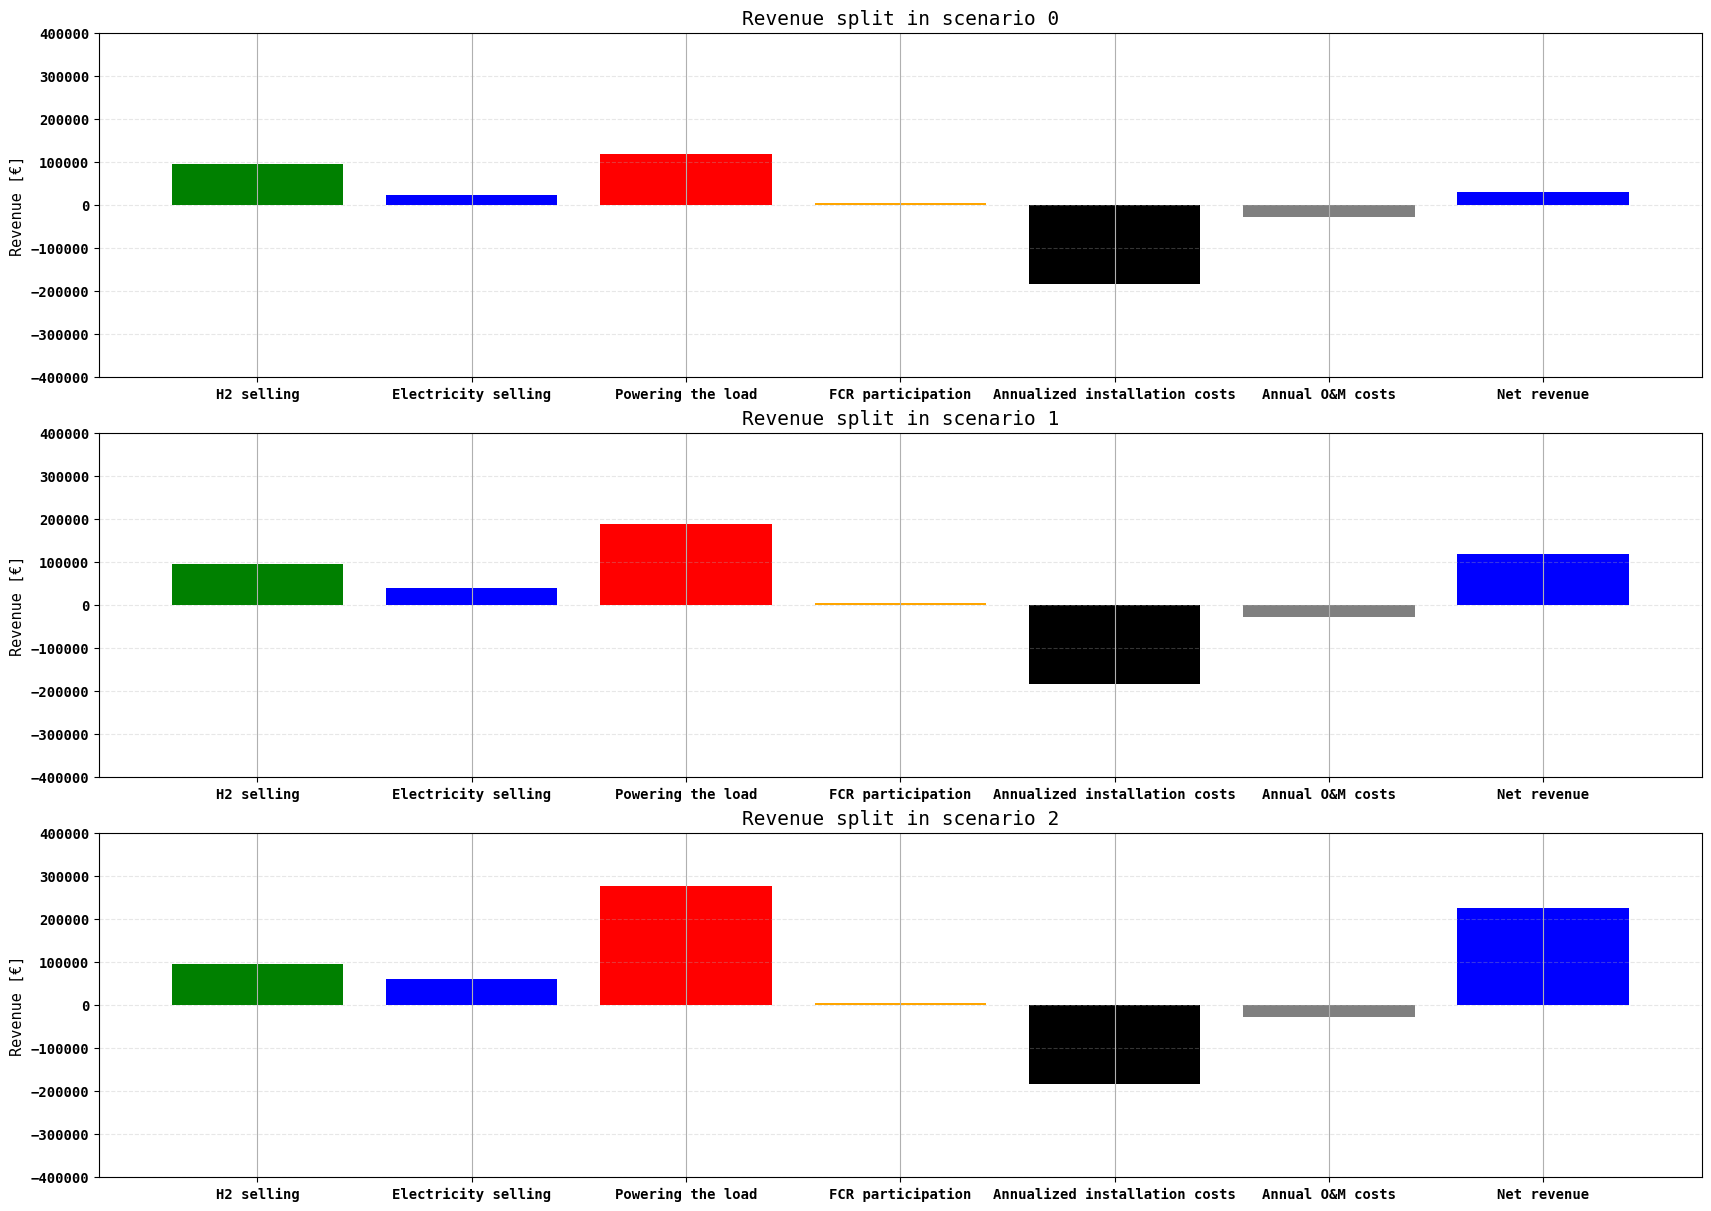

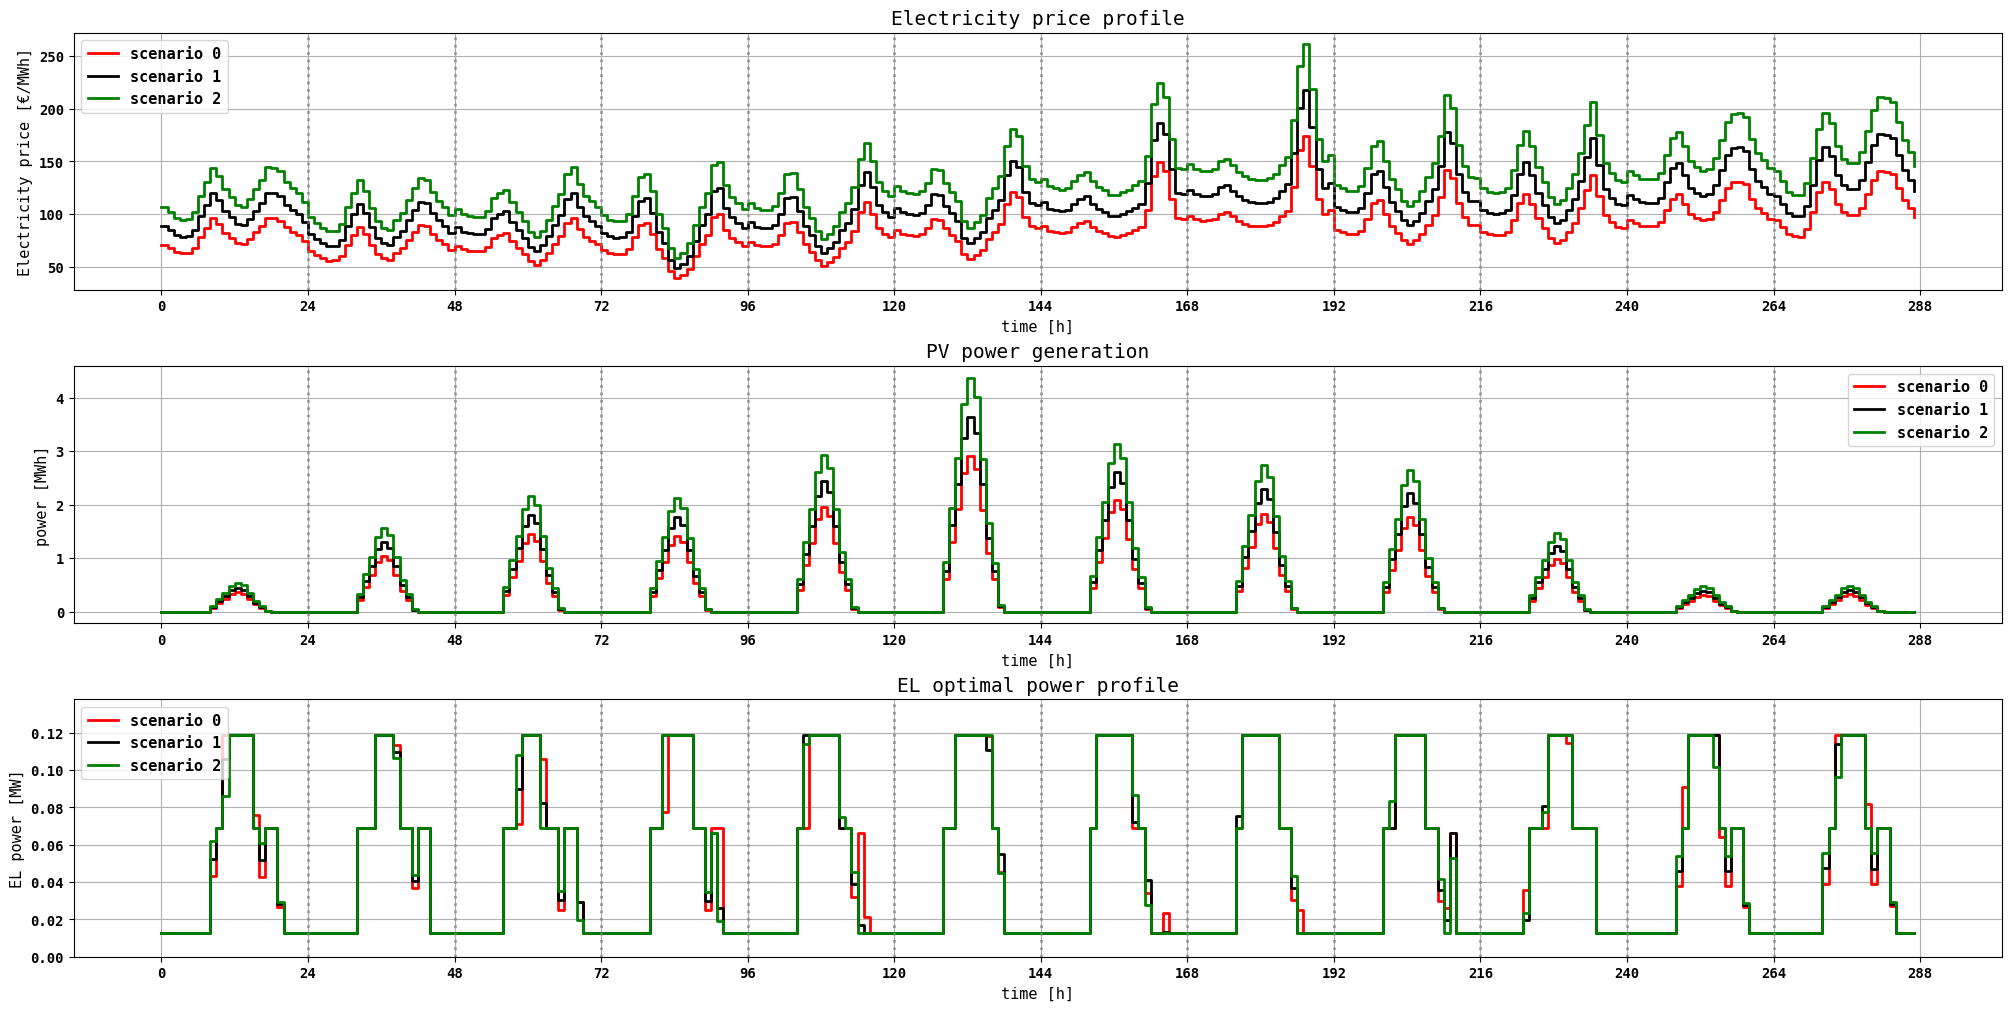

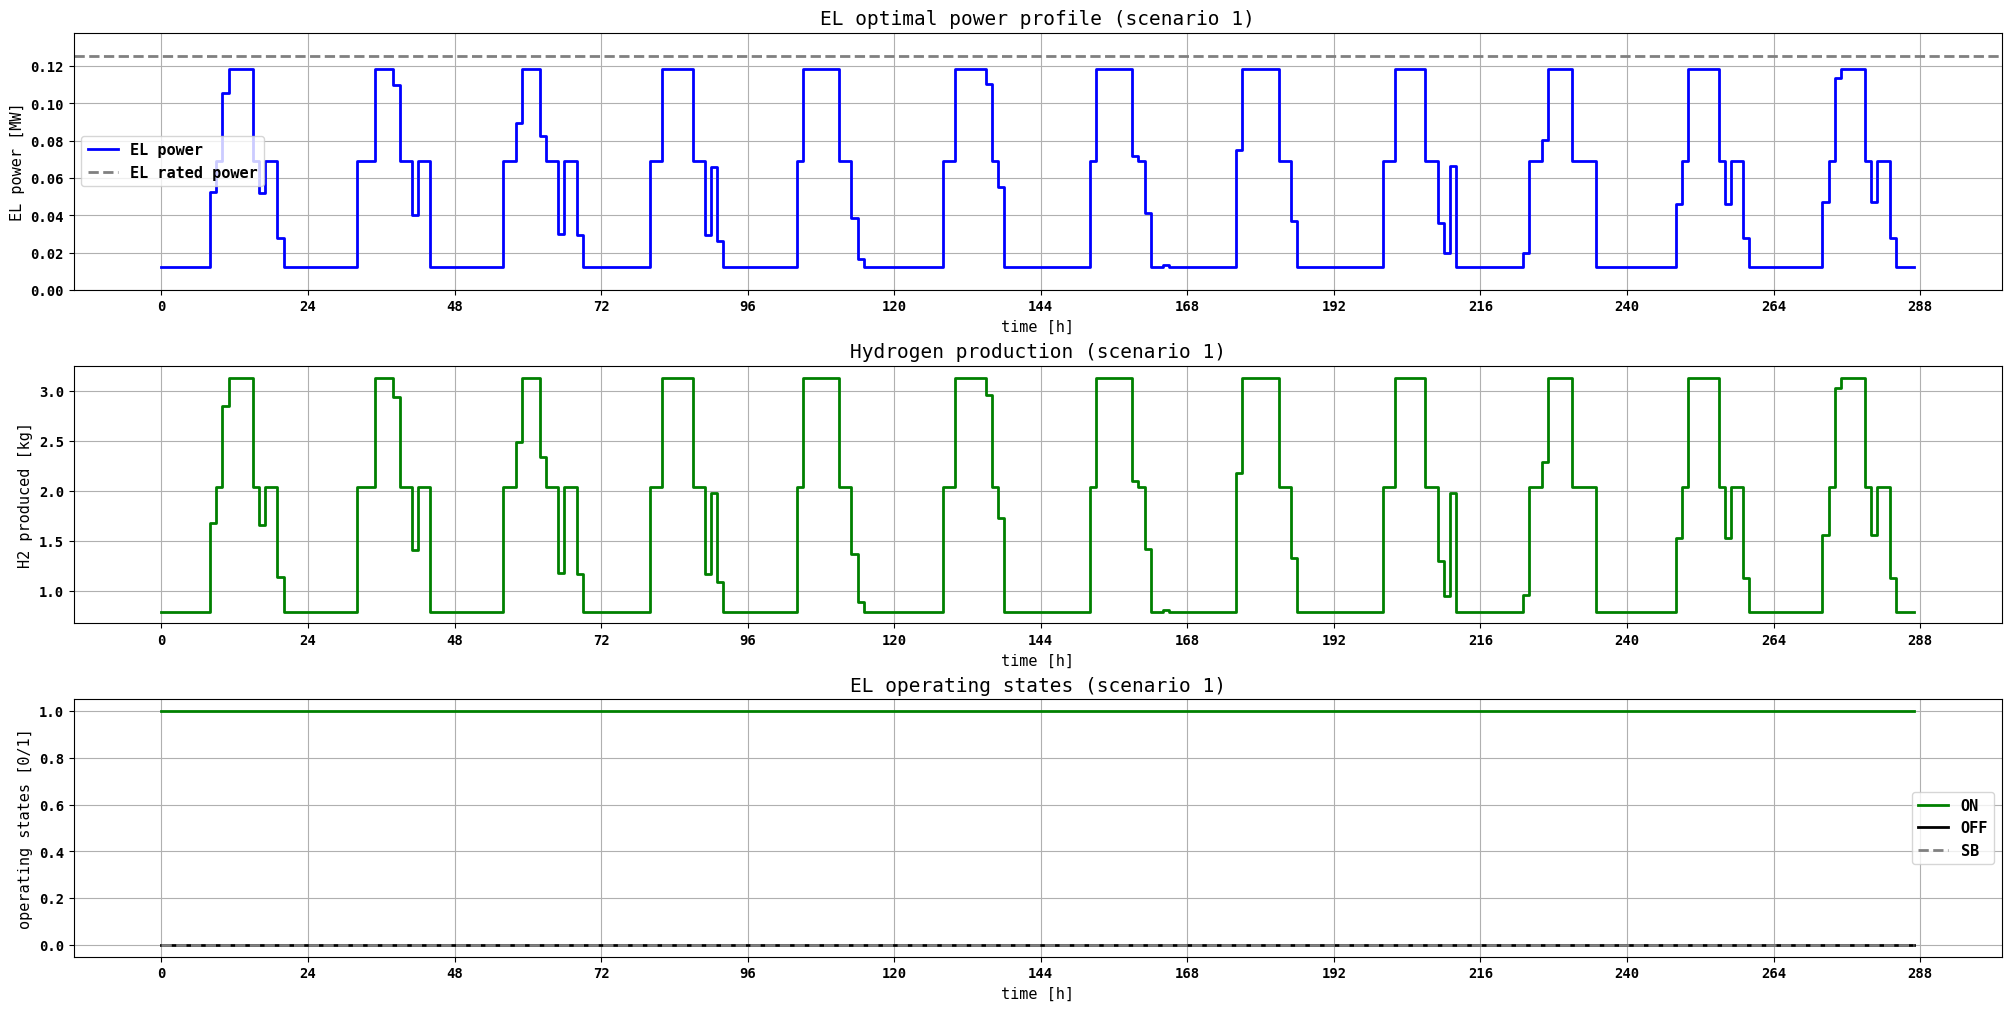

In [ ]:
#------------------------------------------------------------------------------------------------
# PLOTTING (1/3)
#------------------------------------------------------------------------------------------------
# time_plot = time[:time_window + 1]      # time array for plotting
time_plot = np.arange(0, N_t + 1)                # time array for single day plotting
time_plot_tdays = np.arange(0, N_t * N_d + 1)    # time array for typical days plotting
day_2plot = 0                                    # specific day for plotting
scenarios = [0, int(num_scen/2), num_scen - 1]   # specific scenarios selected for plotting


# Plot settings ---------------------------------------------------------------------------------
plt.rc('figure', figsize=(20, 10))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2


# RESULTS PLOTS ---------------------------------------------------------------------------------
labels = ['H2 selling', 'Electricity selling', 'Powering the load', 'FCR participation', 'Annualized installation costs', 'Annual O&M costs']
colors = ['green', 'blue', 'red', 'orange', 'black', 'grey']
# values = [rev_h2sell, rev_elecsell, rev_loadpower, rev_FCR, -ann_install_costs, -ann_om_costs]

figRES, axsRES = plt.subplots(len(scenarios), 1, layout='constrained')
for s in range(len(scenarios)):
    values = [rev_h2sell_scen[scenarios[s]], rev_elecsell_scen[scenarios[s]], rev_loadpower_scen[scenarios[s]], rev_FCR_scen[scenarios[s]], -ann_install_costs, -ann_om_costs]
    axsRES[s].bar(labels, values, color = colors)
    # axsRES[s].bar(['Total Revenue'], [rev_h2sell_scen[scenarios[s]]], label='Hydrogen', color = colors[0])
    # axsRES[s].bar(['Total Revenue'], [rev_elecsell_scen[scenarios[s]]], bottom=[rev_h2sell_scen[scenarios[s]]], label='Electricity', color = colors[1])
    # axsRES[s].bar(['Total Revenue'], [rev_FCR_scen[scenarios[s]]], bottom=[rev_h2sell_scen[scenarios[s]] + rev_elecsell_scen[scenarios[s]]], label='Other', color = colors[2])
    axsRES[s].bar(['Net revenue'], [rev_tot_scen[scenarios[s]]], color = 'blue')
    axsRES[s].set_ylabel("Revenue [€]")
    axsRES[s].set_ylim(-4e5, 4e5)
    axsRES[s].set_title(f'Revenue split in scenario {scenarios[s]}')
    axsRES[s].grid(axis='y', linestyle='--', alpha=0.3)
    axsRES[s].figure.set_size_inches(17, 12)
    # plt.tight_layout()


# INPUT PLOTS -----------------------------------------------------------------------------------
# TIME WINDOW
# Electricity cost plot
figIN, axsIN = plt.subplots(3, 1, layout='constrained')
axsIN[0].step(time_plot_tdays[:-1], C_ele_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsIN[0].step(time_plot_tdays[:-1], C_ele_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsIN[0].step(time_plot_tdays[:-1], C_ele_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsIN[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN[0].set_xlabel('time [h]')
axsIN[0].set_ylabel('Electricity price [€/MWh]')
axsIN[0].set_title("Electricity price profile")
axsIN[0].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN[0].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
# PV power plot
axsIN[1].step(time_plot_tdays[:-1], Ppv_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsIN[1].step(time_plot_tdays[:-1], Ppv_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsIN[1].step(time_plot_tdays[:-1], Ppv_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsIN[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN[1].set_xlabel('time [h]')
axsIN[1].set_ylabel('power [MWh]')
axsIN[1].set_title("PV power generation")
axsIN[1].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN[1].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
# EL power plot
axsIN[2].step(time_plot_tdays[:-1], pel_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsIN[2].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsIN[2].step(time_plot_tdays[:-1], pel_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsIN[2].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN[2].set_xlabel('time [h]')
axsIN[2].set_ylabel('EL power [MW]')
axsIN[2].set_title("EL optimal power profile")
axsIN[2].set_ylim(0, 1.1 * m.Cel['EL'].value)
axsIN[2].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN[2].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )


# EL PLOTS --------------------------------------------------------------------------------------
# TIME WINDOW
# EL power plot
figEL, axsEL = plt.subplots(3, 1, layout='constrained')
axsEL[0].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'blue', label = 'EL power')
axsEL[0].axhline(y=m.Cel['EL'].value, color = 'grey', linestyle = '--', label = 'EL rated power')
axsEL[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsEL[0].set_xlabel('time [h]')
axsEL[0].set_ylabel('EL power [MW]')
axsEL[0].set_title(f'EL optimal power profile (scenario {scenarios[1]})')
axsEL[0].set_ylim(0, 1.1 * m.Cel['EL'].value)
axsEL[0].legend()
# Hydrogen production plot
axsEL[1].step(time_plot_tdays[:-1], hel_vals[scenarios[1], :, :].reshape(-1), color = 'green', where='post')
axsEL[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsEL[1].set_xlabel('time [h]')
axsEL[1].set_ylabel('H2 produced [kg]')
axsEL[1].set_title(f'Hydrogen production (scenario {scenarios[1]})')
# EL operating states plot
axsEL[2].step(time_plot_tdays[:-1], xel_on_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'green', label = 'ON')
axsEL[2].step(time_plot_tdays[:-1], xel_off_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = 'OFF')
axsEL[2].step(time_plot_tdays[:-1], xel_sb_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'grey', linestyle='--', label = 'SB')
# axs[2].step(time_plot[day * 24 : (day+1) * 24], xel_su_vals[day * 24 : (day+1) * 24], color = 'red', where='post')
axsEL[2].set_xticks([day * 24 for day in range(N_d + 1)])
axsEL[2].set_xlabel('time [h]')
axsEL[2].set_ylabel('operating states [0/1]')
axsEL[2].set_title(f'EL operating states (scenario {scenarios[1]})')
axsEL[2].legend()

C:\Users\massi\AppData\Local\Temp\ipykernel_6672\2549632263.py:128: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axsFC.set_ylim(0, 1.1 * m.Cfc['FC'].value)


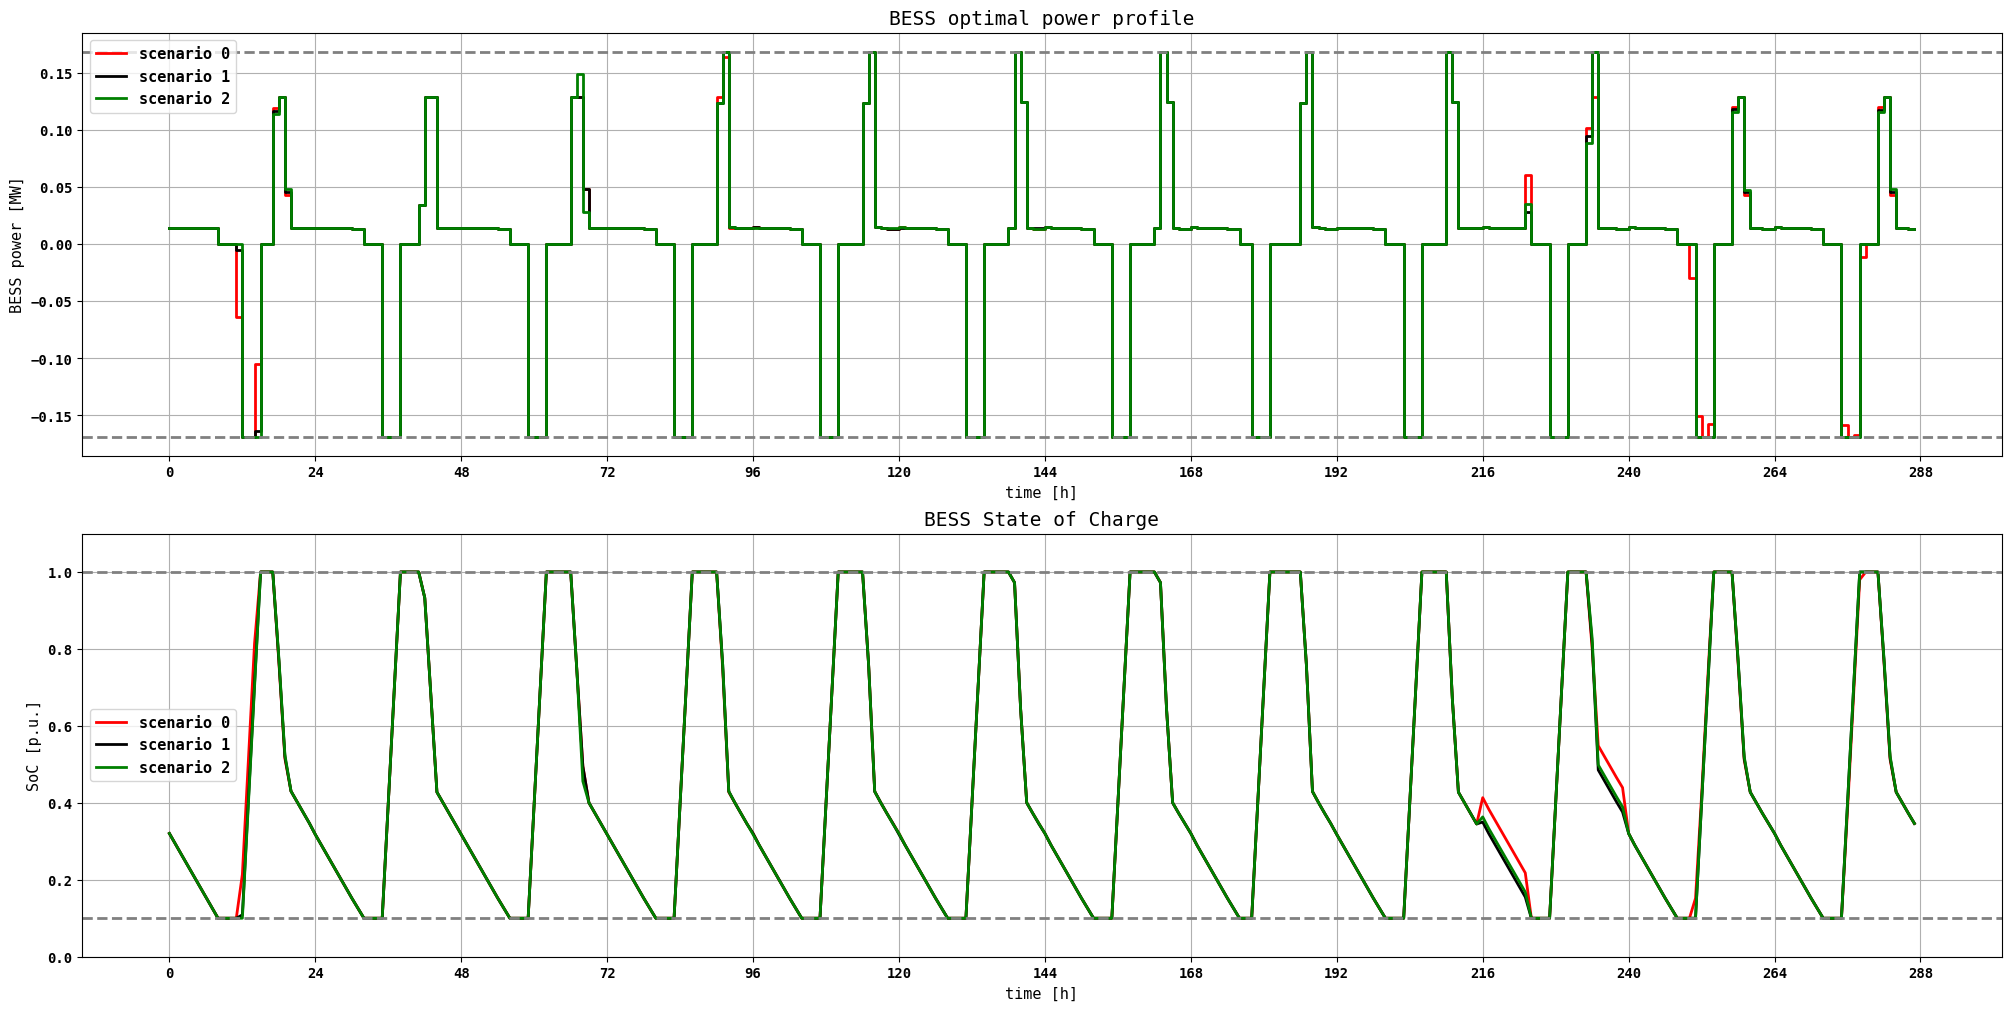

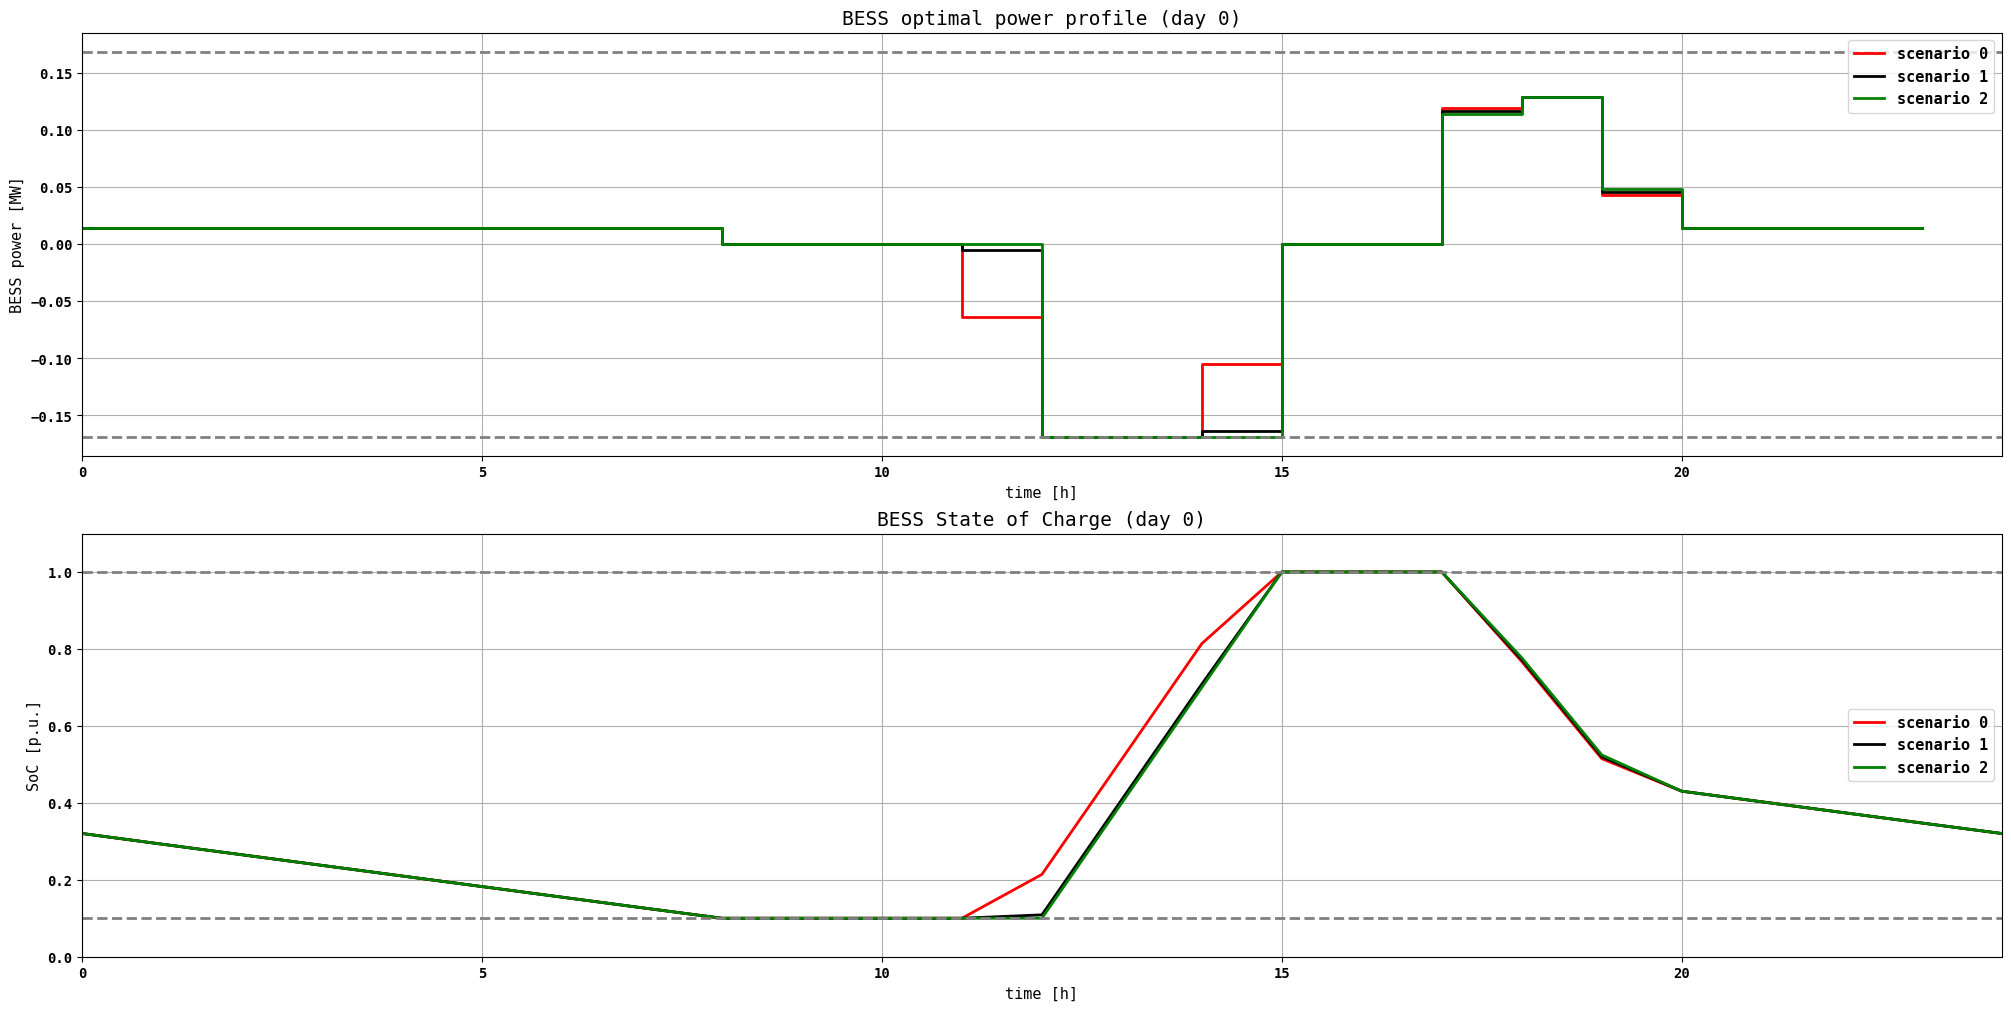

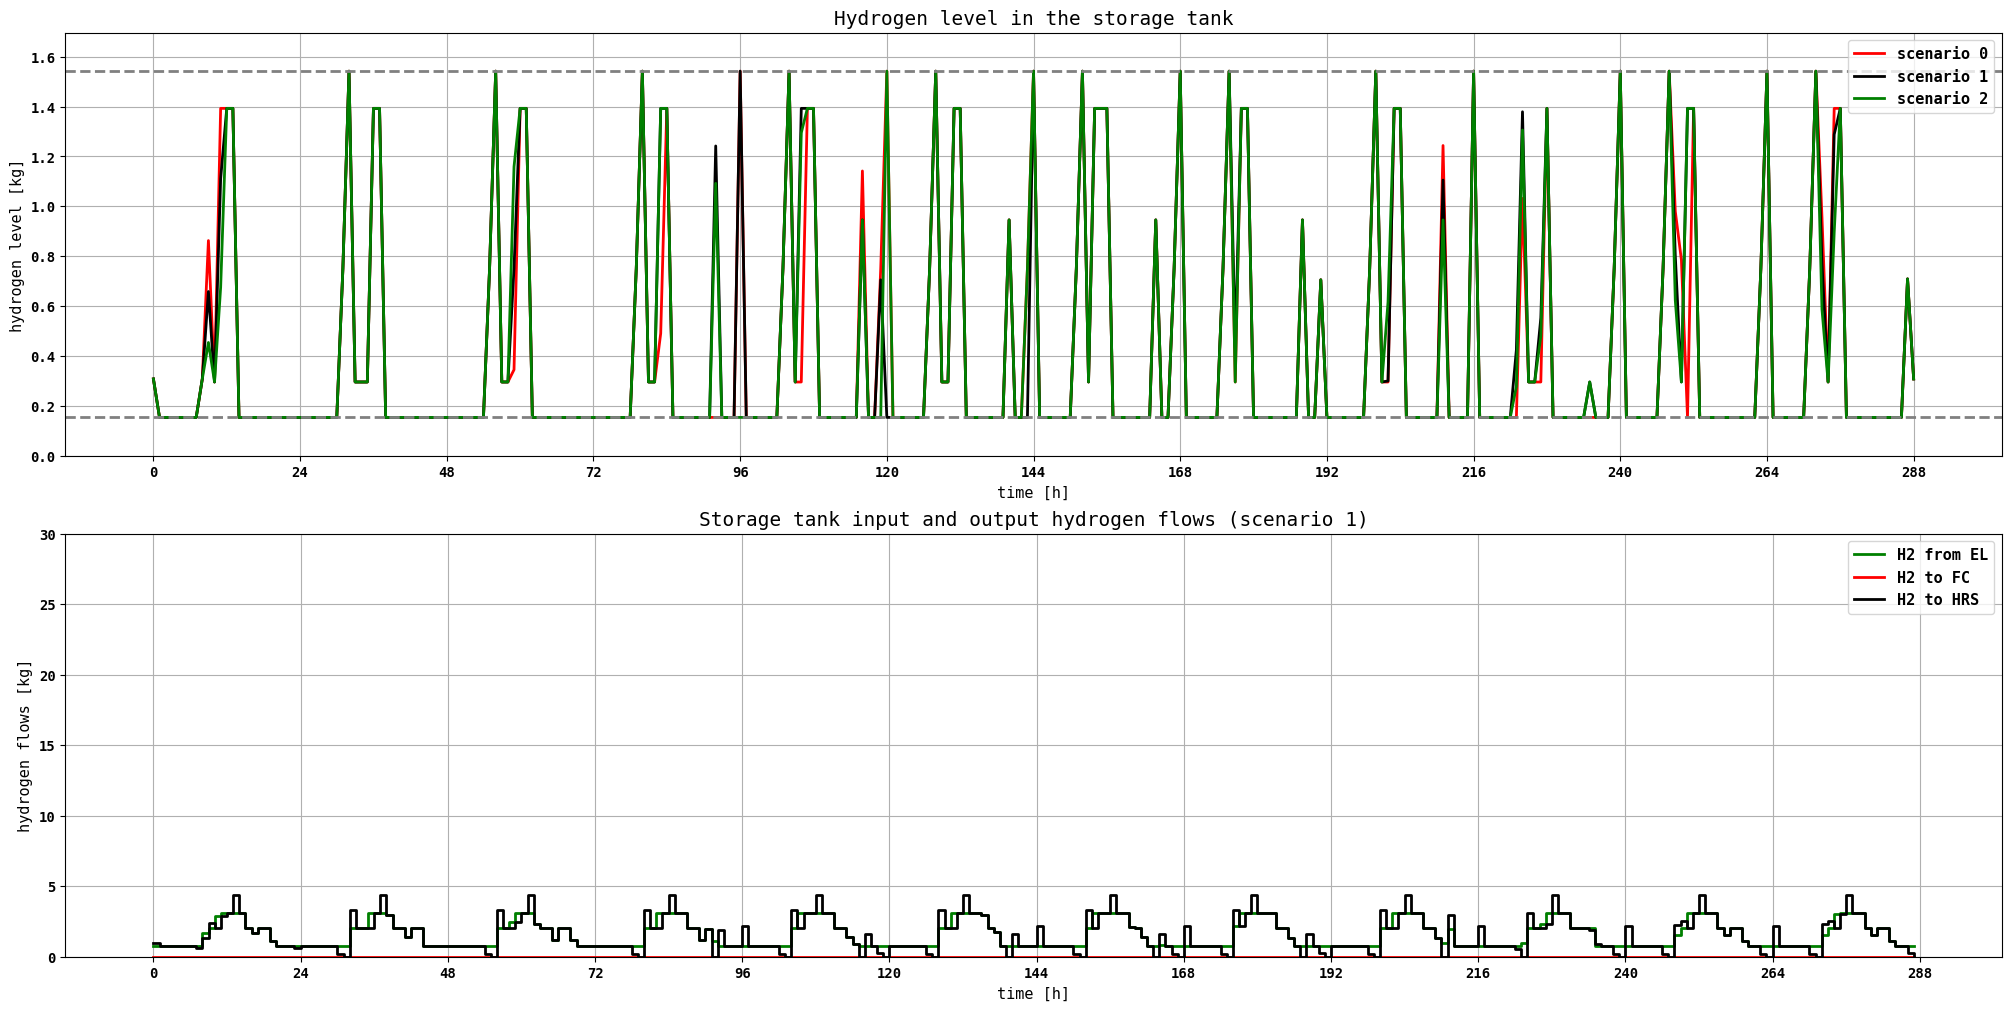

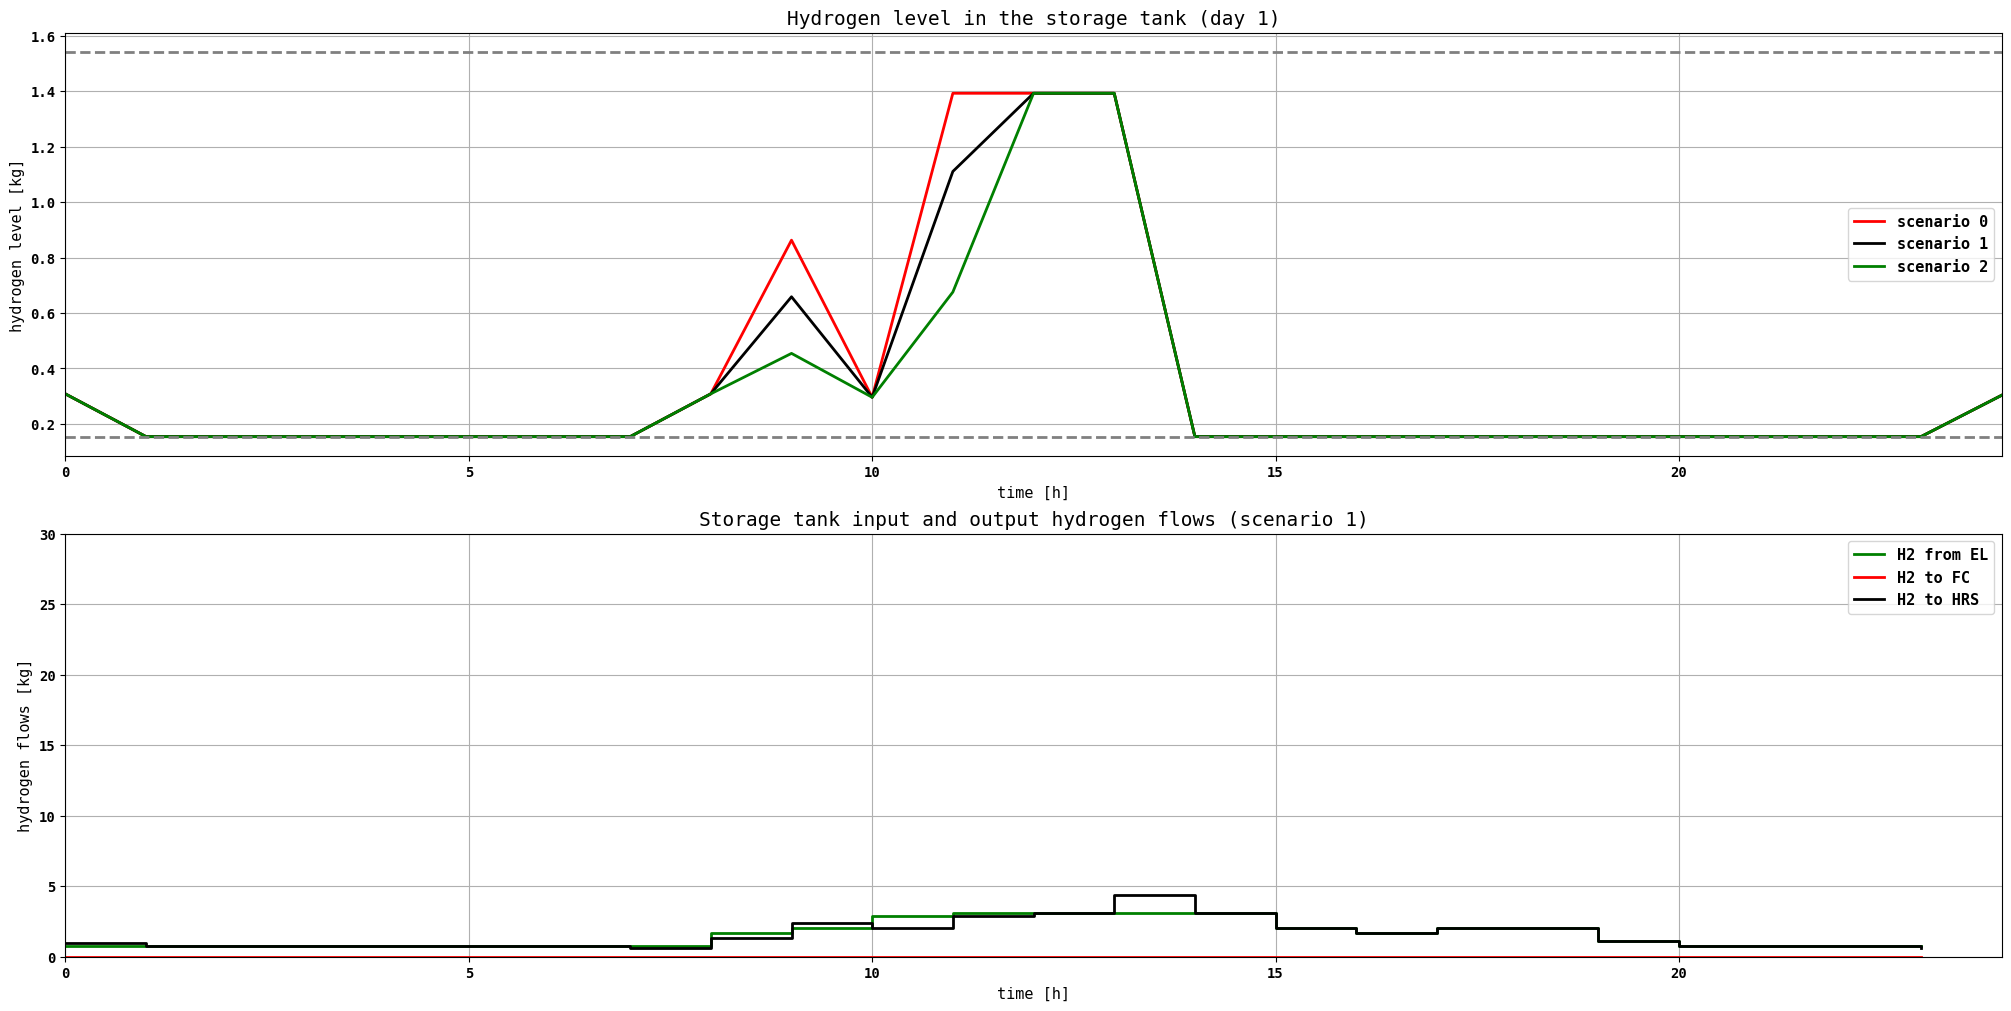

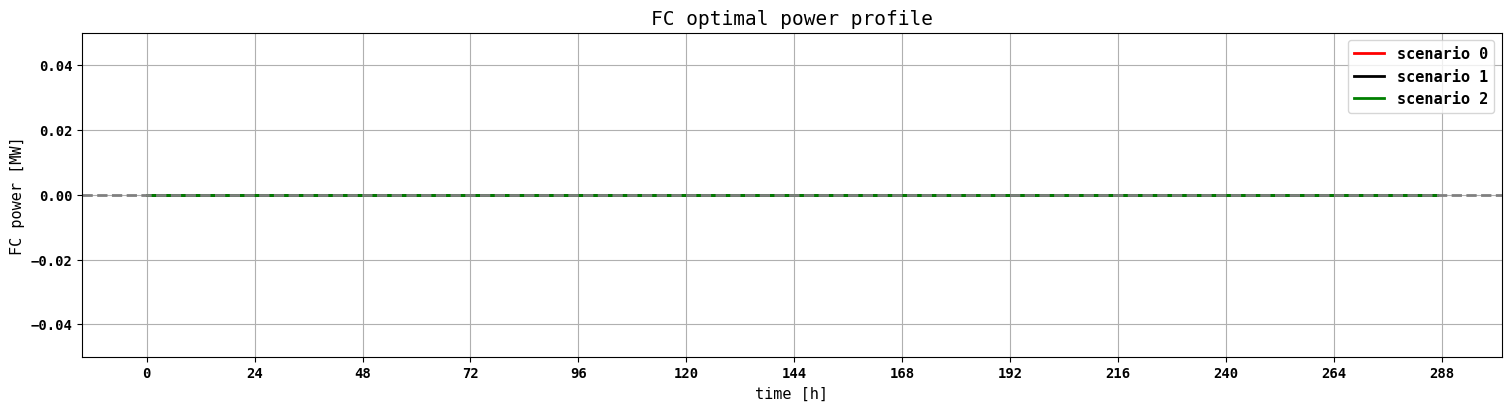

In [ ]:
#------------------------------------------------------------------------------------------------
# PLOTTING (2/3)
#------------------------------------------------------------------------------------------------

# BESS PLOTS ------------------------------------------------------------------------------------
# TIME WINDOW
# BESS power plot
figBESS, axsBESS = plt.subplots(2, 1, layout='constrained')
axsBESS[0].step(time_plot_tdays[:-1], pb_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsBESS[0].step(time_plot_tdays[:-1], pb_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsBESS[0].step(time_plot_tdays[:-1], pb_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsBESS[0].axhline(y=m.Cb_mw['BESS'].value, color = 'grey', linestyle = '--')
axsBESS[0].axhline(y=-m.Cb_mw['BESS'].value, color = 'grey', linestyle = '--')
axsBESS[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsBESS[0].set_xlabel('time [h]')
axsBESS[0].set_ylabel('BESS power [MW]')
axsBESS[0].set_title('BESS optimal power profile')
axsBESS[0].legend()
# BESS SoC plot
axsBESS[1].plot(time_plot_tdays[:-1], soc_vals[scenarios[0], :, :-1].reshape(-1), color = 'red', label = f'scenario {scenarios[0]}')
axsBESS[1].plot(time_plot_tdays[:-1], soc_vals[scenarios[1], :, :-1].reshape(-1), color = 'black', label = f'scenario {scenarios[1]}')
axsBESS[1].plot(time_plot_tdays[:-1], soc_vals[scenarios[2], :, :-1].reshape(-1), color = 'green', label = f'scenario {scenarios[2]}')
axsBESS[1].axhline(y=1, color = 'grey', linestyle = '--')
axsBESS[1].axhline(y=m.alfa_b_dod['BESS'], color = 'grey', linestyle = '--')
axsBESS[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsBESS[1].set_xlabel('time [h]')
axsBESS[1].set_ylabel('SoC [p.u.]')
axsBESS[1].set_title('BESS State of Charge')
axsBESS[1].set_ylim(0, 1.1)
axsBESS[1].legend()
# # BESS operating states plot
# axs2[2].step(time_plot[week*24*7 : (week+1)*24*7], pb_dch_vals[week*24*7 : (week+1)*24*7] - pb_ch_vals[week*24*7 : (week+1)*24*7], color = 'blue')
# axs2[2].step(time_plot[week*24*7 : (week+1)*24*7], 0.5*xb_vals[week*24*7 : (week+1)*24*7], color = 'black')

# CHOSEN DAY
# BESS power plot
figBESS2, axsBESS2 = plt.subplots(2, 1, layout='constrained')
axsBESS2[0].step(time_plot[:-1], pb_vals[scenarios[0], day_2plot, :], where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsBESS2[0].step(time_plot[:-1], pb_vals[scenarios[1], day_2plot, :], where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsBESS2[0].step(time_plot[:-1], pb_vals[scenarios[2], day_2plot, :], where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsBESS2[0].axhline(y=m.Cb_mw['BESS'].value, color = 'grey', linestyle = '--')
axsBESS2[0].axhline(y=-m.Cb_mw['BESS'].value, color = 'grey', linestyle = '--')
axsBESS2[0].set_xlabel('time [h]')
axsBESS2[0].set_ylabel('BESS power [MW]')
axsBESS2[0].set_title(f'BESS optimal power profile (day {day_2plot})')
axsBESS2[0].set_xlim(0, 24)
axsBESS2[0].legend()
# BESS SoC plot
axsBESS2[1].plot(time_plot, soc_vals[scenarios[0], day_2plot, :], color = 'red', label = f'scenario {scenarios[0]}')
axsBESS2[1].plot(time_plot, soc_vals[scenarios[1], day_2plot, :], color = 'black', label = f'scenario {scenarios[1]}')
axsBESS2[1].plot(time_plot, soc_vals[scenarios[2], day_2plot, :], color = 'green', label = f'scenario {scenarios[2]}')
axsBESS2[1].axhline(y=1, color = 'grey', linestyle = '--')
axsBESS2[1].axhline(y=m.alfa_b_dod['BESS'], color = 'grey', linestyle = '--')
axsBESS2[1].set_xlabel('time [h]')
axsBESS2[1].set_ylabel('SoC [p.u.]')
axsBESS2[1].set_title(f'BESS State of Charge (day {day_2plot})')
axsBESS2[1].set_ylim(0, 1.1)
axsBESS2[1].set_xlim(0, 24)
axsBESS2[1].legend()


# HYDROGEN STORAGE PLOTS ------------------------------------------------------------------------
# TIME WINDOW
# HSS hydrogen level plot
figHSS, axsHSS = plt.subplots(2, 1, layout='constrained')
# axsHSS[0].plot(time_plot_tdays[:-1], hhss_vals[scenarios[0], :, :-1].reshape(-1), color = 'black')
axsHSS[0].plot(time_plot_tdays, np.append(hhss_vals[scenarios[0], :, :-1].reshape(-1), hhss_seas_vals[scenarios[0], -1, -1]),
                color = 'red', label = f'scenario {scenarios[0]}')
axsHSS[0].plot(time_plot_tdays, np.append(hhss_vals[scenarios[1], :, :-1].reshape(-1), hhss_seas_vals[scenarios[1], -1, -1]),
                color = 'black', label = f'scenario {scenarios[1]}')
axsHSS[0].plot(time_plot_tdays, np.append(hhss_vals[scenarios[2], :, :-1].reshape(-1), hhss_seas_vals[scenarios[2], -1, -1]),
                color = 'green', label = f'scenario {scenarios[2]}')
axsHSS[0].axhline(y=m.Chss['HSS'].value, color = 'grey', linestyle = '--')
axsHSS[0].axhline(y=m.alfa_hss_min['HSS'] * m.Chss['HSS'].value, color = 'grey', linestyle = '--')
axsHSS[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsHSS[0].set_xlabel('time [h]')
axsHSS[0].set_ylabel('hydrogen level [kg]')
axsHSS[0].set_title("Hydrogen level in the storage tank")
axsHSS[0].set_ylim(0, 1.1 * m.Chss['HSS'].value)
axsHSS[0].legend()
# Input and outputs of the HSS (without efficiencies)
axsHSS[1].step(time_plot_tdays[:-1], hel_vals[scenarios[1], :, :].reshape(-1), color = 'green', label = 'H2 from EL', where='post')
axsHSS[1].step(time_plot_tdays[:-1], hfc_vals[scenarios[1], :, :].reshape(-1), color = 'red', label = 'H2 to FC', where='post')
axsHSS[1].step(time_plot_tdays[:-1], hdem_vals[scenarios[1], :, :].reshape(-1), color = 'black', label = 'H2 to HRS', where='post')
axsHSS[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsHSS[1].set_xlabel('time [h]')
axsHSS[1].set_ylabel('hydrogen flows [kg]')
axsHSS[1].set_title(f'Storage tank input and output hydrogen flows (scenario {scenarios[1]})')
axsHSS[1].set_ylim(0, 30)
axsHSS[1].legend()

# CHOSEN DAY
# HSS hydrogen level plot
figHSS2, axsHSS2 = plt.subplots(2, 1, layout='constrained')
axsHSS2[0].plot(time_plot, hhss_vals[scenarios[0], day_2plot, :], color = 'red', label = f'scenario {scenarios[0]}')
axsHSS2[0].plot(time_plot, hhss_vals[scenarios[1], day_2plot, :], color = 'black', label = f'scenario {scenarios[1]}')
axsHSS2[0].plot(time_plot, hhss_vals[scenarios[2], day_2plot, :], color = 'green', label = f'scenario {scenarios[2]}')
axsHSS2[0].axhline(y=m.Chss['HSS'].value, color = 'grey', linestyle = '--')
axsHSS2[0].axhline(y=m.alfa_hss_min['HSS'] * m.Chss['HSS'].value, color = 'grey', linestyle = '--')
axsHSS2[0].set_xlabel('time [h]')
axsHSS2[0].set_ylabel('hydrogen level [kg]')
axsHSS2[0].set_title(f"Hydrogen level in the storage tank (day {day_2plot + 1})")
# axsHSS2[0].set_ylim(0.95 * min(hhss_vals[week*24*7 + 1 : (week+1)*24*7 + 1]), 1.05 * max(hhss_vals[week*24*7 + 1 : (week+1)*24*7 + 1]))
axsHSS2[0].set_xlim(0, 24)
axsHSS2[0].legend()
# Input and outputs of the HSS (without efficiencies)
axsHSS2[1].step(time_plot[:-1], hel_vals[scenarios[1], day_2plot, :], color = 'green', label = 'H2 from EL', where='post')
axsHSS2[1].step(time_plot[:-1], hfc_vals[scenarios[1], day_2plot, :], color = 'red', label = 'H2 to FC', where='post')
axsHSS2[1].step(time_plot[:-1], hdem_vals[scenarios[1], day_2plot, :], color = 'black', label = 'H2 to HRS', where='post')
axsHSS2[1].set_xlabel('time [h]')
axsHSS2[1].set_ylabel('hydrogen flows [kg]')
axsHSS2[1].set_title(f'Storage tank input and output hydrogen flows (scenario {scenarios[1]})')
axsHSS2[1].set_ylim(0, 30)
axsHSS2[1].set_xlim(0, 24)
axsHSS2[1].legend()


# FC power plot
figFC, axsFC = plt.subplots(layout='constrained', figsize=(15, 4))
axsFC.step(time_plot_tdays[:-1], pfc_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsFC.step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsFC.step(time_plot_tdays[:-1], pfc_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsFC.axhline(y=m.alfa_fc_min['FC'] * m.Cfc['FC'].value, color = 'grey', linestyle = '--')
axsFC.set_xticks([day * 24 for day in range(N_d + 1)])
axsFC.set_xlabel('time [h]')
axsFC.set_ylabel('FC power [MW]')
axsFC.set_title("FC optimal power profile")
axsFC.set_ylim(0, 1.1 * m.Cfc['FC'].value)
axsFC.legend()

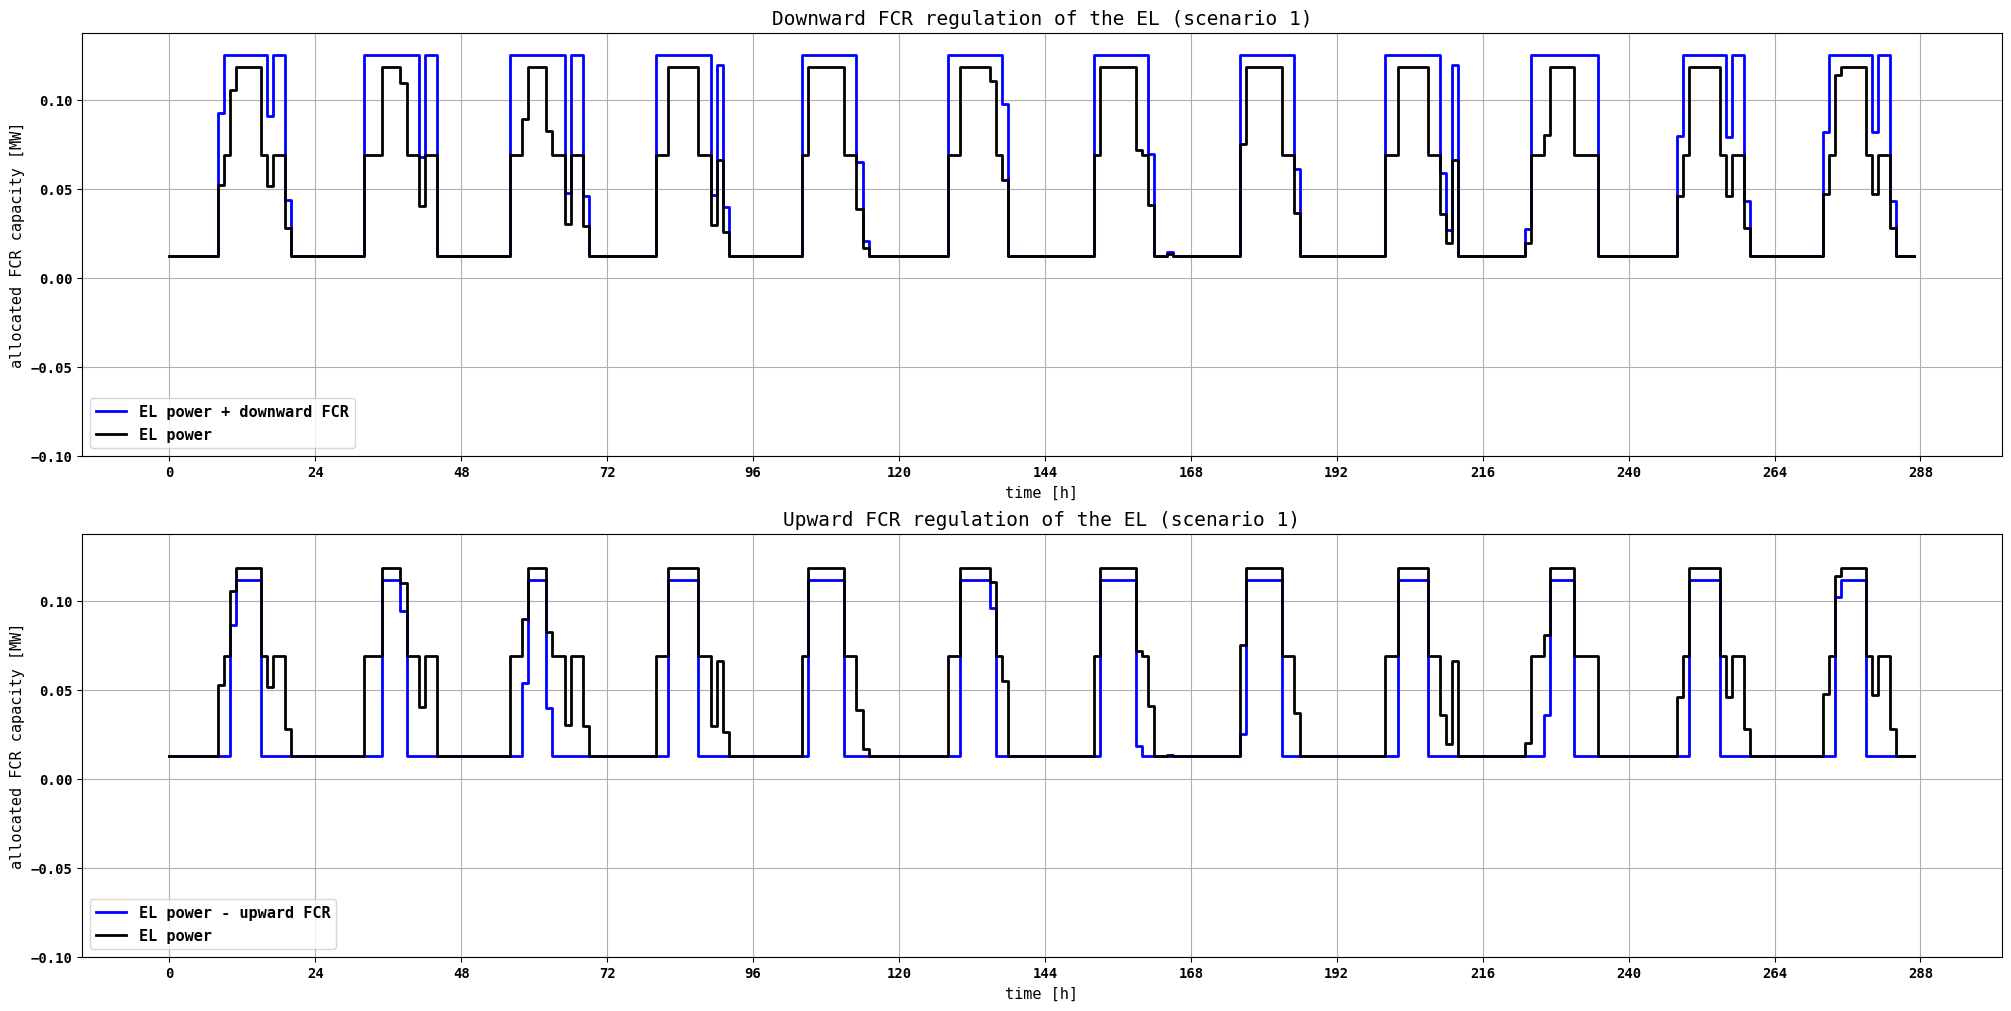

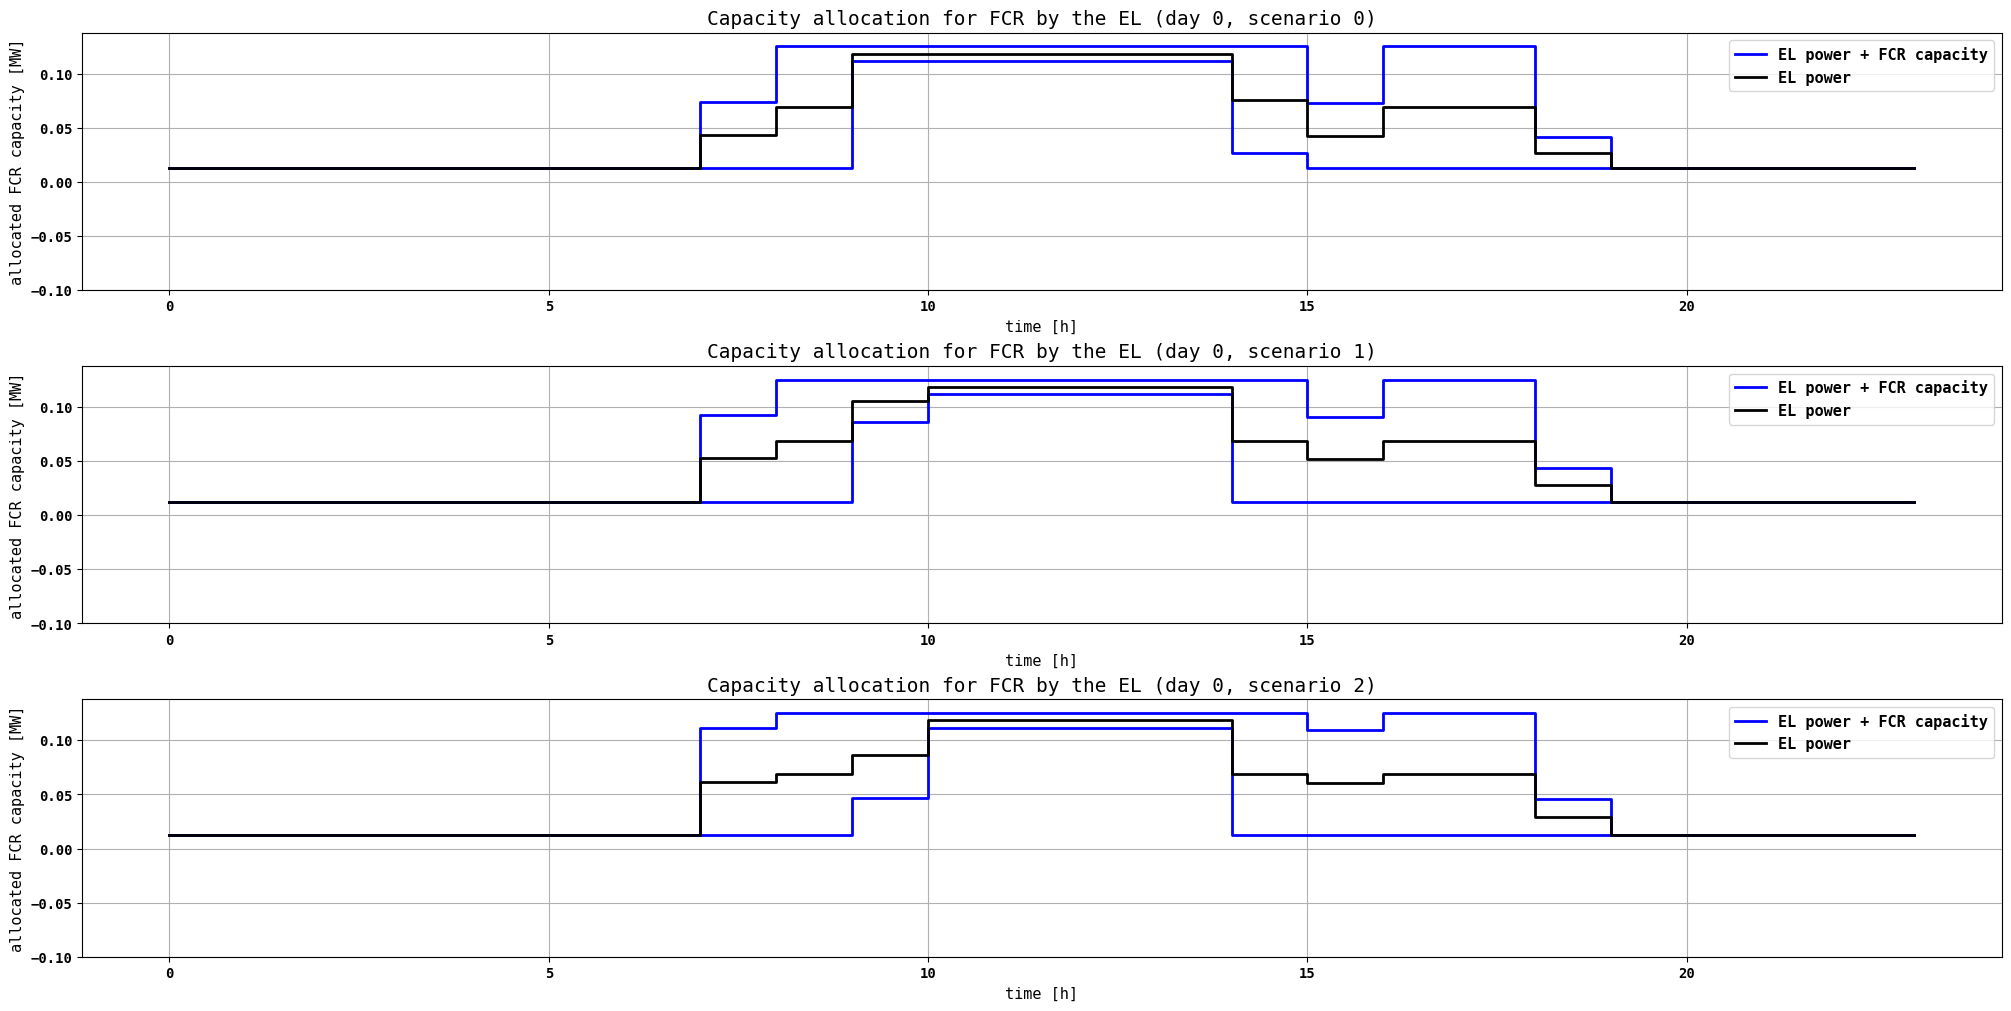

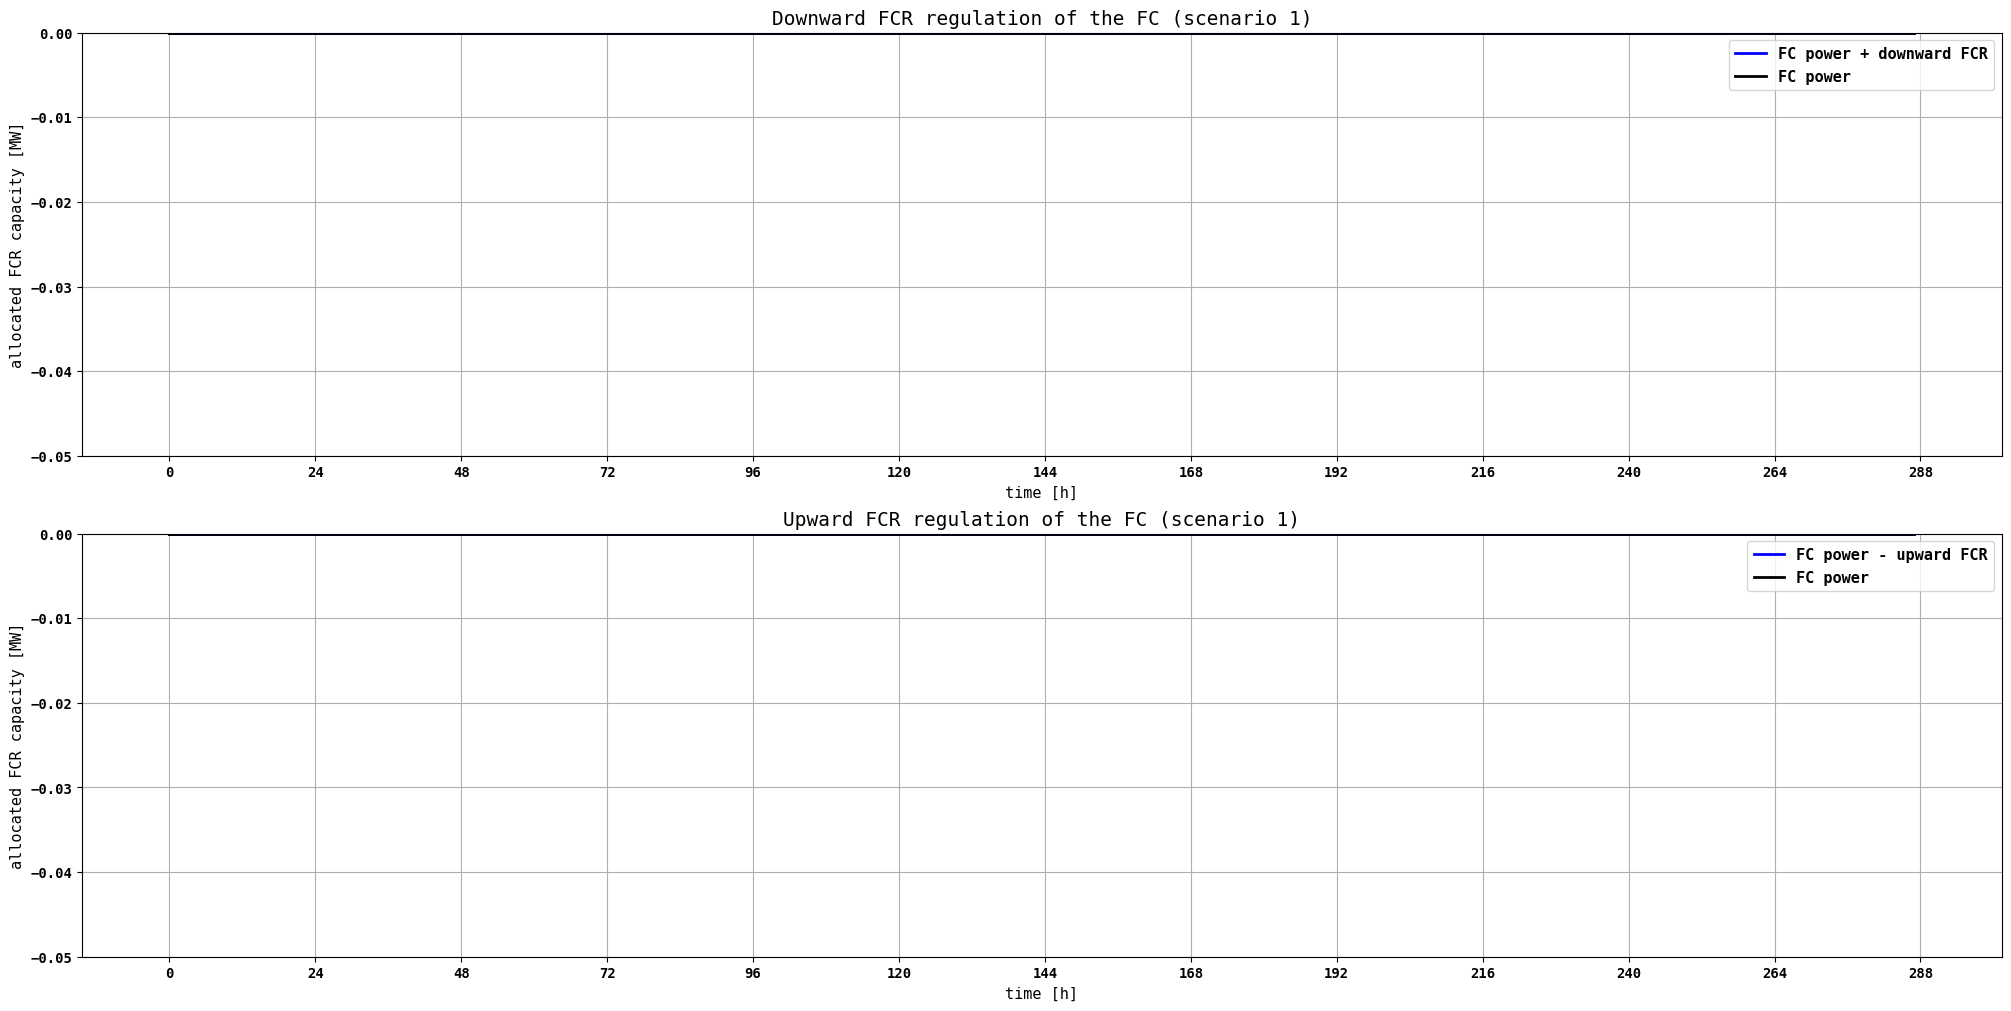

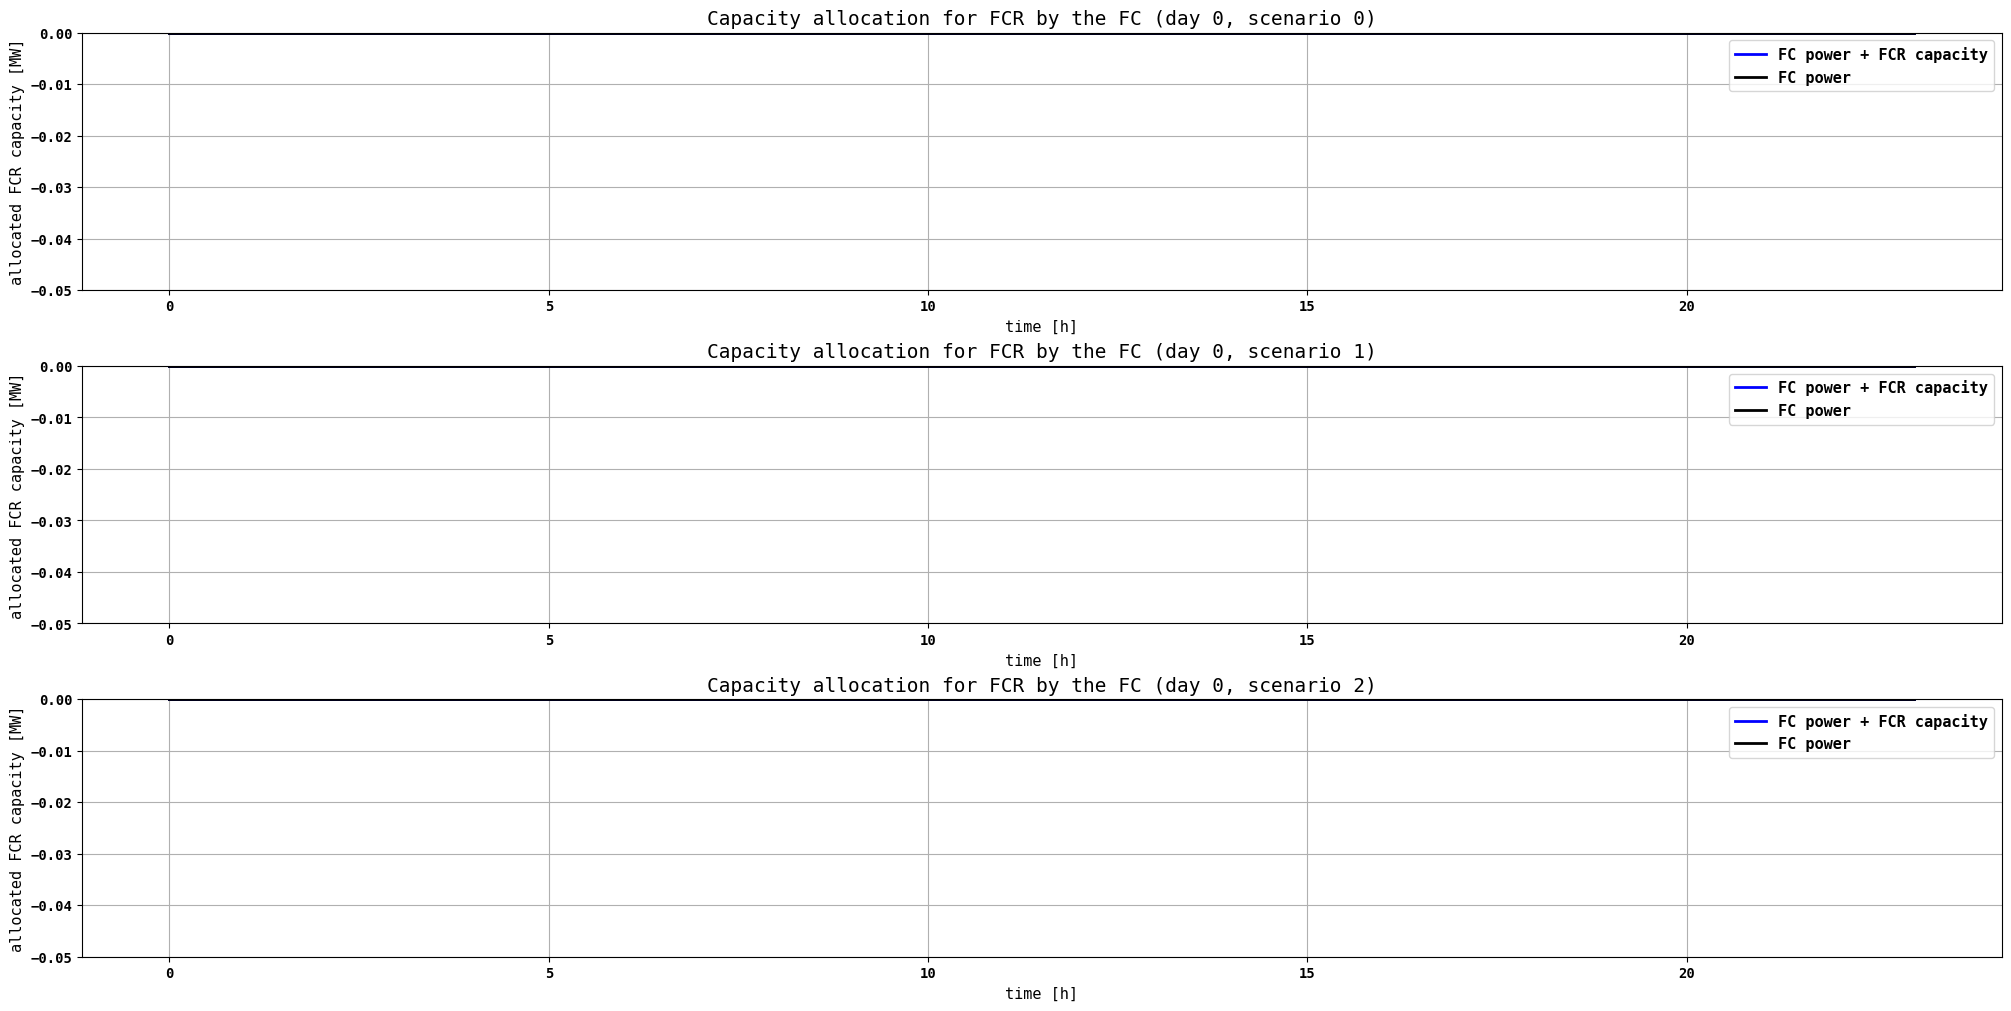

In [ ]:
#------------------------------------------------------------------------------------------------
# PLOTTING (3/3)
#------------------------------------------------------------------------------------------------

# FCR EL PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW
# FCR EL capacity allocation plot, downward regulation
figFCRel, axsFCRel = plt.subplots(2, 1, layout = 'constrained')
axsFCRel[0].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1) + pel_fcr_dwn_vals[scenarios[1], :].reshape(-1),
                  color = 'blue', label = 'EL power + downward FCR', where='post')
axsFCRel[0].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1),
                  color = 'black', label = 'EL power', where='post')
axsFCRel[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRel[0].set_xlabel('time [h]')
axsFCRel[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[0].set_title(f'Downward FCR regulation of the EL (scenario {scenarios [1]})')
axsFCRel[0].set_ylim(-0.1, 1.1 * m.Cel['EL'].value)
axsFCRel[0].legend()
# FCR EL capacity allocation plot, upward regulation
axsFCRel[1].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1) - pel_fcr_up_vals[scenarios[1], :].reshape(-1),
                  color = 'blue', label = 'EL power - upward FCR', where='post')
axsFCRel[1].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1),
                  color = 'black', label = 'EL power', where='post')
axsFCRel[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRel[1].set_xlabel('time [h]')
axsFCRel[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[1].set_title(f'Upward FCR regulation of the EL (scenario {scenarios [1]})')
axsFCRel[1].set_ylim(-0.1, 1.1 * m.Cel['EL'].value)
axsFCRel[1].legend()

# CHOSEN DAY
# FCR EL capacity allocation plot
figFCRel, axsFCRel = plt.subplots(len(scenarios), 1, layout = 'constrained')
for i in range(len(scenarios)):
    axsFCRel[i].step(time_plot[:-1], pel_vals[scenarios[i], day_2plot, :] + pel_fcr_dwn_vals[scenarios[i], day_2plot, :],
                      color = 'blue', label = 'EL power + FCR capacity')
    axsFCRel[i].step(time_plot[:-1], pel_vals[scenarios[i], day_2plot, :] - pel_fcr_up_vals[scenarios[i], day_2plot, :],
                      color = 'blue')
    axsFCRel[i].step(time_plot[:-1], pel_vals[scenarios[i], day_2plot, :],
                      color = 'black', label = 'EL power')
    axsFCRel[i].set_xlabel('time [h]')
    axsFCRel[i].set_ylabel('allocated FCR capacity [MW]')
    axsFCRel[i].set_title(f"Capacity allocation for FCR by the EL (day {day_2plot}, scenario {scenarios[i]})")
    axsFCRel[i].set_ylim(-0.1, 1.1 * m.Cel['EL'].value)
    axsFCRel[i].legend()


# FCR FC PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW
# FCR FC capacity allocation plot, downward regulation
figFCRfc, axsFCRfc = plt.subplots(2, 1, layout = 'constrained')
axsFCRfc[0].step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :].reshape(-1) + pfc_fcr_up_vals[scenarios[1], :].reshape(-1),
                  color = 'blue', label = 'FC power + downward FCR', where='post')
axsFCRfc[0].step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :].reshape(-1),
                  color = 'black', label = 'FC power', where='post')
axsFCRfc[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRfc[0].set_xlabel('time [h]')
axsFCRfc[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[0].set_title(f'Downward FCR regulation of the FC (scenario {scenarios [1]})')
axsFCRfc[0].set_ylim(-0.05, 1.1 * m.Cfc['FC'].value)
axsFCRfc[0].legend()
# FCR FC capacity allocation plot, upward regulation
axsFCRfc[1].step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :].reshape(-1) - pfc_fcr_dwn_vals[scenarios[1], :].reshape(-1),
                  color = 'blue', label = 'FC power - upward FCR', where='post')
axsFCRfc[1].step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :].reshape(-1),
                  color = 'black', label = 'FC power', where='post')
axsFCRfc[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRfc[1].set_xlabel('time [h]')
axsFCRfc[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[1].set_title(f'Upward FCR regulation of the FC (scenario {scenarios [1]})')
axsFCRfc[1].set_ylim(-0.05, 1.1 * m.Cfc['FC'].value)
axsFCRfc[1].legend()

# CHOSEN DAY
# FCR FC capacity allocation plot
figFCRfc, axsFCRfc = plt.subplots(3, 1, layout = 'constrained')
for i in range(len(scenarios)):
    axsFCRfc[i].step(time_plot[:-1], pfc_vals[scenarios[i], day_2plot, :] + pfc_fcr_up_vals[scenarios[i], day_2plot, :],
                      color = 'blue', label = 'FC power + FCR capacity')
    axsFCRfc[i].step(time_plot[:-1], pfc_vals[scenarios[i], day_2plot, :] - pfc_fcr_dwn_vals[scenarios[i], day_2plot, :],
                      color = 'blue')
    axsFCRfc[i].step(time_plot[:-1], pfc_vals[scenarios[i], day_2plot, :],
                      color = 'black', label = 'FC power')
    axsFCRfc[i].set_xlabel('time [h]')
    axsFCRfc[i].set_ylabel('allocated FCR capacity [MW]')
    axsFCRfc[i].set_title(f'Capacity allocation for FCR by the FC (day {day_2plot}, scenario {scenarios[i]})')
    axsFCRfc[i].set_ylim(-0.05, 1.1 * m.Cfc['FC'].value)
    axsFCRfc[i].legend()

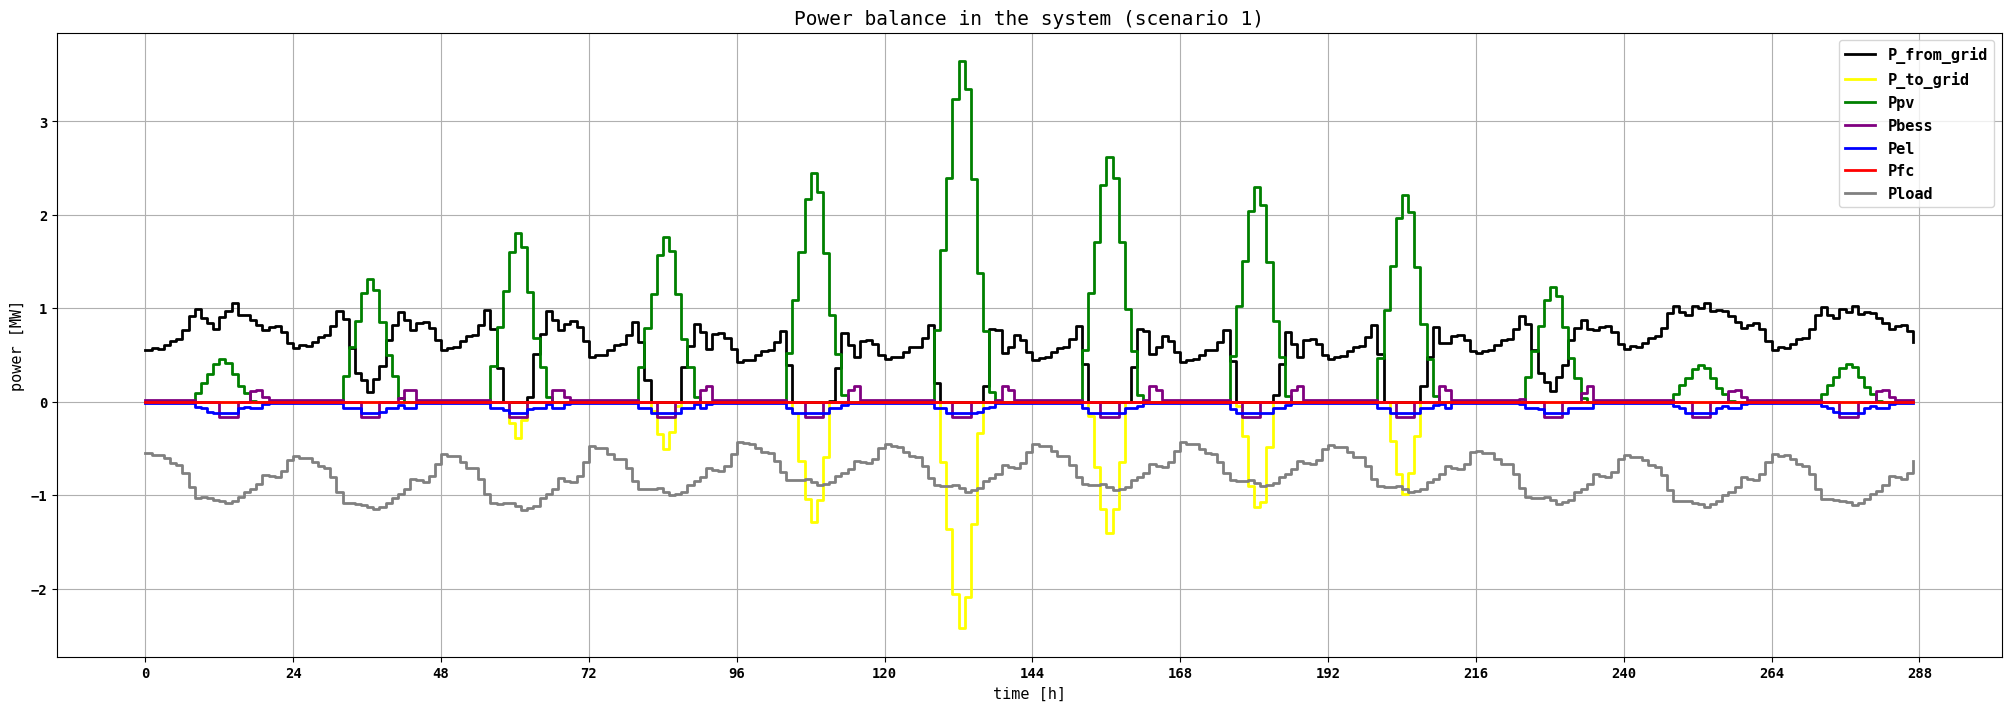

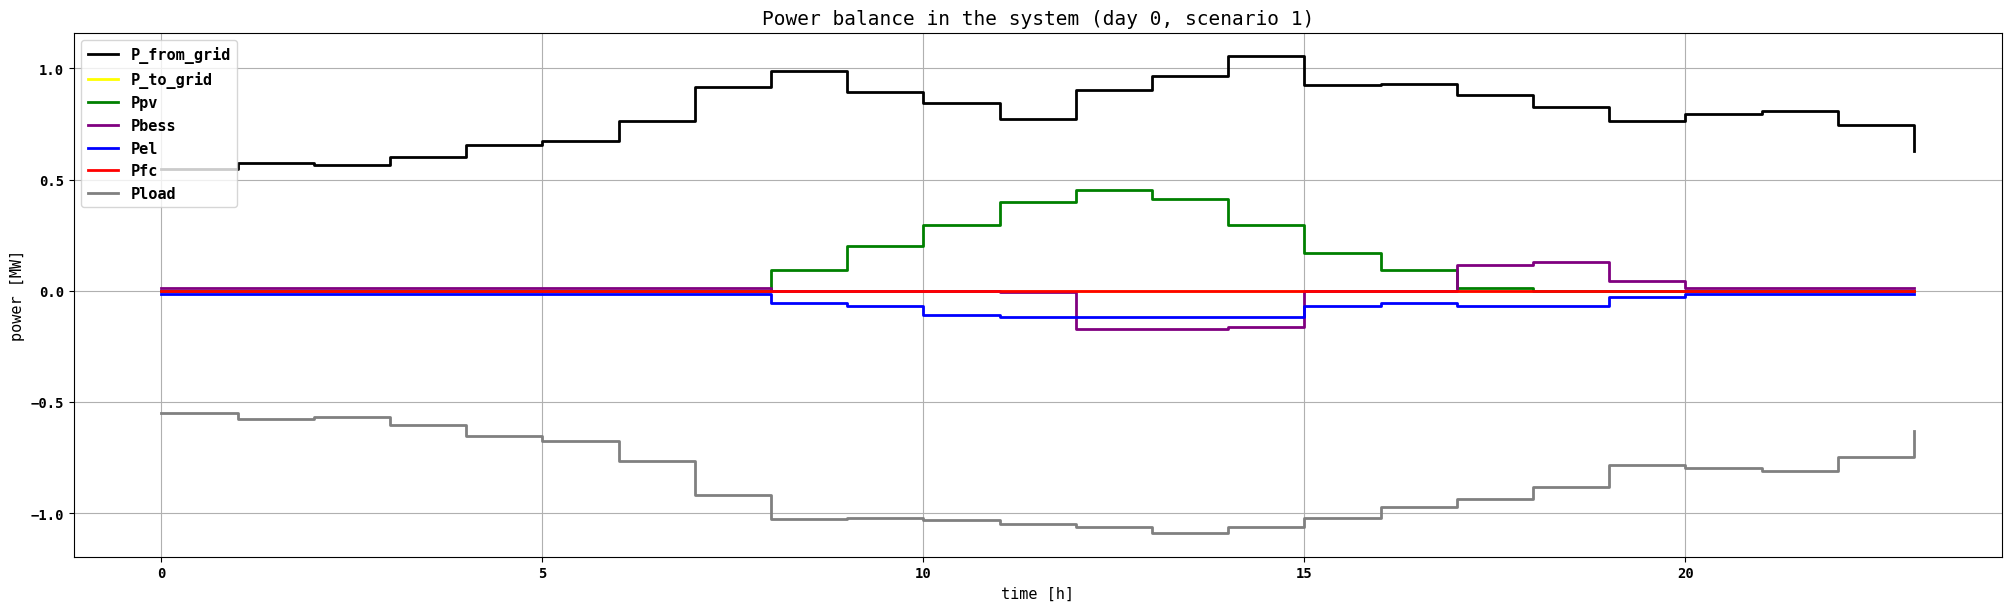

In [ ]:
#------------------------------------------------------------------------------------------------
# PLOTTING (4/4)
#------------------------------------------------------------------------------------------------

# POWER BALANCE PLOTS --------------------------------------------------------------------------------------
# TIME WINDOW
# Power balance plot
figPow, axsPow = plt.subplots(layout='constrained', figsize = (20, 7))
axsPow.step(time_plot_tdays[:-1], pgrid_p_vals[scenarios[1], :, :].reshape(-1), color = 'black', label = 'P_from_grid', where='post')
axsPow.step(time_plot_tdays[:-1], -pgrid_n_vals[scenarios[1], :, :].reshape(-1), color = 'yellow', label = 'P_to_grid', where='post')
axsPow.step(time_plot_tdays[:-1], Ppv_vals[scenarios[1], :, :].reshape(-1), color = 'green', label = 'Ppv', where='post')
axsPow.step(time_plot_tdays[:-1], pb_vals[scenarios[1], :, :].reshape(-1), color = 'purple', label = 'Pbess', where='post')
axsPow.step(time_plot_tdays[:-1], -pel_vals[scenarios[1], :, :].reshape(-1), color = 'blue', label = 'Pel', where='post')
axsPow.step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :, :].reshape(-1), color = 'red', label = 'Pfc', where='post')
axsPow.step(time_plot_tdays[:-1], -Pload_vals[scenarios[1], :, :].reshape(-1), color = 'grey', label = 'Pload', where='post')
axsPow.set_xticks([day * 24 for day in range(N_d + 1)])
axsPow.set_xlabel('time [h]')
axsPow.set_ylabel('power [MW]')
axsPow.set_title(f'Power balance in the system (scenario {scenarios[1]})')
# axsPow.set_xlim(week*24*7, (week+1)*24*7 + 1)
# axsPow.set_ylim(0, 1.1 * Pel_rtd['EL'])
axsPow.legend()

# CHOSEN DAY
# Power balance plot
figPow2, axsPow2 = plt.subplots(layout='constrained', figsize = (20, 6))
axsPow2.step(time_plot[:-1], pgrid_p_vals[scenarios[1], day_2plot, :], color = 'black', label = 'P_from_grid', where='post')
axsPow2.step(time_plot[:-1], -pgrid_n_vals[scenarios[1], day_2plot, :], color = 'yellow', label = 'P_to_grid', where='post')
axsPow2.step(time_plot[:-1], Ppv_vals[scenarios[1], day_2plot, :], color = 'green', label = 'Ppv', where='post')
axsPow2.step(time_plot[:-1], pb_vals[scenarios[1], day_2plot, :], color = 'purple', label = 'Pbess', where='post')
axsPow2.step(time_plot[:-1], -pel_vals[scenarios[1], day_2plot, :], color = 'blue', label = 'Pel', where='post')
axsPow2.step(time_plot[:-1], pfc_vals[scenarios[1], day_2plot, :], color = 'red', label = 'Pfc', where='post')
axsPow2.step(time_plot[:-1], -Pload_vals[scenarios[1], day_2plot, :], color = 'grey', label = 'Pload', where='post')
axsPow2.set_xlabel('time [h]')
axsPow2.set_ylabel('power [MW]')
axsPow2.set_title(f'Power balance in the system (day {day_2plot}, scenario {scenarios[1]})')
# axsPow2.set_xlim(0, 24)
# axsPow2.set_ylim(0, 1.1 * Pel_rtd['EL'])
axsPow2.legend()

In [ ]:
0.7 / (2.2*400*66/1000)

1 * 0.75 / 33.3e-3

22.52252252252252